# Gambari Forest Reserve fire-risk analysis — reproducibility notebook

Reproduces every numerical result, table, and figure in the main manuscript and the supplementary report, in the order they appear.

**Main manuscript** — Table 1 (descriptive statistics), Table 2 (AHP eigenvector weights), Table 3 (model performance); Figures 1–8 (reserve map, fire regime, climate–fire coupling, climate diagnostic, AHP map, data-driven surface, ROC curves, stakeholder perceptions).

**Supplementary** — Tables S1–S10, Figures S1–S7.

**LULC class 4** (cleared / recently burned land) is dropped from the analytical sample: class-4 pixels are excluded from both presences and pseudo-absences at every design-matrix step.

**Runtime:** about 5–7 minutes on a free-tier Colab CPU.

**Expected Drive layout** (point `ROOT` at the unzipped `Gambari` folder):
```
Gambari/
  AHP_Fire_Risk_Map/Fire_Risk.tif (+ .tfw)
  AHP Weight Overlay Layers/...tif  (NDVI, LST, Humidity, Slope, Aspect, Elevation, Precipitation; + .tfw)
  AHP Weight Overlay Layers/Gambari_Forest_Reserve.shp (+ .shx, .dbf, .prj)
  Distance Rasters/{D2Place, D2Road, D2Water}.tif (+ .tfw)
  Fire_Points Shapefiles/fire_archive_M-C61_705972.shp (+ .shx, .dbf)
  LULC Layer/LULC Layer/LULC_25.tif (+ .tfw)
  Climatic_data.xlsx
  Questionannire (Responses).xlsx
```

## Part A. Setup

### A1. Environment, output paths, and run log
Mounts Google Drive in Colab; otherwise set `GAMBARI_ROOT` / `GAMBARI_OUT`. All printed output is mirrored to `OUT_DIR/run_log.txt` for easy upload.

In [42]:
import os, sys

# Mount Google Drive when running in Colab; otherwise set ROOT/OUT_DIR yourself.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    ROOT = '/content/drive/MyDrive/Gambari'
except Exception:
    ROOT = os.environ.get('GAMBARI_ROOT', './Gambari')

OUT_DIR = os.environ.get('GAMBARI_OUT', f'{ROOT}/Gambari_new_update_outputs')
os.makedirs(f'{OUT_DIR}/figures', exist_ok=True)
os.makedirs(f'{OUT_DIR}/tables', exist_ok=True)

# Mirror printed output to run_log.txt alongside the saved tables and figures.
class _Tee:
    def __init__(self, stream, path):
        self.stream = stream
        self.file = open(path, 'w')
    def write(self, data):
        self.stream.write(data); self.file.write(data); self.file.flush()
    def flush(self):
        self.stream.flush(); self.file.flush()
    def __getattr__(self, name):
        return getattr(self.stream, name)

if not isinstance(sys.stdout, _Tee):
    sys.stdout = _Tee(sys.stdout, f'{OUT_DIR}/run_log.txt')

print('ROOT    =', ROOT)
print('OUT_DIR =', OUT_DIR)
print('Printed output is mirrored to', f'{OUT_DIR}/run_log.txt')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ROOT    = /content/drive/MyDrive/Gambari
OUT_DIR = /content/drive/MyDrive/Gambari/Gambari_new_update_outputs
Printed output is mirrored to /content/drive/MyDrive/Gambari/Gambari_new_update_outputs/run_log.txt


### A2. Package installation

In [43]:
import subprocess, sys
for pkg in ['tifffile', 'openpyxl']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
print('All packages available.')

All packages available.


### A3. Imports and global plot style

In [44]:
import os, math, struct, json, warnings, logging
import numpy as np
import pandas as pd
import tifffile
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch, FancyBboxPatch, Rectangle
from matplotlib.lines import Line2D
from scipy import stats
from scipy.spatial import cKDTree
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.cluster import KMeans
warnings.filterwarnings('ignore')
logging.getLogger('tifffile').setLevel(logging.ERROR)

# Global plot style
mpl.rcParams.update({
    'font.family':     'DejaVu Sans',
    'font.size':       12,
    'axes.titlesize':  13,
    'axes.labelsize':  12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi': 100,
})

SEED = 42
np.random.seed(SEED)

### A4. Shared utilities
UTM 31N projection, raster and shapefile/DBF readers, Mann–Kendall and Wilson helpers, quasi-Poisson GLM, and the logistic Wald-SE helper.

In [45]:
# UTM 31N forward projection (Snyder USGS Bulletin 1532, EPSG 32631)
def utm31n_from_wgs84(lon, lat):
    lon = np.atleast_1d(np.asarray(lon, dtype=float))
    lat = np.atleast_1d(np.asarray(lat, dtype=float))
    a = 6378137.0; f = 1.0 / 298.257223563
    b = a * (1 - f)
    e_sq = (a * a - b * b) / (a * a)
    e_prime_sq = (a * a - b * b) / (b * b)
    k0 = 0.9996
    lon0 = math.radians(3.0)
    false_e = 500000.0
    lat_r = np.radians(lat); lon_r = np.radians(lon)
    N = a / np.sqrt(1 - e_sq * np.sin(lat_r) ** 2)
    T = np.tan(lat_r) ** 2
    C = e_prime_sq * np.cos(lat_r) ** 2
    A = np.cos(lat_r) * (lon_r - lon0)
    M = a * ((1 - e_sq / 4 - 3 * e_sq ** 2 / 64 - 5 * e_sq ** 3 / 256) * lat_r
             - (3 * e_sq / 8 + 3 * e_sq ** 2 / 32 + 45 * e_sq ** 3 / 1024) * np.sin(2 * lat_r)
             + (15 * e_sq ** 2 / 256 + 45 * e_sq ** 3 / 1024) * np.sin(4 * lat_r)
             - (35 * e_sq ** 3 / 3072) * np.sin(6 * lat_r))
    x = false_e + k0 * N * (A + (1 - T + C) * A ** 3 / 6
                              + (5 - 18 * T + T * T + 72 * C - 58 * e_prime_sq) * A ** 5 / 120)
    y = k0 * (M + N * np.tan(lat_r) * (A * A / 2
             + (5 - T + 9 * C + 4 * C * C) * A ** 4 / 24
             + (61 - 58 * T + T * T + 600 * C - 330 * e_prime_sq) * A ** 6 / 720))
    return x, y

def read_4bit_tiled(path, nodata=0):
    """Read a 4-bit-packed tiled GeoTIFF (categorical AHP / LULC)."""
    with tifffile.TiffFile(path) as tif:
        p = tif.pages[0]
        H, W = p.shape; tw, tl = p.tilewidth, p.tilelength
        offsets = p.tags['TileOffsets'].value
        bcounts = p.tags['TileByteCounts'].value
        out = np.full((H, W), nodata, dtype=np.uint8)
        n_tx = (W + tw - 1) // tw
        fh = tif.filehandle
        for ty in range((H + tl - 1) // tl):
            for tx in range(n_tx):
                idx = ty * n_tx + tx
                fh.seek(offsets[idx]); buf = fh.read(bcounts[idx])
                arr = np.frombuffer(buf, dtype=np.uint8)
                hi = (arr >> 4) & 0x0F; lo = arr & 0x0F
                pix = np.empty(tw * tl, dtype=np.uint8)
                pix[0::2] = hi[:len(pix[0::2])]
                pix[1::2] = lo[:len(pix[1::2])]
                tile = pix.reshape(tl, tw)
                y0, x0 = ty * tl, tx * tw
                y1, x1 = min(y0 + tl, H), min(x0 + tw, W)
                out[y0:y1, x0:x1] = tile[:y1-y0, :x1-x0]
    return out

def read_tif_geo(path):
    """Read raster + .tfw. Masks GDAL float32 nodata sentinel."""
    with tifffile.TiffFile(path) as tif:
        p = tif.pages[0]
        if p.bitspersample == 4:
            arr = read_4bit_tiled(path, nodata=0)
        else:
            arr = tif.asarray()
    arr = arr.astype(np.float64)
    arr[arr < -1e30] = np.nan
    tfw = path.rsplit('.', 1)[0] + '.tfw'
    with open(tfw) as f:
        w = [float(L.strip()) for L in f]
    return arr, {'px': w[0], 'py': -w[3], 'ox': w[4], 'oy': w[5]}

def sample_raster(arr, world, xs, ys):
    cols = (xs - world['ox']) / world['px'] - 0.5
    rows = (world['oy'] - ys) / world['py'] - 0.5
    H, W = arr.shape
    out = np.full(len(xs), np.nan)
    ri = np.round(rows).astype(int); ci = np.round(cols).astype(int)
    ok = (ri >= 0) & (ri < H) & (ci >= 0) & (ci < W)
    out[ok] = arr[ri[ok], ci[ok]]
    return out

def points_in_polygon(xs, ys, ring):
    ring = np.asarray(ring)
    inside = np.zeros(len(xs), dtype=bool)
    n = len(ring)
    for i in range(n):
        x1, y1 = ring[i]; x2, y2 = ring[(i + 1) % n]
        c1 = (y1 > ys) != (y2 > ys)
        if y2 == y1:
            c2 = np.zeros_like(xs, dtype=bool)
        else:
            c2 = xs < (x2 - x1) * (ys - y1) / (y2 - y1) + x1
        inside ^= c1 & c2
    return inside

def polygon_area(ring):
    ring = np.asarray(ring)
    x, y = ring[:, 0], ring[:, 1]
    return 0.5 * abs(np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y))

def read_polygon_shp(path):
    with open(path, 'rb') as f:
        f.read(100); f.read(8); f.read(4); f.read(32)
        np_p = struct.unpack('<i', f.read(4))[0]
        np_n = struct.unpack('<i', f.read(4))[0]
        f.read(4 * np_p)
        pts = struct.unpack(f'<{2 * np_n}d', f.read(16 * np_n))
    return np.array([(pts[2*i], pts[2*i+1]) for i in range(np_n)])

def read_point_shp(path):
    with open(path, 'rb') as f:
        header = f.read(100)
        file_len = struct.unpack('>i', header[24:28])[0] * 2
        pts = []
        while f.tell() < file_len:
            f.read(4); cl = struct.unpack('>i', f.read(4))[0] * 2
            sh = struct.unpack('<i', f.read(4))[0]
            if sh == 1:
                x, y = struct.unpack('<2d', f.read(16))
                pts.append((x, y))
            else:
                f.read(cl - 4)
    return pts

def read_dbf(path):
    with open(path, 'rb') as f:
        header = f.read(32)
        nr = struct.unpack('<L', header[4:8])[0]
        hs = struct.unpack('<H', header[8:10])[0]
        rs = struct.unpack('<H', header[10:12])[0]
        fields = []
        while True:
            ch = f.read(32)
            if ch[0:1] == b'\r': break
            name = ch[0:11].split(b'\0', 1)[0].decode('latin-1').strip()
            ft = ch[11:12].decode('latin-1'); fl = ch[16]
            fields.append((name, ft, fl))
        f.seek(hs)
        recs = []
        for _ in range(nr):
            rec = f.read(rs)
            if not rec or rec[0:1] == b'*': continue
            row = {}; offset = 1
            for name, ft, fl in fields:
                v = rec[offset:offset+fl].decode('latin-1').strip()
                offset += fl
                if ft == 'N' and v:
                    try: v = float(v)
                    except: pass
                row[name] = v
            recs.append(row)
    return recs

# Mann-Kendall trend test (no ties correction)
def mann_kendall(x):
    x = np.asarray(x); n = len(x); S = 0
    for i in range(n - 1):
        for j in range(i + 1, n):
            S += np.sign(x[j] - x[i])
    var_S = n * (n - 1) * (2 * n + 5) / 18
    if S > 0:    Z = (S - 1) / np.sqrt(var_S)
    elif S < 0:  Z = (S + 1) / np.sqrt(var_S)
    else:        Z = 0
    return S, Z, 2 * (1 - stats.norm.cdf(abs(Z)))

# Wilson CI for binomial proportions
def wilson_ci(p, n, z=1.96):
    if n == 0: return (0, 0)
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return (centre - half, centre + half)

# Quasi-Poisson regression via IRLS with dispersion-corrected SEs
def quasi_poisson_glm(X, y, max_iter=50):
    X = np.column_stack([np.ones(len(y)), X])
    beta = np.zeros(X.shape[1])
    for _ in range(max_iter):
        eta = X @ beta
        mu  = np.exp(eta)
        z   = eta + (y - mu) / mu
        Wd  = mu
        WX  = X * Wd[:, None]
        try:
            beta_new = np.linalg.solve(X.T @ WX, X.T @ (Wd * z))
        except np.linalg.LinAlgError:
            break
        if np.max(np.abs(beta_new - beta)) < 1e-8:
            beta = beta_new; break
        beta = beta_new
    mu = np.exp(X @ beta)
    phi = float(((y - mu) ** 2 / mu).sum() / max(1, len(y) - X.shape[1]))
    cov = phi * np.linalg.inv(X.T @ (X * mu[:, None]))
    return beta, np.sqrt(np.diag(cov)), phi

# Wald standard errors from the observed Fisher information (logistic GLM)
def logistic_se(X, y, coef, intercept):
    Xb = np.column_stack([np.ones(len(y)), X])
    beta = np.concatenate([[intercept], coef])
    p = 1 / (1 + np.exp(-(Xb @ beta)))
    H = Xb.T @ (Xb * (p * (1 - p))[:, None])
    try:
        return np.sqrt(np.diag(np.linalg.inv(H)))
    except np.linalg.LinAlgError:
        return np.full(Xb.shape[1], np.nan)

print('All helpers defined.')

All helpers defined.


### A5. Cartographic helpers
Scale bar, grid-north arrow, and meridian-convergence angle.

In [46]:
# Cartographic helpers: scale bar and true-north arrow
#
# UTM 31N grid north differs from true geographic north by the meridian
# convergence angle (gamma). At Gambari (lon = 3.85 E, lat = 7.15 N) the
# central meridian of zone 31N is at 3 E, so gamma is small but non-zero.
# gamma is computed below from the standard Snyder formula.
#
# Conventionally, north arrows in projected maps point to grid north.
# We label the arrow 'N' and indicate the grid-vs-true offset in the figure caption.

def meridian_convergence(lon_deg, lat_deg, lon0_deg=3.0):
    """Approximate meridian convergence angle gamma (degrees), positive east."""
    dl = math.radians(lon_deg - lon0_deg)
    phi = math.radians(lat_deg)
    return math.degrees(dl * math.sin(phi))

def add_scale_bar(ax, x, y, length_m=5000, height_m=400, label=None,
                    fontsize=11, label_offset_m=600):
    """Place a black scale bar on a UTM-coordinate axis.
    (x, y): bottom-left anchor in axis units (metres)."""
    ax.add_patch(Rectangle((x, y), length_m, height_m,
                              facecolor='black', edgecolor='black'))
    if label is None:
        label = f'{int(length_m/1000)} km' if length_m >= 1000 else f'{int(length_m)} m'
    ax.text(x + length_m / 2, y + height_m + label_offset_m,
             label, ha='center', va='bottom',
             fontsize=fontsize, fontweight='bold')

def add_north_arrow(ax, x, y, length_m=2000, fontsize=14):
    """Place a true-north arrow on a UTM-coordinate axis at (x, y) (arrow tip).
    Arrow points up (grid north); for Gambari the offset to true north is
    less than 0.5 deg and is annotated in the figure caption instead."""
    ax.annotate('', xy=(x, y), xytext=(x, y - length_m),
                  arrowprops=dict(arrowstyle='->,head_width=0.4,head_length=0.6',
                                    color='black', lw=2.2))
    ax.text(x, y + length_m * 0.18, 'N', ha='center', va='bottom',
             fontsize=fontsize, fontweight='bold')

gamma = meridian_convergence(3.85, 7.15)
print(f'Grid-to-true north offset at Gambari (gamma) = {gamma:+.3f} deg '
      f'(used in figure captions, not in the arrow direction)')

Grid-to-true north offset at Gambari (gamma) = +0.106 deg (used in figure captions, not in the arrow direction)


## Part B. Data loading and design matrices

### B1. Reserve polygon, fires, AHP raster, climate, questionnaire

In [47]:
# Reserve polygon (WGS84 to UTM 31N)
reserve_path = f'{ROOT}/AHP Weight Overlay Layers/Gambari_Forest_Reserve.shp'
ring_lonlat = read_polygon_shp(reserve_path)
ring_x, ring_y = utm31n_from_wgs84(ring_lonlat[:, 0], ring_lonlat[:, 1])
reserve_outer = list(zip(ring_x, ring_y))
reserve_area_m2 = polygon_area(reserve_outer)
reserve_area_ha = reserve_area_m2 / 1e4
print(f'Reserve polygon: {len(ring_x)} vertices, area = {reserve_area_ha:,.0f} ha')

# Fires (shapefile + DBF)
fire_shp = f'{ROOT}/Fire_Points Shapefiles/fire_archive_M-C61_705972.shp'
fire_dbf = f'{ROOT}/Fire_Points Shapefiles/fire_archive_M-C61_705972.dbf'
fire_xy_wgs = read_point_shp(fire_shp)
fire_recs   = read_dbf(fire_dbf)
fire_df = pd.DataFrame(fire_recs)
fire_df['lon'] = [p[0] for p in fire_xy_wgs]
fire_df['lat'] = [p[1] for p in fire_xy_wgs]
fx, fy = utm31n_from_wgs84(fire_df['lon'].values, fire_df['lat'].values)
fire_df['x_utm'] = fx; fire_df['y_utm'] = fy
fire_df['year']  = fire_df['ACQ_DATE'].astype(str).str[:4].astype(int)
fire_df['month'] = fire_df['ACQ_DATE'].astype(str).str[4:6].astype(int)
print(f'Fires: {len(fire_df)} '
      f'(Aqua = {(fire_df.SATELLITE == "Aqua").sum()}, '
      f'Terra = {(fire_df.SATELLITE == "Terra").sum()})')

# AHP literature-weight raster
ahp, ahp_w = read_tif_geo(f'{ROOT}/AHP_Fire_Risk_Map/Fire_Risk.tif')
print(f'AHP raster: {ahp.shape}, pixel = {ahp_w["px"]:.1f} m')

# Climate
clim = pd.read_excel(f'{ROOT}/Climatic_data.xlsx').sort_values('Year').reset_index(drop=True)
print(f'Climate: {clim.Year.min()} to {clim.Year.max()}, {len(clim)} rows')

# Questionnaire (accepts either spelling of the filename)
q_path = f'{ROOT}/Questionannire (Responses).xlsx'
if not os.path.exists(q_path):
    q_path = f'{ROOT}/Questionnaire (Responses).xlsx'
q = pd.read_excel(q_path)
print(f'Questionnaire: {len(q)} respondents, {len(q.columns)} columns')

Reserve polygon: 75 vertices, area = 17,164 ha
Fires: 568 (Aqua = 521, Terra = 47)
AHP raster: (250, 349), pixel = 64.0 m
Climate: 2000 to 2025, 26 rows
Questionnaire: 55 respondents, 47 columns


### B2. Predictor rasters, LULC, and climate rasters

In [48]:
# Predictor rasters
pred_paths = {
    'NDVI_2025': f'{ROOT}/AHP Weight Overlay Layers/NDVI_2025.tif',
    'NDVI_2015': f'{ROOT}/AHP Weight Overlay Layers/NDVI_2015.tif',
    'NDVI_2005': f'{ROOT}/AHP Weight Overlay Layers/NDVI_2005.tif',
    'LST_2025':  f'{ROOT}/AHP Weight Overlay Layers/LST_2025.tif',
    'LST_2015':  f'{ROOT}/AHP Weight Overlay Layers/LST_2015.tif',
    'LST_2005':  f'{ROOT}/AHP Weight Overlay Layers/LST_2005.tif',
    'Slope':     f'{ROOT}/AHP Weight Overlay Layers/Slope.tif',
    'Aspect':    f'{ROOT}/AHP Weight Overlay Layers/Aspect.tif',
    'Elevation': f'{ROOT}/AHP Weight Overlay Layers/Elevation.tif',
    'D2Place':   f'{ROOT}/Distance Rasters/D2Place.tif',
    'D2Road':    f'{ROOT}/Distance Rasters/D2Road.tif',
    'D2Water':   f'{ROOT}/Distance Rasters/D2Water.tif',
}
layers = {k: read_tif_geo(p) for k, p in pred_paths.items()}
lulc, lulc_w = read_tif_geo(f'{ROOT}/LULC Layer/LULC Layer/LULC_25.tif')

# Climate rasters (used for Figure 5 and the ten-criterion empirical AHP)
hum,  hum_w  = read_tif_geo(f'{ROOT}/AHP Weight Overlay Layers/Humidity_2015.tif')
prec, prec_w = read_tif_geo(f'{ROOT}/AHP Weight Overlay Layers/Precipitation_2015.tif')
print('All raster layers loaded.')

All raster layers loaded.


### B3. Baseline pseudo-absences and design matrix
**LULC class 4 dropped** from the absence pool and the design matrix.

In [49]:
# 5:1 baseline pseudo-absences within reserve polygon
rng = np.random.default_rng(SEED)
target_abs = 5 * len(fire_df)
xmin, xmax = ring_x.min(), ring_x.max()
ymin, ymax = ring_y.min(), ring_y.max()
out_pts = []; attempts = 0
while len(out_pts) < target_abs and attempts < 200:
    nx = rng.uniform(xmin, xmax, target_abs * 5)
    ny = rng.uniform(ymin, ymax, target_abs * 5)
    inside = points_in_polygon(nx, ny, np.array(reserve_outer))
    cx, cy = nx[inside], ny[inside]
    lu = sample_raster(lulc, lulc_w, cx, cy)
    good = ~np.isnan(lu) & (lu != 15) & (lu != 4)
    out_pts.extend(zip(cx[good], cy[good]))
    attempts += 1
abs_pts = np.array(out_pts[:target_abs])

# Build the design matrix
xy_all = np.vstack([fire_df[['x_utm', 'y_utm']].values, abs_pts])
y_all  = np.concatenate([np.ones(len(fire_df)), np.zeros(len(abs_pts))])
d = {}
for k, (arr, w) in layers.items():
    d[k] = sample_raster(arr, w, xy_all[:, 0], xy_all[:, 1])
d['LULC'] = sample_raster(lulc, lulc_w, xy_all[:, 0], xy_all[:, 1])
d['Humidity_2015']      = sample_raster(hum,  hum_w,  xy_all[:, 0], xy_all[:, 1])
d['Precipitation_2015'] = sample_raster(prec, prec_w, xy_all[:, 0], xy_all[:, 1])
d['fire'] = y_all
d['x_utm'] = xy_all[:, 0]; d['y_utm'] = xy_all[:, 1]
df_d = pd.DataFrame(d)
df_d = df_d.dropna(subset=list(layers.keys()))
df_d = df_d[(df_d['LULC'].notna()) & (df_d['LULC'] != 15) & (df_d['LULC'] != 4)]
df_d = df_d[(df_d['D2Place'] > 0) & (df_d['D2Road'] > 0) & (df_d['D2Water'] > 0)]
n_total = len(df_d)
n_fires_clean = int(df_d['fire'].sum())
print(f'Clean design matrix: n = {n_total} ({n_fires_clean} fires, '
      f'{n_total - n_fires_clean} absences)')

# Fit the baseline logistic regression
cols_cont = ['NDVI_2025','NDVI_2015','NDVI_2005','LST_2025','LST_2015','LST_2005',
             'Slope','Aspect','Elevation','D2Place','D2Road','D2Water']
X = df_d[cols_cont].values.copy()
for j, c in enumerate(cols_cont):
    if c.startswith('D2'):
        X[:, j] = np.log(np.clip(X[:, j], 1, None))
mu_X, sd_X = X.mean(axis=0), X.std(axis=0)
X_z = (X - mu_X) / sd_X
y_d = df_d['fire'].values.astype(int)

lr_main = LogisticRegression(max_iter=5000, C=1e6).fit(X_z, y_d)
prob_main = lr_main.predict_proba(X_z)[:, 1]
auc_in_sample = roc_auc_score(y_d, prob_main)
print(f'Baseline (0 m exclusion) logistic in-sample AUC = {auc_in_sample:.3f}')
print('Baseline (0 m) configuration feeds the ROC overlay in Figure 8;')
print('the headline result uses the 500 m exclusion (Table 3 and Figure 7).')

# Moran's I on Pearson residuals of the baseline logistic (k=8 KNN, row-standardised)
from sklearn.neighbors import NearestNeighbors
_resid = (y_d - prob_main) / np.sqrt(np.clip(prob_main * (1 - prob_main), 1e-9, None))
_coords = df_d[['x_utm', 'y_utm']].values
_, _nbr = NearestNeighbors(n_neighbors=9).fit(_coords).kneighbors(_coords)
_nbr = _nbr[:, 1:]
_zc = _resid - _resid.mean()
moran_I = float(np.sum(_zc * _zc[_nbr].mean(axis=1)) / np.sum(_zc ** 2))
_rng_m = np.random.default_rng(SEED)
_perm = np.array([
    (lambda zp: np.sum(zp * zp[_nbr].mean(axis=1)) / np.sum(zp ** 2))(_rng_m.permutation(_zc))
    for _ in range(199)])
moran_p = float((np.sum(np.abs(_perm) >= abs(moran_I)) + 1) / 200)
print(f"Moran's I on baseline logistic residuals (k=8 KNN): "
      f"I = {moran_I:+.4f}, permutation p = {moran_p:.3f} "
      f"(expected ~ {-1/(len(_zc)-1):+.4f} under no autocorrelation)")

Clean design matrix: n = 3118 (531 fires, 2587 absences)
Baseline (0 m exclusion) logistic in-sample AUC = 0.608
Baseline (0 m) configuration feeds the ROC overlay in Figure 8;
the headline result uses the 500 m exclusion (Table 3 and Figure 7).
Moran's I on baseline logistic residuals (k=8 KNN): I = -0.0067, permutation p = 0.460 (expected ~ -0.0003 under no autocorrelation)


### B4. 500 m exclusion design matrix (headline configuration)
**LULC class 4 dropped.**

In [50]:
# Re-sample absences with 500 m exclusion from any fire point
tree_f = cKDTree(fire_df[['x_utm', 'y_utm']].values)
target = 5 * len(fire_df)
out_500 = []; rng_5 = np.random.default_rng(SEED)
for _ in range(200):
    if len(out_500) >= target: break
    nx = rng_5.uniform(xmin, xmax, target * 5)
    ny = rng_5.uniform(ymin, ymax, target * 5)
    inside = points_in_polygon(nx, ny, np.array(reserve_outer))
    cx, cy = nx[inside], ny[inside]
    lu = sample_raster(lulc, lulc_w, cx, cy)
    good = ~np.isnan(lu) & (lu != 15) & (lu != 4)
    cx, cy = cx[good], cy[good]
    if len(cx) == 0: continue
    dnn, _ = tree_f.query(np.column_stack([cx, cy]), k=1)
    far = dnn >= 500
    out_500.extend(zip(cx[far], cy[far]))
abs_500 = np.array(out_500[:target])

xy_500 = np.vstack([fire_df[['x_utm', 'y_utm']].values, abs_500])
y_500 = np.concatenate([np.ones(len(fire_df)), np.zeros(len(abs_500))])
d500 = {k: sample_raster(arr, w, xy_500[:, 0], xy_500[:, 1]) for k, (arr, w) in layers.items()}
d500['LULC'] = sample_raster(lulc, lulc_w, xy_500[:, 0], xy_500[:, 1])
d500['fire'] = y_500
df500 = pd.DataFrame(d500).dropna(subset=list(layers.keys()))
df500 = df500[(df500['LULC'].notna()) & (df500['LULC'] != 15) & (df500['LULC'] != 4)]
df500 = df500[(df500['D2Place'] > 0) & (df500['D2Road'] > 0) & (df500['D2Water'] > 0)]
X500 = df500[cols_cont].values.copy()
for j, c in enumerate(cols_cont):
    if c.startswith('D2'):
        X500[:, j] = np.log(np.clip(X500[:, j], 1, None))
X500z = (X500 - X500.mean(axis=0)) / X500.std(axis=0)
y500c = df500['fire'].values.astype(int)
n500_abs = int((y500c == 0).sum()); n500_fire = int((y500c == 1).sum())
print(f'500 m exclusion sample: n = {len(y500c)} ({n500_fire} fires, {n500_abs} absences); '
      f'candidate absences passing the 500 m filter before truncation = {len(out_500)}')

500 m exclusion sample: n = 2956 (531 fires, 2425 absences); candidate absences passing the 500 m filter before truncation = 3518


### B5. Climate-fire temporal models (quasi-Poisson fit)
Fits the three quasi-Poisson specifications used by Figure 3 and Table S9 (computed here so both can reuse the results).

In [51]:
y_c = clim['Year'].values
precip_arr = clim['Precipitation'].values
temp_arr = clim['Surface Temperature'].values
hum_arr = clim['Relative Humidity'].values
yc_counts = fire_df.groupby('year').size().reindex(y_c, fill_value=0).values

# z-score climate predictors
def zscore(a):
    return (a - np.mean(a)) / np.std(a)

pz = zscore(precip_arr); tz = zscore(temp_arr); hz = zscore(hum_arr)
pz_lag1 = np.concatenate([[np.nan], pz[:-1]])

# Model 1: precipitation alone
b1, s1, phi1 = quasi_poisson_glm(pz.reshape(-1, 1), yc_counts)
# Model 2: precip + humidity + temperature
b2, s2, phi2 = quasi_poisson_glm(np.column_stack([pz, hz, tz]), yc_counts)
# Model 3: precip + lag1 precip + temperature (drop first year)
valid_lag = ~np.isnan(pz_lag1)
X3 = np.column_stack([pz[valid_lag], pz_lag1[valid_lag], tz[valid_lag]])
y3 = yc_counts[valid_lag]
b3, s3, phi3 = quasi_poisson_glm(X3, y3)

## Part C. Main manuscript tables

### Table 1. Descriptive statistics of MODIS active-fire detections
Totals, satellite split, seasonality, FRP, confidence, and the annual-count trend (OLS + Mann–Kendall).

In [52]:
counts = fire_df.groupby('year').size().reindex(range(2001, 2026), fill_value=0)
yr_arr, cs_arr = counts.index.values, counts.values
slope, intercept, r_lin, p_lin, _ = stats.linregress(yr_arr, cs_arr)
S_mk, Z_mk, p_mk = mann_kendall(cs_arr)

frp = fire_df['FRP'].values
conf = fire_df['CONFIDENCE'].values
pct_dry = 100 * fire_df['month'].isin([11, 12, 1, 2, 3]).mean()
pct_jfm = 100 * fire_df['month'].isin([1, 2, 3]).mean()
pct_cat1 = 100 * (frp < 100).mean()
pct_aqua = 100 * (fire_df['SATELLITE'] == 'Aqua').mean()

table1_rows = [
    ['Total detections',                              f'{len(fire_df)}'],
    ['Aqua / Terra',                                  f'{(fire_df.SATELLITE == "Aqua").sum()} ({pct_aqua:.1f}%) / {(fire_df.SATELLITE == "Terra").sum()} ({100-pct_aqua:.1f}%)'],
    ['Daytime (D) / Nighttime (N)',                   f'{(fire_df.DAYNIGHT == "D").sum()} / {(fire_df.DAYNIGHT == "N").sum()}'],
    ['Dry-season detections (Nov-Mar)',                f'{int(fire_df.month.isin([11,12,1,2,3]).sum())} ({pct_dry:.1f}%)'],
    ['Jan-Mar concentration',                         f'{int(fire_df.month.isin([1,2,3]).sum())} ({pct_jfm:.1f}%)'],
    ['Mean detection confidence',                     f'{conf.mean():.1f}'],
    ['Mean FRP (MW)',                                 f'{frp.mean():.2f}'],
    ['Median FRP (MW)',                               f'{np.median(frp):.2f}'],
    ['Maximum FRP (MW)',                              f'{frp.max():.1f}'],
    ['Category 1 fires (FRP < 100 MW)',               f'{int((frp < 100).sum())} ({pct_cat1:.2f}%)'],
    ['Annual trend slope (fires/yr)',                 f'+{slope:.2f}'],
    ['Linear R squared',                              f'{r_lin**2:.3f}'],
    ['Linear regression p-value',                     f'{p_lin:.4f}'],
    ['Mann-Kendall S statistic',                      f'{int(S_mk)}'],
    ['Mann-Kendall Z',                                f'{Z_mk:.3f}'],
    ['Mann-Kendall p-value',                          f'{p_mk:.4f}'],
]
table1 = pd.DataFrame(table1_rows, columns=['Statistic', 'Value'])
print('Table 1. Descriptive statistics of MODIS active-fire detections.\n')
print(table1.to_string(index=False))
table1.to_csv(f'{OUT_DIR}/tables/table1_descriptives.csv', index=False)

Table 1. Descriptive statistics of MODIS active-fire detections.

                      Statistic                   Value
               Total detections                     568
                   Aqua / Terra 521 (91.7%) / 47 (8.3%)
    Daytime (D) / Nighttime (N)                 568 / 0
Dry-season detections (Nov-Mar)             520 (91.5%)
          Jan-Mar concentration             485 (85.4%)
      Mean detection confidence                    63.4
                  Mean FRP (MW)                   20.02
                Median FRP (MW)                   13.20
               Maximum FRP (MW)                   186.2
Category 1 fires (FRP < 100 MW)            562 (98.94%)
  Annual trend slope (fires/yr)                   +0.91
               Linear R squared                   0.367
      Linear regression p-value                  0.0013
       Mann-Kendall S statistic                     131
                 Mann-Kendall Z                   3.036
           Mann-Kendall p-value       

### Table 2. AHP criterion eigenvector weights (CR = 9.91%)
The ten literature-derived weights; the three climate criteria carry 55.6% of the total.

In [53]:
table2_ahp = pd.DataFrame([
    [1, 'Humidity',                 '30.86%'],
    [2, 'Surface temperature (LST)','18.74%'],
    [3, 'Vegetation cover (NDVI)',  '11.83%'],
    [4, 'Distance to roads',        ' 8.99%'],
    [5, 'Slope',                    ' 7.33%'],
    [6, 'Precipitation',            ' 6.04%'],
    [7, 'Distance to settlements',  ' 5.50%'],
    [8, 'Aspect',                   ' 4.34%'],
    [9, 'Elevation',                ' 3.42%'],
    [10, 'Distance to water bodies',' 2.95%'],
], columns=['Rank', 'Criterion', 'Eigenvector weight'])
print('Table 2. AHP criterion eigenvector weights (CR = 9.91%).\n')
print(table2_ahp.to_string(index=False))
table2_ahp.to_csv(f'{OUT_DIR}/tables/table2_ahp_weights.csv', index=False)
print(f'\nClimate criteria sum: {30.86 + 18.74 + 6.04:.2f}%')

Table 2. AHP criterion eigenvector weights (CR = 9.91%).

 Rank                 Criterion Eigenvector weight
    1                  Humidity             30.86%
    2 Surface temperature (LST)             18.74%
    3   Vegetation cover (NDVI)             11.83%
    4         Distance to roads              8.99%
    5                     Slope              7.33%
    6             Precipitation              6.04%
    7   Distance to settlements              5.50%
    8                    Aspect              4.34%
    9                 Elevation              3.42%
   10  Distance to water bodies              2.95%

Climate criteria sum: 55.64%


### Table 3. Model performance (500 m exclusion, 5:1 absence ratio)
In-sample, random 5-fold × 3-seed CV, and spatial-block CV AUC for AHP plus four data-driven models.

In [54]:
def auc_in_and_cv(factory, X, y):
    m_in = factory(); m_in.fit(X, y)
    sc = m_in.predict_proba(X)[:, 1] if hasattr(m_in, 'predict_proba') else m_in.decision_function(X)
    in_auc = roc_auc_score(y, sc)
    aucs = []
    for s in [42, 43, 44]:
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=s)
        for tr, te in skf.split(X, y):
            m = factory(); m.fit(X[tr], y[tr])
            scte = m.predict_proba(X[te])[:, 1] if hasattr(m, 'predict_proba') else m.decision_function(X[te])
            aucs.append(roc_auc_score(y[te], scte))
    return in_auc, float(np.mean(aucs)), float(np.std(aucs))

# 4x4 spatial-block CV (16 blocks, leave-one-block-out)
def auc_spatial_cv(factory, X, y, xy, n_blocks=4):
    """Spatial-block CV using an equal-width 4x4 grid (16 blocks).
    Requires each test fold to contain at least 10 fires and 10 absences,
    which keeps the per-fold AUC well-defined and reduces fold-level variance."""
    x_edges = np.linspace(xy[:, 0].min(), xy[:, 0].max(), n_blocks + 1)
    y_edges = np.linspace(xy[:, 1].min(), xy[:, 1].max(), n_blocks + 1)
    bx = np.clip(np.searchsorted(x_edges[1:-1], xy[:, 0]), 0, n_blocks - 1)
    by_ = np.clip(np.searchsorted(y_edges[1:-1], xy[:, 1]), 0, n_blocks - 1)
    block_id = bx * n_blocks + by_
    aucs = []
    for b in np.unique(block_id):
        te = block_id == b
        tr = ~te
        if y[te].sum() < 10 or (1 - y[te]).sum() < 10: continue
        if y[tr].sum() == 0 or y[tr].sum() == len(y[tr]): continue
        try:
            m = factory(); m.fit(X[tr], y[tr])
            scte = m.predict_proba(X[te])[:, 1] if hasattr(m, 'predict_proba') else m.decision_function(X[te])
            aucs.append(roc_auc_score(y[te], scte))
        except Exception:
            continue
    if len(aucs) == 0: return (float('nan'), float('nan'))
    return float(np.mean(aucs)), float(np.std(aucs))

factories = {
    'AHP (literature)':            None,
    'Logistic regression':         lambda: LogisticRegression(max_iter=5000, C=1e6),
    'Random Forest':               lambda: RandomForestClassifier(n_estimators=100, max_depth=6, random_state=SEED, n_jobs=-1),
    'Gradient Boosting':           lambda: GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=SEED),
    'MaxEnt-L1 (Maxnet-style)':    lambda: LogisticRegression(max_iter=5000, C=0.5, solver='liblinear', penalty='l1'),
}

# AHP AUC via in-sample (no CV; static map)
ahp_at_fire_500 = sample_raster(ahp, ahp_w, df500['x_utm'].values if 'x_utm' in df500 else fire_df['x_utm'].values, df500['y_utm'].values if 'y_utm' in df500 else fire_df['y_utm'].values)
ahp_at_f0 = sample_raster(ahp, ahp_w, fire_df['x_utm'].values, fire_df['y_utm'].values)
ahp_at_a0 = sample_raster(ahp, ahp_w, abs_pts[:, 0], abs_pts[:, 1])
y_ahp_eval = np.concatenate([np.ones(len(fire_df)), np.zeros(len(abs_pts))])
sc_ahp_eval = np.concatenate([ahp_at_f0, ahp_at_a0])
m_ahp = (sc_ahp_eval >= 1) & (sc_ahp_eval <= 3)
auc_ahp_static = roc_auc_score(y_ahp_eval[m_ahp], sc_ahp_eval[m_ahp])

xy500 = df500[[c for c in df500.columns if c in ['x_utm', 'y_utm']]].values if all(c in df500.columns for c in ['x_utm','y_utm']) else xy_500[df500.index]

rows3 = [['AHP (literature)', f'{auc_ahp_static:.3f}', '-', '-']]
for name, factory in factories.items():
    if factory is None: continue
    in_a, cv_m, cv_s = auc_in_and_cv(factory, X500z, y500c)
    sb_m, sb_s = auc_spatial_cv(factory, X500z, y500c, xy_500[df500.index.values])
    rows3.append([name, f'{in_a:.3f}', f'{cv_m:.3f} +/- {cv_s:.3f}', f'{sb_m:.3f} +/- {sb_s:.3f}'])

table3_models = pd.DataFrame(rows3, columns=['Model', 'In-sample AUC', 'Random 5-fold CV AUC', '4x4 spatial-block CV AUC'])
print('Table 3. Model performance (500 m exclusion radius, 5:1 absence ratio).\n')
print(table3_models.to_string(index=False))
table3_models.to_csv(f'{OUT_DIR}/tables/table3_model_auc.csv', index=False)

Table 3. Model performance (500 m exclusion radius, 5:1 absence ratio).

                   Model In-sample AUC Random 5-fold CV AUC 4x4 spatial-block CV AUC
        AHP (literature)         0.463                    -                        -
     Logistic regression         0.801      0.795 +/- 0.017          0.645 +/- 0.120
           Random Forest         0.930      0.859 +/- 0.021          0.633 +/- 0.183
       Gradient Boosting         0.948      0.865 +/- 0.019          0.620 +/- 0.182
MaxEnt-L1 (Maxnet-style)         0.800      0.795 +/- 0.017          0.646 +/- 0.120


## Part D. Main manuscript figures

### Figure 1. Experimental and technical design flowchart
Schematic of the full pipeline: data sources, pre-processing, the three modelling tracks, validation, and outputs. No data dependencies; renders to PNG/PDF/SVG.

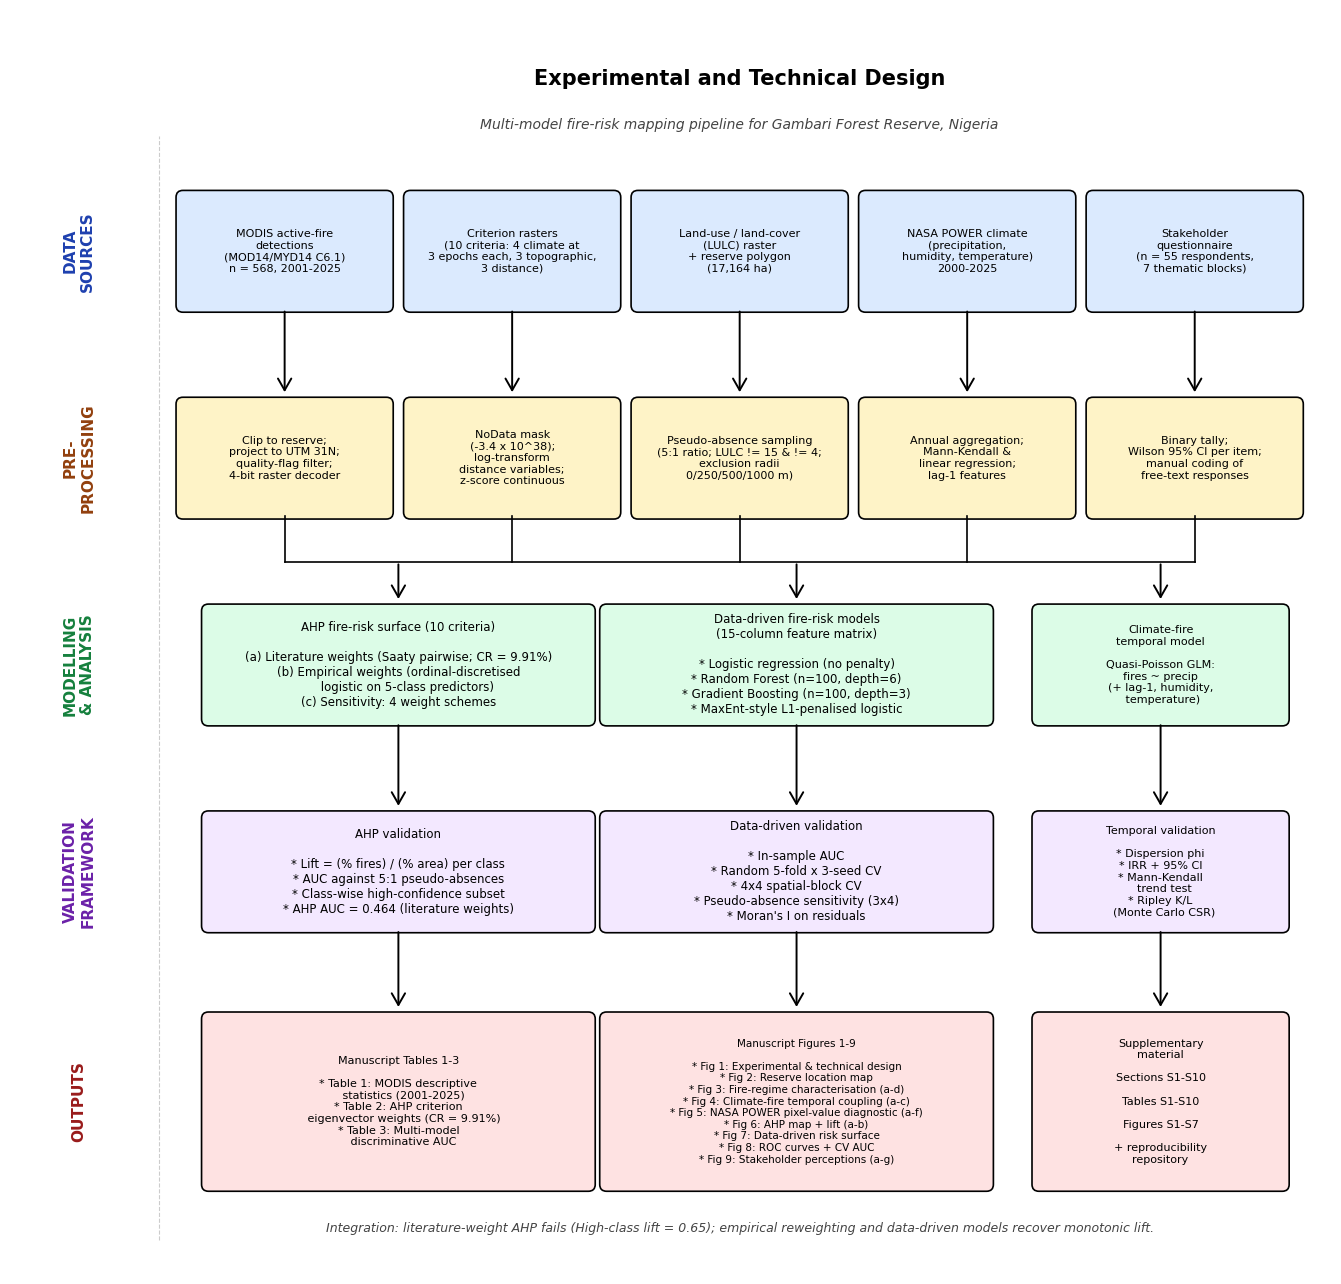

In [55]:
# Figure 1. Experimental and technical design flowchart.
# Self-contained schematic of the analysis pipeline (no data dependencies);
# saved as fig1_experimental_design.{png,pdf,svg} under OUT_DIR/figures.
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

mpl.rcParams['pdf.fonttype'] = 42      # embed TrueType in vector output
mpl.rcParams['svg.fonttype'] = 'none'  # keep SVG text as text

LABEL_X_CENTRE, CONTENT_X_START, CONTENT_X_END = 6, 14, 113
CONTENT_W = CONTENT_X_END - CONTENT_X_START
ROW_BAND_CENTRES = [89, 71, 53, 35, 15]
BOX_HEIGHT, BOX_HEIGHT_OUT = 10, 15

C_DATA,   C_DATA_E   = '#dbeafe', '#1e40af'
C_PROC,   C_PROC_E   = '#fef3c7', '#92400e'
C_MODEL,  C_MODEL_E  = '#dcfce7', '#15803d'
C_VALID,  C_VALID_E  = '#f3e8ff', '#6b21a8'
C_OUTPUT, C_OUTPUT_E = '#fee2e2', '#991b1b'

def row_label(y_centre, text, color, fontsize=11):
    ax.text(LABEL_X_CENTRE, y_centre, text, ha='center', va='center',
            fontsize=fontsize, fontweight='bold', color=color, rotation=90)

def add_box(x_centre, y_centre, w, text, fill, fontsize=8.5, h=BOX_HEIGHT):
    ax.add_patch(FancyBboxPatch((x_centre - w/2, y_centre - h/2), w, h,
        boxstyle='round,pad=0.3,rounding_size=0.6',
        facecolor=fill, edgecolor='black', linewidth=1.2))
    ax.text(x_centre, y_centre, text, ha='center', va='center',
            fontsize=fontsize, wrap=True)

def arrow_v(x, y_top, y_bot, lw=1.4):
    ax.add_patch(FancyArrowPatch((x, y_top), (x, y_bot),
        arrowstyle='->,head_width=0.4,head_length=0.7',
        mutation_scale=12, color='black', linewidth=lw))

fig, ax = plt.subplots(figsize=(16, 13))
ax.set_xlim(0, 115); ax.set_ylim(0, 110); ax.set_aspect('equal')
ax.set_xticks([]); ax.set_yticks([])
for sp in ax.spines.values():
    sp.set_visible(False)

ax.text(CONTENT_X_START + CONTENT_W/2, 104, 'Experimental and Technical Design',
        ha='center', va='center', fontsize=15, fontweight='bold')
ax.text(CONTENT_X_START + CONTENT_W/2, 100,
        'Multi-model fire-risk mapping pipeline for Gambari Forest Reserve, Nigeria',
        ha='center', va='center', fontsize=10, style='italic', color='#444')

# ROW 1: DATA SOURCES
row_label(ROW_BAND_CENTRES[0], 'DATA\nSOURCES', C_DATA_E)
n_data = 5; slot_w = CONTENT_W / n_data; data_box_w = slot_w - 1.5
data_texts = [
    'MODIS active-fire\ndetections\n(MOD14/MYD14 C6.1)\nn = 568, 2001-2025',
    'Criterion rasters\n(10 criteria: 4 climate at\n3 epochs each, 3 topographic,\n3 distance)',
    'Land-use / land-cover\n(LULC) raster\n+ reserve polygon\n(17,164 ha)',
    'NASA POWER climate\n(precipitation,\nhumidity, temperature)\n2000-2025',
    'Stakeholder\nquestionnaire\n(n = 55 respondents,\n7 thematic blocks)',
]
for k, txt in enumerate(data_texts):
    add_box(CONTENT_X_START + slot_w*(k+0.5), ROW_BAND_CENTRES[0], data_box_w, txt, C_DATA, fontsize=8)

# ROW 2: PRE-PROCESSING
row_label(ROW_BAND_CENTRES[1], 'PRE-\nPROCESSING', C_PROC_E)
proc_texts = [
    'Clip to reserve;\nproject to UTM 31N;\nquality-flag filter;\n4-bit raster decoder',
    'NoData mask\n(-3.4 x 10^38);\nlog-transform\ndistance variables;\nz-score continuous',
    'Pseudo-absence sampling\n(5:1 ratio; LULC != 15 & != 4;\nexclusion radii\n0/250/500/1000 m)',
    'Annual aggregation;\nMann-Kendall &\nlinear regression;\nlag-1 features',
    'Binary tally;\nWilson 95% CI per item;\nmanual coding of\nfree-text responses',
]
for k, txt in enumerate(proc_texts):
    add_box(CONTENT_X_START + slot_w*(k+0.5), ROW_BAND_CENTRES[1], data_box_w, txt, C_PROC, fontsize=8)
for k in range(5):
    x = CONTENT_X_START + slot_w*(k+0.5)
    arrow_v(x, ROW_BAND_CENTRES[0]-BOX_HEIGHT/2, ROW_BAND_CENTRES[1]+BOX_HEIGHT/2+0.5)

# ROW 3: MODELLING & ANALYSIS
row_label(ROW_BAND_CENTRES[2], 'MODELLING\n& ANALYSIS', C_MODEL_E)
ahp_x_c = CONTENT_X_START + CONTENT_W*0.20
dd_x_c  = CONTENT_X_START + CONTENT_W*0.55
cf_x_c  = CONTENT_X_START + CONTENT_W*0.87
w_ahp, w_dd, w_cf = CONTENT_W*0.34, CONTENT_W*0.34, CONTENT_W*0.22
add_box(ahp_x_c, ROW_BAND_CENTRES[2], w_ahp,
        'AHP fire-risk surface (10 criteria)\n\n'
        '(a) Literature weights (Saaty pairwise; CR = 9.91%)\n'
        '(b) Empirical weights (ordinal-discretised\n     logistic on 5-class predictors)\n'
        '(c) Sensitivity: 4 weight schemes', C_MODEL, fontsize=8.5)
add_box(dd_x_c, ROW_BAND_CENTRES[2], w_dd,
        'Data-driven fire-risk models\n(15-column feature matrix)\n\n'
        '* Logistic regression (no penalty)\n'
        '* Random Forest (n=100, depth=6)\n'
        '* Gradient Boosting (n=100, depth=3)\n'
        '* MaxEnt-style L1-penalised logistic', C_MODEL, fontsize=8.5)
add_box(cf_x_c, ROW_BAND_CENTRES[2], w_cf,
        'Climate-fire\ntemporal model\n\n'
        'Quasi-Poisson GLM:\nfires ~ precip\n(+ lag-1, humidity,\n temperature)', C_MODEL, fontsize=8)
bus_y = ((ROW_BAND_CENTRES[1]-BOX_HEIGHT/2)+(ROW_BAND_CENTRES[2]+BOX_HEIGHT/2))/2
for k in range(5):
    x = CONTENT_X_START + slot_w*(k+0.5)
    ax.plot([x, x], [ROW_BAND_CENTRES[1]-BOX_HEIGHT/2, bus_y], color='black', lw=1.2)
ax.plot([CONTENT_X_START + slot_w*0.5, CONTENT_X_START + slot_w*4.5], [bus_y, bus_y], color='black', lw=1.2)
for x_target in (ahp_x_c, dd_x_c, cf_x_c):
    arrow_v(x_target, bus_y, ROW_BAND_CENTRES[2]+BOX_HEIGHT/2+0.5)

# ROW 4: VALIDATION FRAMEWORK
row_label(ROW_BAND_CENTRES[3], 'VALIDATION\nFRAMEWORK', C_VALID_E)
add_box(ahp_x_c, ROW_BAND_CENTRES[3], w_ahp,
        'AHP validation\n\n'
        '* Lift = (% fires) / (% area) per class\n'
        '* AUC against 5:1 pseudo-absences\n'
        '* Class-wise high-confidence subset\n'
        '* AHP AUC = 0.464 (literature weights)', C_VALID, fontsize=8.5)
add_box(dd_x_c, ROW_BAND_CENTRES[3], w_dd,
        'Data-driven validation\n\n'
        '* In-sample AUC\n'
        '* Random 5-fold x 3-seed CV\n'
        '* 4x4 spatial-block CV\n'
        '* Pseudo-absence sensitivity (3x4)\n'
        "* Moran's I on residuals", C_VALID, fontsize=8.5)
add_box(cf_x_c, ROW_BAND_CENTRES[3], w_cf,
        'Temporal validation\n\n'
        '* Dispersion phi\n* IRR + 95% CI\n* Mann-Kendall\n  trend test\n'
        "* Ripley K/L\n  (Monte Carlo CSR)", C_VALID, fontsize=8)
for x_target in (ahp_x_c, dd_x_c, cf_x_c):
    arrow_v(x_target, ROW_BAND_CENTRES[2]-BOX_HEIGHT/2, ROW_BAND_CENTRES[3]+BOX_HEIGHT/2+0.5)

# ROW 5: OUTPUTS
row_label(ROW_BAND_CENTRES[4], 'OUTPUTS', C_OUTPUT_E)
add_box(ahp_x_c, ROW_BAND_CENTRES[4], w_ahp,
        'Manuscript Tables 1-3\n\n'
        '* Table 1: MODIS descriptive\n   statistics (2001-2025)\n'
        '* Table 2: AHP criterion\n   eigenvector weights (CR = 9.91%)\n'
        '* Table 3: Multi-model\n   discriminative AUC', C_OUTPUT, fontsize=8, h=BOX_HEIGHT_OUT)
add_box(dd_x_c, ROW_BAND_CENTRES[4], w_dd,
        'Manuscript Figures 1-9\n\n'
        '* Fig 1: Experimental & technical design\n'
        '* Fig 2: Reserve location map\n'
        '* Fig 3: Fire-regime characterisation (a-d)\n'
        '* Fig 4: Climate-fire temporal coupling (a-c)\n'
        '* Fig 5: NASA POWER pixel-value diagnostic (a-f)\n'
        '* Fig 6: AHP map + lift (a-b)\n'
        '* Fig 7: Data-driven risk surface\n'
        '* Fig 8: ROC curves + CV AUC\n'
        '* Fig 9: Stakeholder perceptions (a-g)', C_OUTPUT, fontsize=7.5, h=BOX_HEIGHT_OUT)
add_box(cf_x_c, ROW_BAND_CENTRES[4], w_cf,
        'Supplementary\nmaterial\n\n'
        'Sections S1-S10\n\nTables S1-S10\n\nFigures S1-S7\n\n'
        '+ reproducibility\nrepository', C_OUTPUT, fontsize=8, h=BOX_HEIGHT_OUT)
for x_target in (ahp_x_c, dd_x_c, cf_x_c):
    arrow_v(x_target, ROW_BAND_CENTRES[3]-BOX_HEIGHT/2, ROW_BAND_CENTRES[4]+BOX_HEIGHT_OUT/2+0.5)

ax.text(CONTENT_X_START + CONTENT_W/2, 4,
        'Integration: literature-weight AHP fails (High-class lift = 0.65); '
        'empirical reweighting and data-driven models recover monotonic lift.',
        ha='center', va='center', fontsize=9, style='italic', color='#444')
ax.plot([13, 13], [3, 99], color='#cccccc', lw=0.8, linestyle='--')

fig.tight_layout()
fig.savefig(f'{OUT_DIR}/figures/fig1_experimental_design.png', dpi=300, bbox_inches='tight', facecolor='white', pad_inches=0.15)
fig.savefig(f'{OUT_DIR}/figures/fig1_experimental_design.pdf', bbox_inches='tight', facecolor='white', pad_inches=0.15)
fig.savefig(f'{OUT_DIR}/figures/fig1_experimental_design.svg', bbox_inches='tight', facecolor='white', pad_inches=0.15)
plt.show()

# restore the notebook-wide plot style for the figures that follow
mpl.rcParams.update({'font.size': 12, 'axes.titlesize': 13, 'axes.labelsize': 12,
    'xtick.labelsize': 11, 'ytick.labelsize': 11, 'legend.fontsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.spines.bottom': True, 'axes.spines.left': True})

### Figure 2. Reserve location map
_Disabled in the source notebook (study-area map produced in ArcGIS); inset/site-map code retained, commented, below._

In [56]:
# fig, (ax_inset, ax) = plt.subplots(1, 2, figsize=(14, 7),
#                                       gridspec_kw={'width_ratios': [1, 2.6]})

# # Inset: simplified Nigeria outline
# nigeria_lon = [2.73,3.04,3.5,3.81,4.36,4.66,5.05,5.4,5.83,6.42,7.0,
#                8.5,10.0,11.5,13.0,14.62,14.6,14.2,13.9,13.1,12.2,
#                11.4,10.2,9.1,8.5,8.0,7.55,7.1,6.65,6.2,5.8,
#                5.5,5.27,4.8,4.2,3.5,2.85,2.73]
# nigeria_lat = [6.37,6.8,7.4,7.8,8.5,9.1,9.65,10.2,10.8,11.3,11.9,
#                12.8,13.2,13.5,13.65,13.65,12.9,11.9,11.3,10.5,10.0,
#                8.6,7.4,6.6,5.85,5.55,5.2,4.85,4.6,4.45,4.3,
#                4.3,4.4,4.4,4.6,4.8,5.5,6.37]
# ax_inset.fill(nigeria_lon, nigeria_lat, facecolor='#e8f4ea', alpha=0.7,
#                edgecolor='black', linewidth=1.4)
# ax_inset.scatter([3.85], [7.15], marker='*', s=500, c='red',
#                    edgecolor='black', linewidth=1.2, zorder=5)
# ax_inset.annotate('Gambari\nForest Reserve', xy=(3.85, 7.15),
#                     xytext=(7.0, 6.5), fontsize=11, ha='left',
#                     arrowprops=dict(arrowstyle='->', color='black', lw=1),
#                     bbox=dict(boxstyle='round', facecolor='white', alpha=0.95))
# ax_inset.set_xlabel('Longitude (deg E)')
# ax_inset.set_ylabel('Latitude (deg N)')
# ax_inset.set_title('(a) Location within Nigeria')
# ax_inset.set_aspect('equal')
# ax_inset.set_xlim(2, 15.5); ax_inset.set_ylim(3.5, 14.5)
# ax_inset.grid(True, alpha=0.3)

# # Main: reserve with 568 fires
# ax.fill(ring_x, ring_y, facecolor='#e8f4ea', alpha=0.6,
#          edgecolor='black', linewidth=1.6, label='Reserve boundary (17,164 ha)')
# ax.plot(ring_x, ring_y, 'k-', linewidth=1.6)
# sc = ax.scatter(fire_df['x_utm'], fire_df['y_utm'],
#                  c=fire_df['year'], cmap='YlOrRd', s=18,
#                  alpha=0.8, edgecolor='black', linewidth=0.25)
# cb = plt.colorbar(sc, ax=ax, fraction=0.04, pad=0.02)
# cb.set_label('Year of detection')

# # Scale bar (5 km) in lower-left
# add_scale_bar(ax, x=ring_x.min() + 1200, y=ring_y.min() + 500,
#                length_m=5000, height_m=350, label='5 km', fontsize=12)
# # True-north arrow in upper-right (UTM grid north; offset to geographic
# # north is approximately +0.11 deg at this location, noted in caption)
# add_north_arrow(ax, x=ring_x.max() - 1500, y=ring_y.max() - 700,
#                   length_m=1800, fontsize=15)

# ax.set_xlabel('Easting (m, UTM 31N)')
# ax.set_ylabel('Northing (m, UTM 31N)')
# ax.set_title(f'(b) Reserve boundary and MODIS active-fire detections (n = {len(fire_df)})')
# ax.set_aspect('equal')
# ax.legend(loc='upper left')
# ax.grid(True, alpha=0.25)

# fig.suptitle('Figure 2. Gambari Forest Reserve and the spatial distribution of MODIS '
#               'active-fire detections, 2001 to 2025', fontsize=14, y=1.02)
# fig.tight_layout()
# fig.savefig(f'{OUT_DIR}/figures/fig2_site_map.png', dpi=200, bbox_inches='tight')
# fig.savefig(f'{OUT_DIR}/figures/fig2_site_map.pdf', bbox_inches='tight')
# plt.show()

### Figure 3. Fire regime characterisation
Annual trend, monthly seasonality, FRP distribution, and detection confidence.

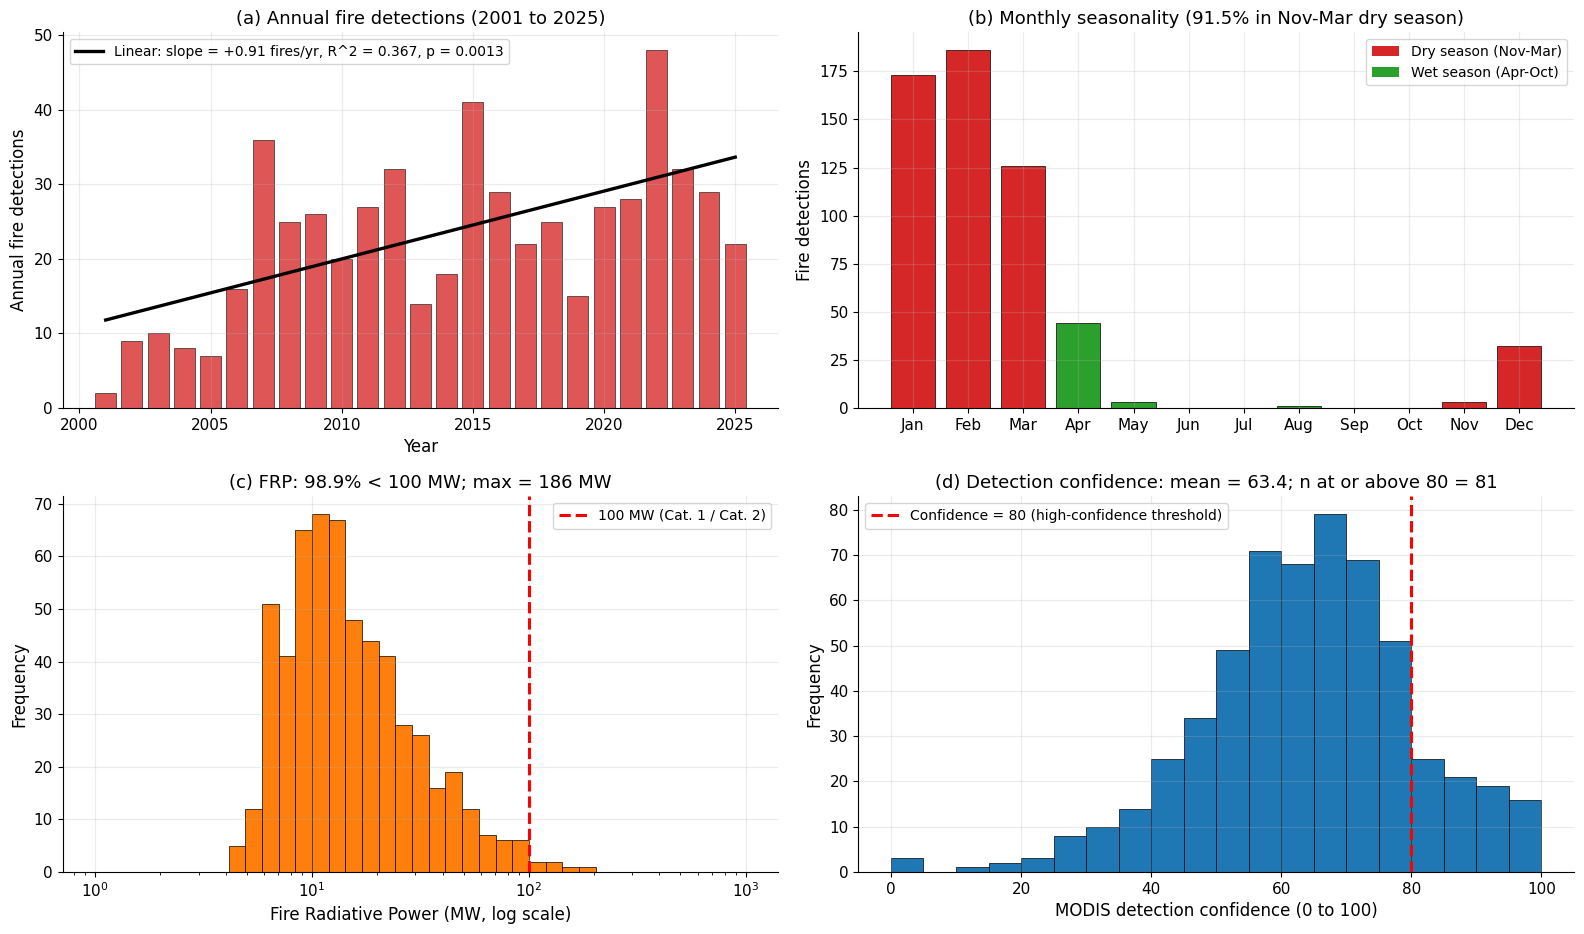

In [57]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9.5))

# (a) annual trend
ax = axes[0, 0]
ax.bar(yr_arr, cs_arr, color='#d62728', alpha=0.78, edgecolor='black', linewidth=0.5)
ax.plot(yr_arr, intercept + slope * yr_arr, 'k-', linewidth=2.4,
         label=f'Linear: slope = +{slope:.2f} fires/yr, R^2 = {r_lin**2:.3f}, p = {p_lin:.4f}')
# ax.text(0.98, 0.97, f'Mann-Kendall:\nZ = {Z_mk:.2f}, p = {p_mk:.3f}',
#          transform=ax.transAxes, fontsize=11, va='top', ha='right',
#          bbox=dict(boxstyle='round', facecolor='#f5f5dc', alpha=0.9))
ax.set_xlabel('Year'); ax.set_ylabel('Annual fire detections')
ax.set_title('(a) Annual fire detections (2001 to 2025)')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.25)

# (b) monthly seasonality
ax = axes[0, 1]
mcs = fire_df.groupby('month').size().reindex(range(1, 13), fill_value=0)
colors_m = ['#d62728' if m in [11, 12, 1, 2, 3] else '#2ca02c' for m in mcs.index]
ax.bar(mcs.index, mcs.values, color=colors_m, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_ylabel('Fire detections')
ax.set_title(f'(b) Monthly seasonality ({pct_dry:.1f}% in Nov-Mar dry season)')
ax.legend(handles=[Patch(facecolor='#d62728', label='Dry season (Nov-Mar)'),
                     Patch(facecolor='#2ca02c', label='Wet season (Apr-Oct)')],
           loc='upper right', fontsize=10)
ax.grid(True, alpha=0.25)

# (c) FRP distribution
ax = axes[1, 0]
ax.hist(frp, bins=np.logspace(0, 3, 40), color='#ff7f0e',
         edgecolor='black', linewidth=0.5)
ax.axvline(100, color='red', linestyle='--', linewidth=2.2,
            label='100 MW (Cat. 1 / Cat. 2)')
ax.set_xscale('log')
ax.set_xlabel('Fire Radiative Power (MW, log scale)')
ax.set_ylabel('Frequency')
ax.set_title(f'(c) FRP: {pct_cat1:.1f}% < 100 MW; max = {frp.max():.0f} MW')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.25)

# (d) confidence distribution
ax = axes[1, 1]
ax.hist(conf, bins=20, color='#1f77b4', edgecolor='black', linewidth=0.5)
ax.axvline(80, color='red', linestyle='--', linewidth=2.2,
            label='Confidence = 80 (high-confidence threshold)')
ax.set_xlabel('MODIS detection confidence (0 to 100)')
ax.set_ylabel('Frequency')
n_high = int((conf >= 80).sum())
ax.set_title(f'(d) Detection confidence: mean = {conf.mean():.1f}; n at or above 80 = {n_high}')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.25)

fig.tight_layout()
fig.savefig(f'{OUT_DIR}/figures/fig3_fire_regime.png', dpi=300, bbox_inches='tight')
fig.savefig(f'{OUT_DIR}/figures/fig3_fire_regime.pdf', bbox_inches='tight')
plt.show()

### Figure 4. Climate–fire temporal coupling
Annual precipitation and temperature trends, and the quasi-Poisson precipitation fit.

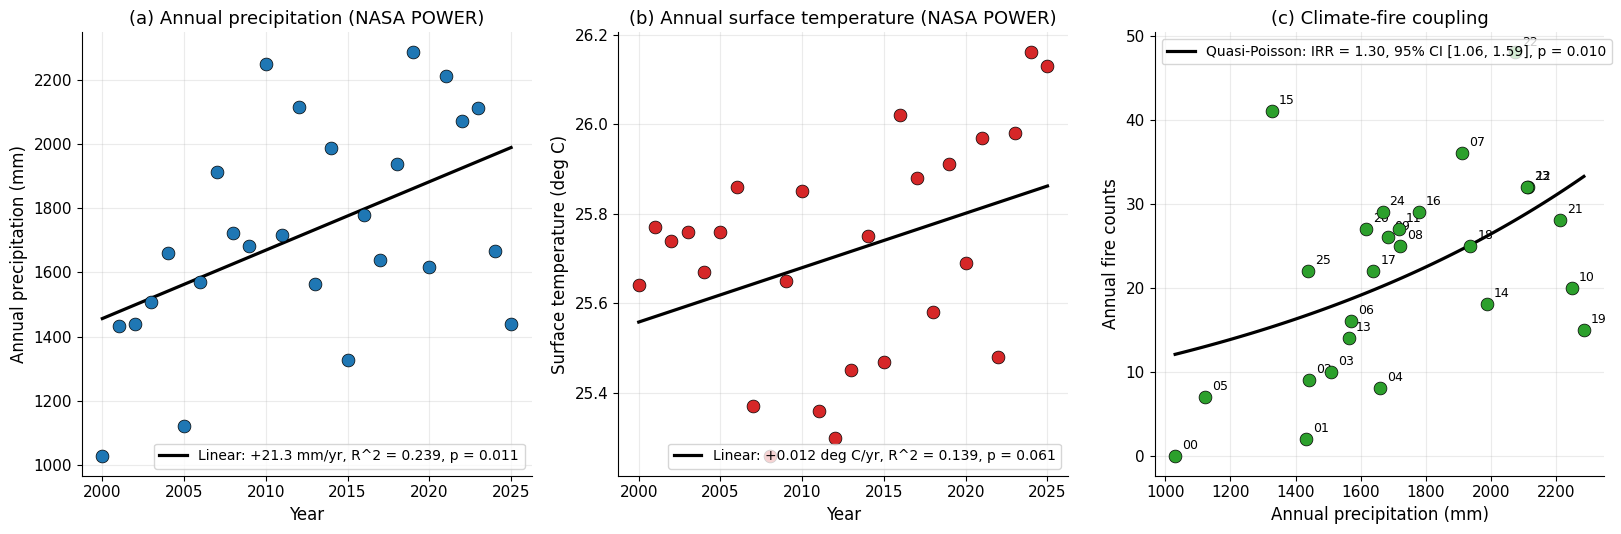

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

ax = axes[0]
sp, ip, rp, pp, _ = stats.linregress(y_c, precip_arr)
_, Zp, ppk = mann_kendall(precip_arr)
ax.scatter(y_c, precip_arr, s=85, color='#1f77b4', edgecolor='black', linewidth=0.5, zorder=5)
ax.plot(y_c, ip + sp * y_c, 'k-', linewidth=2.3,
         label=f'Linear: {sp:+.1f} mm/yr, R^2 = {rp**2:.3f}, p = {pp:.3f}')
ax.set_xlabel('Year'); ax.set_ylabel('Annual precipitation (mm)')
ax.set_title('(a) Annual precipitation (NASA POWER)')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.25)

ax = axes[1]
st, it, rt, pt, _ = stats.linregress(y_c, temp_arr)
_, Zt, ptk = mann_kendall(temp_arr)
ax.scatter(y_c, temp_arr, s=85, color='#d62728', edgecolor='black', linewidth=0.5, zorder=5)
ax.plot(y_c, it + st * y_c, 'k-', linewidth=2.3,
         label=f'Linear: {st:+.3f} deg C/yr, R^2 = {rt**2:.3f}, p = {pt:.3f}')
ax.set_xlabel('Year'); ax.set_ylabel('Surface temperature (deg C)')
ax.set_title('(b) Annual surface temperature (NASA POWER)')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.25)

ax = axes[2]
IRR = float(np.exp(b1[1]))
irr_lo = float(np.exp(b1[1] - 1.96 * s1[1]))
irr_hi = float(np.exp(b1[1] + 1.96 * s1[1]))
p_irr = 2 * (1 - stats.norm.cdf(abs(b1[1] / s1[1])))
ax.scatter(precip_arr, yc_counts, s=85, color='#2ca02c', edgecolor='black', linewidth=0.5, zorder=5)
for x, y, yv in zip(precip_arr, yc_counts, y_c):
    ax.annotate(f'{yv % 100:02d}', xy=(x, y), xytext=(5, 5),
                 textcoords='offset points', fontsize=9)
xs_plot = np.linspace(precip_arr.min(), precip_arr.max(), 100)
xs_z = (xs_plot - precip_arr.mean()) / precip_arr.std()
ax.plot(xs_plot, np.exp(b1[0] + b1[1] * xs_z), 'k-', linewidth=2.3,
         label=f'Quasi-Poisson: IRR = {IRR:.2f}, 95% CI [{irr_lo:.2f}, {irr_hi:.2f}], p = {p_irr:.3f}')
ax.set_xlabel('Annual precipitation (mm)')
ax.set_ylabel('Annual fire counts')
ax.set_title('(c) Climate-fire coupling')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.25)

fig.tight_layout()
fig.savefig(f'{OUT_DIR}/figures/fig4_climate_fire.png', dpi=300, bbox_inches='tight')
fig.savefig(f'{OUT_DIR}/figures/fig4_climate_fire.pdf', bbox_inches='tight')
plt.show()

### Figure 5. Climate criterion pixel-value diagnostic
Resampled NASA POWER humidity/precipitation rasters and their pixel-value distributions.

Climate criterion pixel-value diagnostic (within reserve):

             Layer  Within-reserve pixels  Distinct values      Min      Max      SD
     Humidity 2005                 190156             1936   80.000   83.000  1.3426
Precipitation 2015                 190156             6103 1327.000 1442.000 51.4659
     Humidity 2025                 190167              900   87.904   88.803  0.1861


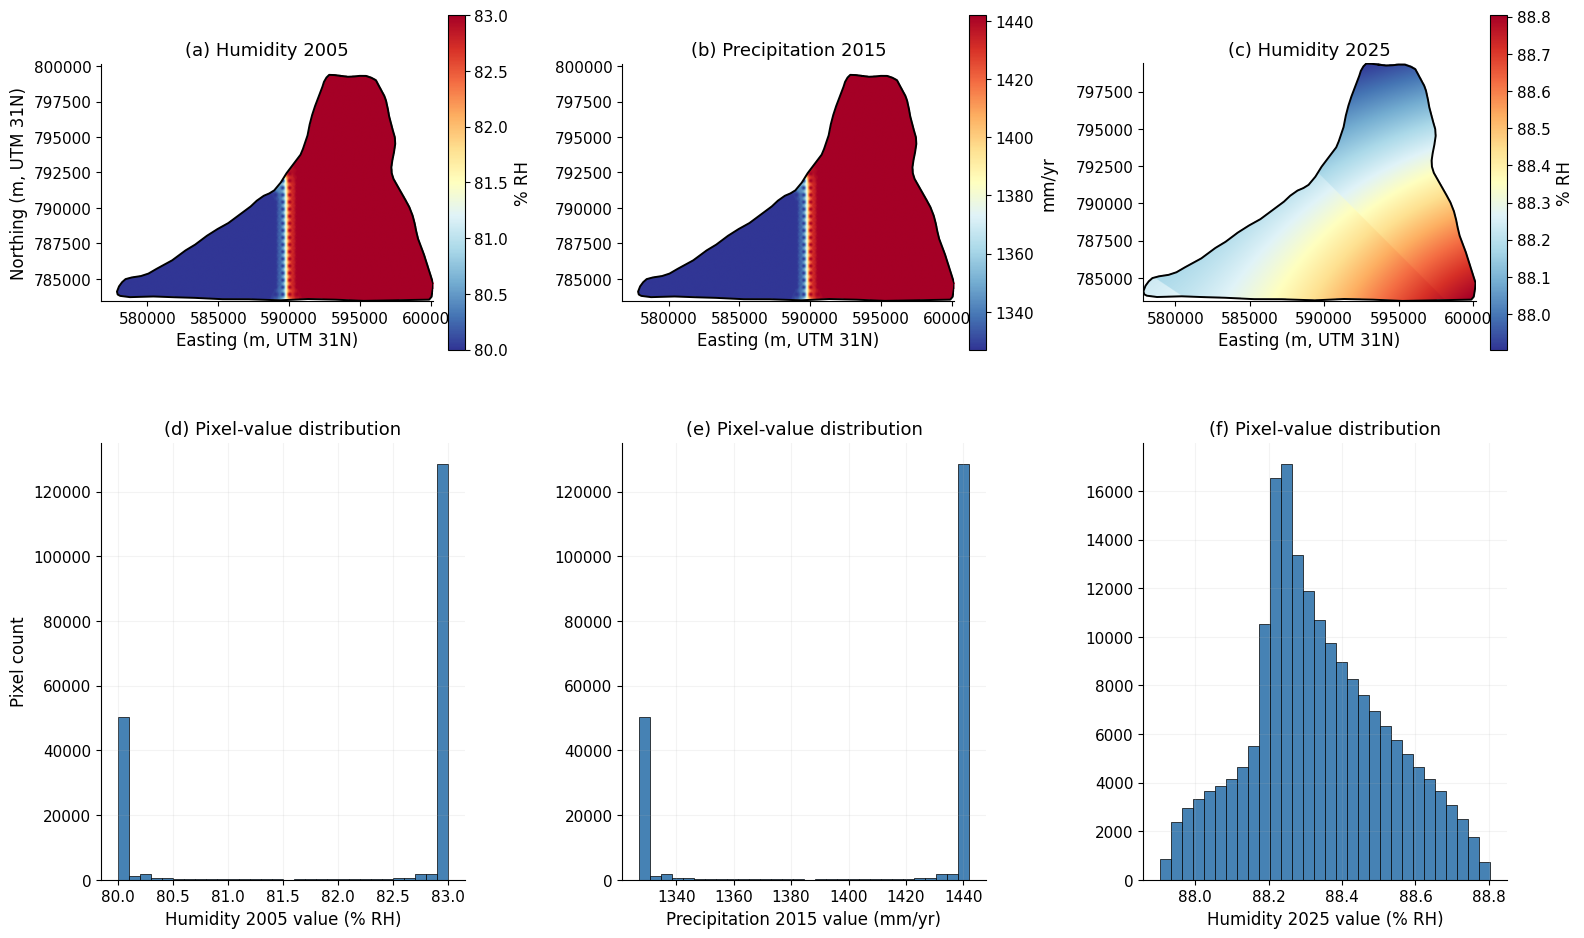

In [59]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
clim_layers = [
    ('Humidity 2005',      f'{ROOT}/AHP Weight Overlay Layers/Humidity_2005.tif',      '% RH'),
    ('Precipitation 2015', f'{ROOT}/AHP Weight Overlay Layers/Precipitation_2015.tif', 'mm/yr'),
    ('Humidity 2025',      f'{ROOT}/AHP Weight Overlay Layers/Humidity_2025.tif',      '% RH'),
]
clim_diag_rows = []
for i, (name, path, unit) in enumerate(clim_layers):
    arr, w = read_tif_geo(path)
    H_, W_ = arr.shape
    xs_ = w['ox'] + (np.arange(W_) + 0.5) * w['px']
    ys_ = w['oy'] - (np.arange(H_) + 0.5) * w['py']
    ax = axes[0, i]
    im = ax.imshow(arr, cmap='RdYlBu_r',
                    extent=[xs_.min(), xs_.max(), ys_.min(), ys_.max()],
                    aspect='equal', origin='upper')
    ax.plot(ring_x, ring_y, 'k-', linewidth=1.4)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=unit)
    ax.set_title(f'({chr(97+i)}) {name}')
    ax.set_xlabel('Easting (m, UTM 31N)')
    if i == 0: ax.set_ylabel('Northing (m, UTM 31N)')
    ax2 = axes[1, i]
    valid = arr[~np.isnan(arr)]
    ax2.hist(valid, bins=30, color='#4682b4', edgecolor='black', linewidth=0.5)
    ax2.set_xlabel(f'{name} value ({unit})')
    if i == 0: ax2.set_ylabel('Pixel count')
    ax2.set_title(f'({chr(100+i)}) Pixel-value distribution')
    ax2.grid(True, alpha=0.15)
    # within-reserve pixel statistics (the quantity reported in the text)
    _xv, _yv = np.meshgrid(xs_, ys_)
    _ins = points_in_polygon(_xv.ravel(), _yv.ravel(), np.array(reserve_outer)).reshape(arr.shape)
    _vin = arr[_ins & ~np.isnan(arr)]
    clim_diag_rows.append([name, int(_vin.size), int(np.unique(np.round(_vin, 3)).size),
                           round(float(_vin.min()), 3), round(float(_vin.max()), 3),
                           round(float(_vin.std()), 4)])


clim_diag = pd.DataFrame(clim_diag_rows,
    columns=['Layer', 'Within-reserve pixels', 'Distinct values', 'Min', 'Max', 'SD'])
print('Climate criterion pixel-value diagnostic (within reserve):\n')
print(clim_diag.to_string(index=False))
clim_diag.to_csv(f'{OUT_DIR}/tables/climate_diagnostic.csv', index=False)

fig.tight_layout()
fig.savefig(f'{OUT_DIR}/figures/fig5_climate_diag.png', dpi=300, bbox_inches='tight')
fig.savefig(f'{OUT_DIR}/figures/fig5_climate_diag.pdf', bbox_inches='tight')
plt.show()

### Figure 6. AHP fire-risk map and lift validation
Literature-weight AHP surface with detections overlaid, and per-class lift (inverted High class).

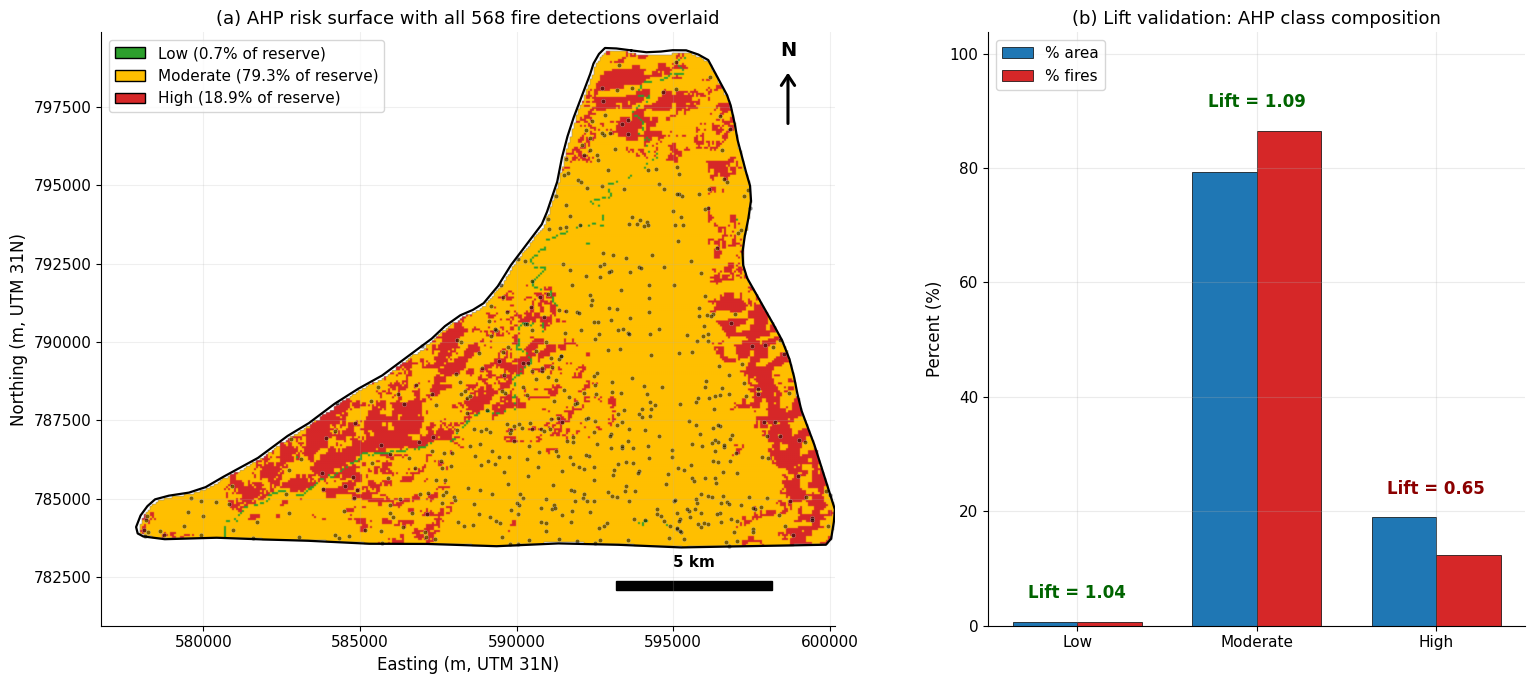

In [60]:
# In-reserve area percentages per AHP class
H_a, W_a = ahp.shape
xs_a = ahp_w['ox'] + (np.arange(W_a) + 0.5) * ahp_w['px']
ys_a = ahp_w['oy'] - (np.arange(H_a) + 0.5) * ahp_w['py']
xs_2d, ys_2d = np.meshgrid(xs_a, ys_a)
in_res = points_in_polygon(xs_2d.ravel(), ys_2d.ravel(),
                              np.array(reserve_outer)).reshape(H_a, W_a)
n_in_res = in_res.sum()
area_pct = {c: 100 * ((ahp == c) & in_res).sum() / n_in_res for c in (1, 2, 3)}

ahp_at_fire = sample_raster(ahp, ahp_w, fire_df['x_utm'].values, fire_df['y_utm'].values)
n_f = len(fire_df)
fire_pct = {c: 100 * (ahp_at_fire == c).sum() / n_f for c in (1, 2, 3)}
lifts = {c: fire_pct[c] / area_pct[c] if area_pct[c] > 0 else np.nan for c in (1, 2, 3)}

fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                          gridspec_kw={'width_ratios': [1.6, 1]})

# (a) AHP map
ax = axes[0]
ahp_show = np.ma.array(ahp.copy(), mask=(ahp == 0) | (ahp > 3))
cmap_ahp = mpl.colors.ListedColormap(['#2ca02c', '#ffbf00', '#d62728'])
norm = mpl.colors.BoundaryNorm([0.5, 1.5, 2.5, 3.5], cmap_ahp.N)
ax.imshow(ahp_show, cmap=cmap_ahp, norm=norm,
           extent=[xs_a.min(), xs_a.max(), ys_a.min(), ys_a.max()],
           aspect='equal', origin='upper')
ax.plot(ring_x, ring_y, 'k-', linewidth=1.6)
ax.scatter(fire_df['x_utm'], fire_df['y_utm'], s=10, color='black',
            edgecolor='white', linewidth=0.3, alpha=0.50)
margin = 2500
ax.set_ylim(ring_y.min() - margin, ring_y.max() + 500)
add_scale_bar(ax, x=ring_x.max() - 7000, y=ring_y.min() - margin * 0.55,
               length_m=5000, height_m=300, label='5 km',
               label_offset_m=350)
add_north_arrow(ax, x=ring_x.max() - 1500, y=ring_y.max() - 700,
                  length_m=1800)
ax.set_xlabel('Easting (m, UTM 31N)')
ax.set_ylabel('Northing (m, UTM 31N)')
ax.set_title(f'(a) AHP risk surface with all {n_f} fire detections overlaid')
ax.legend(handles=[
    Patch(facecolor='#2ca02c', edgecolor='black', label=f'Low ({area_pct[1]:.1f}% of reserve)'),
    Patch(facecolor='#ffbf00', edgecolor='black', label=f'Moderate ({area_pct[2]:.1f}% of reserve)'),
    Patch(facecolor='#d62728', edgecolor='black', label=f'High ({area_pct[3]:.1f}% of reserve)'),
], loc='upper left', fontsize=11)
ax.grid(True, alpha=0.2)

# (b) lift bars with headroom for labels
ax = axes[1]
classes = ['Low', 'Moderate', 'High']
x = np.arange(3); w_bar = 0.36
area_vals = [area_pct[c] for c in (1, 2, 3)]
fire_vals = [fire_pct[c] for c in (1, 2, 3)]
lift_vals = [lifts[c] for c in (1, 2, 3)]
ax.bar(x - w_bar/2, area_vals, w_bar, label='% area',
        color='#1f77b4', edgecolor='black', linewidth=0.5)
ax.bar(x + w_bar/2, fire_vals, w_bar, label='% fires',
        color='#d62728', edgecolor='black', linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels(classes)
ax.set_ylabel('Percent (%)')
ax.set_title('(b) Lift validation: AHP class composition')
ax.legend(loc='upper left', fontsize=11)
ylim_top = max(max(area_vals), max(fire_vals)) * 1.20
ax.set_ylim(0, ylim_top)
for i, lift in enumerate(lift_vals):
    color = 'darkred' if lift < 1 else 'darkgreen'
    top = max(area_vals[i], fire_vals[i]) + ylim_top * 0.04
    ax.text(i, top, f'Lift = {lift:.2f}', ha='center', fontsize=12,
             fontweight='bold', color=color)
ax.grid(True, alpha=0.25)

fig.tight_layout()
fig.savefig(f'{OUT_DIR}/figures/fig6_ahp_map_lift.png', dpi=300, bbox_inches='tight')
fig.savefig(f'{OUT_DIR}/figures/fig6_ahp_map_lift.pdf', bbox_inches='tight')
plt.show()

### Figure 7. Data-driven probability surface and validation
Logistic-regression probability surface (500 m exclusion) discretised into tertiles, with monotonic lift.

Figure 7 lift (Low/Mod/High): 0.581 / 0.961 / 1.437


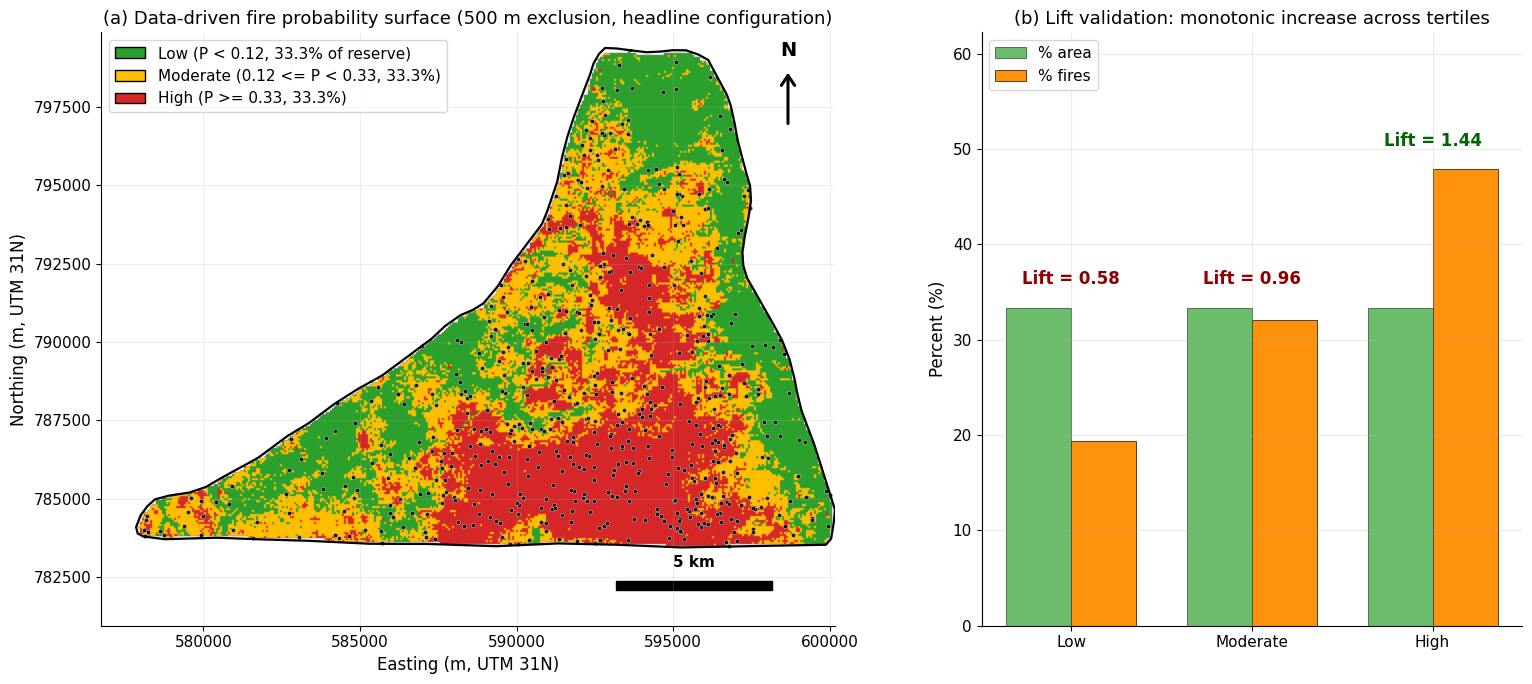

In [61]:
# Refit the headline logistic regression on the 500 m exclusion data
X500_log = df500[cols_cont].values.copy()
for j, c in enumerate(cols_cont):
    if c.startswith('D2'):
        X500_log[:, j] = np.log(np.clip(X500_log[:, j], 1, None))
mu_X500, sd_X500 = X500_log.mean(axis=0), X500_log.std(axis=0)
X500z_fig6 = (X500_log - mu_X500) / sd_X500
y500_fig6 = df500['fire'].values.astype(int)
lr_fig6 = LogisticRegression(max_iter=5000, C=1e6).fit(X500z_fig6, y500_fig6)
auc_in_fig6 = roc_auc_score(y500_fig6, lr_fig6.predict_proba(X500z_fig6)[:, 1])

# Predict on the AHP grid using the 500m-trained logistic regression
xs_flat = xs_2d.ravel(); ys_flat = ys_2d.ravel()
X_grid = np.zeros((len(xs_flat), len(cols_cont)))
for j, c in enumerate(cols_cont):
    arr_, w_ = layers[c]
    X_grid[:, j] = sample_raster(arr_, w_, xs_flat, ys_flat)
for j, c in enumerate(cols_cont):
    if c.startswith('D2'):
        X_grid[:, j] = np.log(np.clip(X_grid[:, j], 1, None))
X_grid_z = (X_grid - mu_X500) / sd_X500
valid_g = ~np.isnan(X_grid_z).any(axis=1)
prob_grid = np.full(len(xs_flat), np.nan)
prob_grid[valid_g] = lr_fig6.predict_proba(X_grid_z[valid_g])[:, 1]
prob_grid[~in_res.ravel()] = np.nan
prob_2d = prob_grid.reshape(H_a, W_a)
valid_in = prob_grid[~np.isnan(prob_grid)]
breaks = np.percentile(valid_in, [33.33, 66.67])
risk_2d = np.full_like(prob_2d, np.nan)
risk_2d[prob_2d <= breaks[0]] = 1
risk_2d[(prob_2d > breaks[0]) & (prob_2d <= breaks[1])] = 2
risk_2d[prob_2d > breaks[1]] = 3

# Lift validation on fire detections
risk_at_fire = sample_raster(risk_2d, ahp_w,
                                fire_df['x_utm'].values, fire_df['y_utm'].values)
area_pct_d = {c: 100 * np.nansum(risk_2d == c) / np.nansum(~np.isnan(risk_2d)) for c in (1, 2, 3)}
fire_pct_d = {c: 100 * (risk_at_fire == c).sum() / len(fire_df) for c in (1, 2, 3)}
lift_d = {c: fire_pct_d[c] / area_pct_d[c] if area_pct_d[c] > 0 else np.nan for c in (1, 2, 3)}
print(f'Figure 7 lift (Low/Mod/High): {lift_d[1]:.3f} / {lift_d[2]:.3f} / {lift_d[3]:.3f}')

# CV AUC for the 500m configuration logistic regression
def cv_auc_simple(factory, X, y, seeds=(42, 43, 44)):
    aucs = []
    for s in seeds:
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=s)
        for tr, te in skf.split(X, y):
            m = factory(); m.fit(X[tr], y[tr])
            sc = m.predict_proba(X[te])[:, 1] if hasattr(m, 'predict_proba') else m.decision_function(X[te])
            aucs.append(roc_auc_score(y[te], sc))
    return float(np.mean(aucs)), float(np.std(aucs))
cv_mean_lr, cv_sd_lr = cv_auc_simple(lambda: LogisticRegression(max_iter=5000, C=1e6), X500z_fig6, y500_fig6)

fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                          gridspec_kw={'width_ratios': [1.6, 1]})

ax = axes[0]
risk_show = np.ma.array(risk_2d, mask=np.isnan(risk_2d))
cmap_d = mpl.colors.ListedColormap(['#2ca02c', '#ffbf00', '#d62728'])
norm_d = mpl.colors.BoundaryNorm([0.5, 1.5, 2.5, 3.5], cmap_d.N)
ax.imshow(risk_show, cmap=cmap_d, norm=norm_d,
           extent=[xs_a.min(), xs_a.max(), ys_a.min(), ys_a.max()],
           aspect='equal', origin='upper')
ax.plot(ring_x, ring_y, 'k-', linewidth=1.6)
ax.scatter(fire_df['x_utm'], fire_df['y_utm'], s=10, color='black',
            edgecolor='white', linewidth=0.3, alpha=0.85)

margin = 2500
ax.set_ylim(ring_y.min() - margin, ring_y.max() + 500)
add_scale_bar(ax, x=ring_x.max() - 7000, y=ring_y.min() - margin * 0.55,
               length_m=5000, height_m=300, label='5 km',
               label_offset_m=350)

add_north_arrow(ax, x=ring_x.max() - 1500, y=ring_y.max() - 700,
                  length_m=1800)
ax.set_xlabel('Easting (m, UTM 31N)')
ax.set_ylabel('Northing (m, UTM 31N)')
ax.set_title('(a) Data-driven fire probability surface (500 m exclusion, headline configuration)')
ax.legend(handles=[
    Patch(facecolor='#2ca02c', edgecolor='black',
           label=f'Low (P < {breaks[0]:.2f}, {area_pct_d[1]:.1f}% of reserve)'),
    Patch(facecolor='#ffbf00', edgecolor='black',
           label=f'Moderate ({breaks[0]:.2f} <= P < {breaks[1]:.2f}, {area_pct_d[2]:.1f}%)'),
    Patch(facecolor='#d62728', edgecolor='black',
           label=f'High (P >= {breaks[1]:.2f}, {area_pct_d[3]:.1f}%)'),
], loc='upper left', fontsize=11)
ax.grid(True, alpha=0.2)

ax = axes[1]
x = np.arange(3); w_bar = 0.36
area_dv = [area_pct_d[c] for c in (1, 2, 3)]
fire_dv = [fire_pct_d[c] for c in (1, 2, 3)]
lift_dv = [lift_d[c] for c in (1, 2, 3)]
ax.bar(x - w_bar/2, area_dv, w_bar, label='% area',
        color='#2ca02c', edgecolor='black', linewidth=0.5, alpha=0.7)
ax.bar(x + w_bar/2, fire_dv, w_bar, label='% fires',
        color='#ff8c00', edgecolor='black', linewidth=0.5, alpha=0.95)
ax.set_xticks(x); ax.set_xticklabels(['Low', 'Moderate', 'High'])
ax.set_ylabel('Percent (%)')
ax.set_title('(b) Lift validation: monotonic increase across tertiles')
ylim_top = max(max(area_dv), max(fire_dv)) * 1.30
ax.set_ylim(0, ylim_top)
ax.legend(loc='upper left', fontsize=11)
for i, lift in enumerate(lift_dv):
    color = 'darkred' if lift < 1 else 'darkgreen'
    top = max(area_dv[i], fire_dv[i]) + ylim_top * 0.04
    ax.text(i, top, f'Lift = {lift:.2f}', ha='center', fontsize=12,
             fontweight='bold', color=color)
ax.grid(True, alpha=0.25)

fig.tight_layout()
fig.savefig(f'{OUT_DIR}/figures/fig7_datadriven.png', dpi=300, bbox_inches='tight')
fig.savefig(f'{OUT_DIR}/figures/fig7_datadriven.pdf', bbox_inches='tight')
plt.show()

### Figure 8. ROC curves (AHP vs data-driven)
Literature AHP, empirical-weight AHP, and the four data-driven models under cross-validation. Builds the empirical-weight comparator used by Tables S1 and S6.

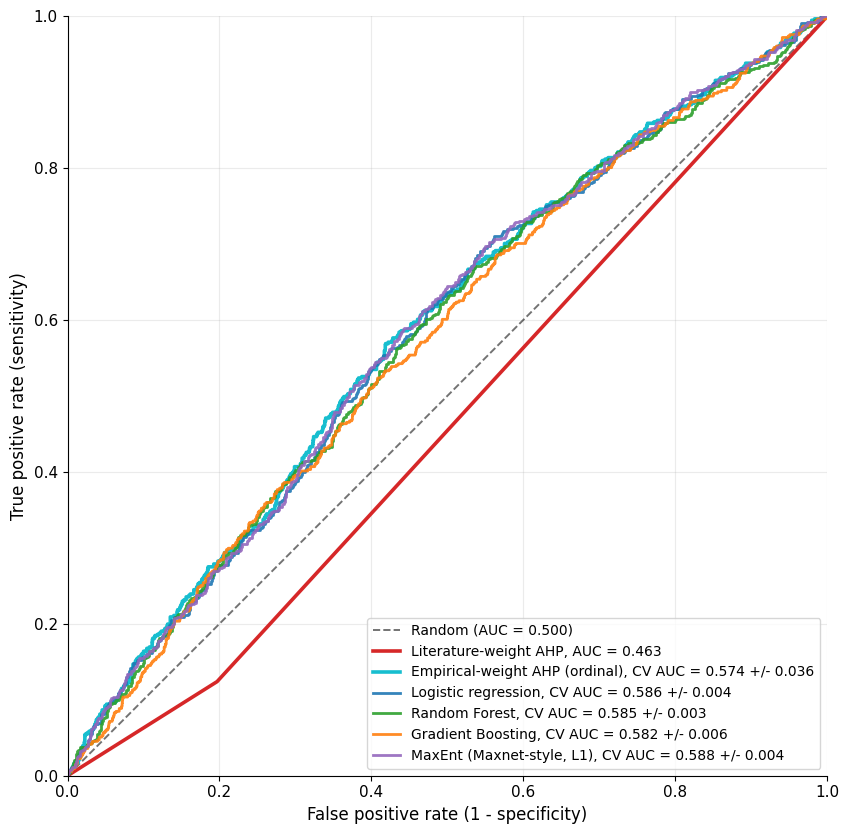

In [62]:
# Build the empirical-weight AHP comparator for the ROC overlay
all_crits = ['NDVI_2025','LST_2025','Slope','Aspect','Elevation','D2Place','D2Road','D2Water']
df_d_full = df_d.dropna(subset=['Humidity_2015','Precipitation_2015']).copy()
crits10 = all_crits + ['Humidity_2015','Precipitation_2015']

Xp = df_d_full[crits10].values
Xp_z = (Xp - Xp.mean(axis=0)) / Xp.std(axis=0)
yp = df_d_full['fire'].values.astype(int)
probe = LogisticRegression(max_iter=5000, C=1e6).fit(Xp_z, yp)
sign_map = {k: int(np.sign(probe.coef_[0][j])) for j, k in enumerate(crits10)}

def jenks_breaks(values, n_classes=5):
    rng_ = np.random.default_rng(SEED)
    vals = np.asarray(values, dtype=float).reshape(-1, 1)
    if len(vals) > 5000:
        vals = vals[rng_.choice(len(vals), 5000, replace=False)]
    km = KMeans(n_clusters=n_classes, n_init=10, random_state=SEED).fit(vals)
    c = sorted(km.cluster_centers_.ravel())
    return np.array([(c[i] + c[i+1]) / 2 for i in range(len(c) - 1)])

def assign_classes(values, breaks, sign):
    cls = np.searchsorted(breaks, values) + 1
    cls = np.clip(cls, 1, 5)
    if sign == -1: cls = 6 - cls
    return cls

disc_cols = []
for k in crits10:
    br = jenks_breaks(df_d_full[k].values, 5)
    df_d_full[f'{k}_cls'] = assign_classes(df_d_full[k].values, br, sign_map[k])
    disc_cols.append(f'{k}_cls')
X_disc = df_d_full[disc_cols].values.astype(float)
X_disc_z = (X_disc - X_disc.mean(axis=0)) / X_disc.std(axis=0)
y_disc = df_d_full['fire'].values.astype(int)
lr_disc = LogisticRegression(max_iter=5000, C=1.0).fit(X_disc_z, y_disc)
abs_w = np.abs(lr_disc.coef_[0]); w_frac = abs_w / abs_w.sum()
score_emp = (X_disc * w_frac).sum(axis=1)
emp_cv = []
for s in (42, 43, 44):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=s)
    for tr, te in skf.split(X_disc, y_disc):
        m = LogisticRegression(max_iter=5000, C=1.0)
        Xt = X_disc[tr]; Xt_z = (Xt - Xt.mean(axis=0)) / Xt.std(axis=0)
        m.fit(Xt_z, y_disc[tr])
        w_te = np.abs(m.coef_[0]) / np.abs(m.coef_[0]).sum()
        sc_te = (X_disc[te] * w_te).sum(axis=1)
        emp_cv.append(roc_auc_score(y_disc[te], sc_te))
emp_cv_mean, emp_cv_sd = float(np.mean(emp_cv)), float(np.std(emp_cv))

def cv_roc(factory, X, y, seed=42):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    yt, ys = [], []
    for tr, te in skf.split(X, y):
        m = factory(); m.fit(X[tr], y[tr])
        sc = m.predict_proba(X[te])[:, 1] if hasattr(m, 'predict_proba') else m.decision_function(X[te])
        yt.extend(y[te]); ys.extend(sc)
    return np.array(yt), np.array(ys)

factories7 = {
    'Logistic regression':        (lambda: LogisticRegression(max_iter=5000, C=1e6), '#1f77b4'),
    'Random Forest':              (lambda: RandomForestClassifier(n_estimators=100, max_depth=6, random_state=SEED, n_jobs=-1), '#2ca02c'),
    'Gradient Boosting':          (lambda: GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=SEED), '#ff7f0e'),
    'MaxEnt (Maxnet-style, L1)':  (lambda: LogisticRegression(max_iter=5000, C=0.5, solver='liblinear', penalty='l1'), '#9467bd'),
}

fig, ax = plt.subplots(figsize=(9, 8.5))
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.4, alpha=0.55, label='Random (AUC = 0.500)')

# Literature AHP
y_ahp_e = np.concatenate([np.ones(len(fire_df)), np.zeros(len(abs_pts))])
sc_ahp_e = np.concatenate([ahp_at_fire, sample_raster(ahp, ahp_w, abs_pts[:, 0], abs_pts[:, 1])])
m_ahp_e = (sc_ahp_e >= 1) & (sc_ahp_e <= 3)
fpr_a, tpr_a, _ = roc_curve(y_ahp_e[m_ahp_e], sc_ahp_e[m_ahp_e])
auc_lit = roc_auc_score(y_ahp_e[m_ahp_e], sc_ahp_e[m_ahp_e])
ax.plot(fpr_a, tpr_a, color='#d62728', linewidth=2.6,
         label=f'Literature-weight AHP, AUC = {auc_lit:.3f}')

# Empirical AHP
fpr_e, tpr_e, _ = roc_curve(y_disc, score_emp)
ax.plot(fpr_e, tpr_e, color='#17becf', linewidth=2.6,
         label=f'Empirical-weight AHP (ordinal), CV AUC = {emp_cv_mean:.3f} +/- {emp_cv_sd:.3f}')

for name, (factory, color) in factories7.items():
    auc_list = [cv_auc_simple(factory, X_z, y_d, seeds=(s,))[0] for s in (42, 43, 44)]
    auc_mean = float(np.mean(auc_list)); auc_sd = float(np.std(auc_list))
    yt, ys = cv_roc(factory, X_z, y_d, seed=42)
    fpr, tpr, _ = roc_curve(yt, ys)
    ax.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{name}, CV AUC = {auc_mean:.3f} +/- {auc_sd:.3f}', alpha=0.9)

ax.set_xlabel('False positive rate (1 - specificity)')
ax.set_ylabel('True positive rate (sensitivity)')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(f'{OUT_DIR}/figures/fig8_roc.png', dpi=300, bbox_inches='tight')
fig.savefig(f'{OUT_DIR}/figures/fig8_roc.pdf', bbox_inches='tight')
plt.show()

### Figure 9. Stakeholder perceptions
Questionnaire item Yes-rates with Wilson 95% CIs across seven thematic blocks.

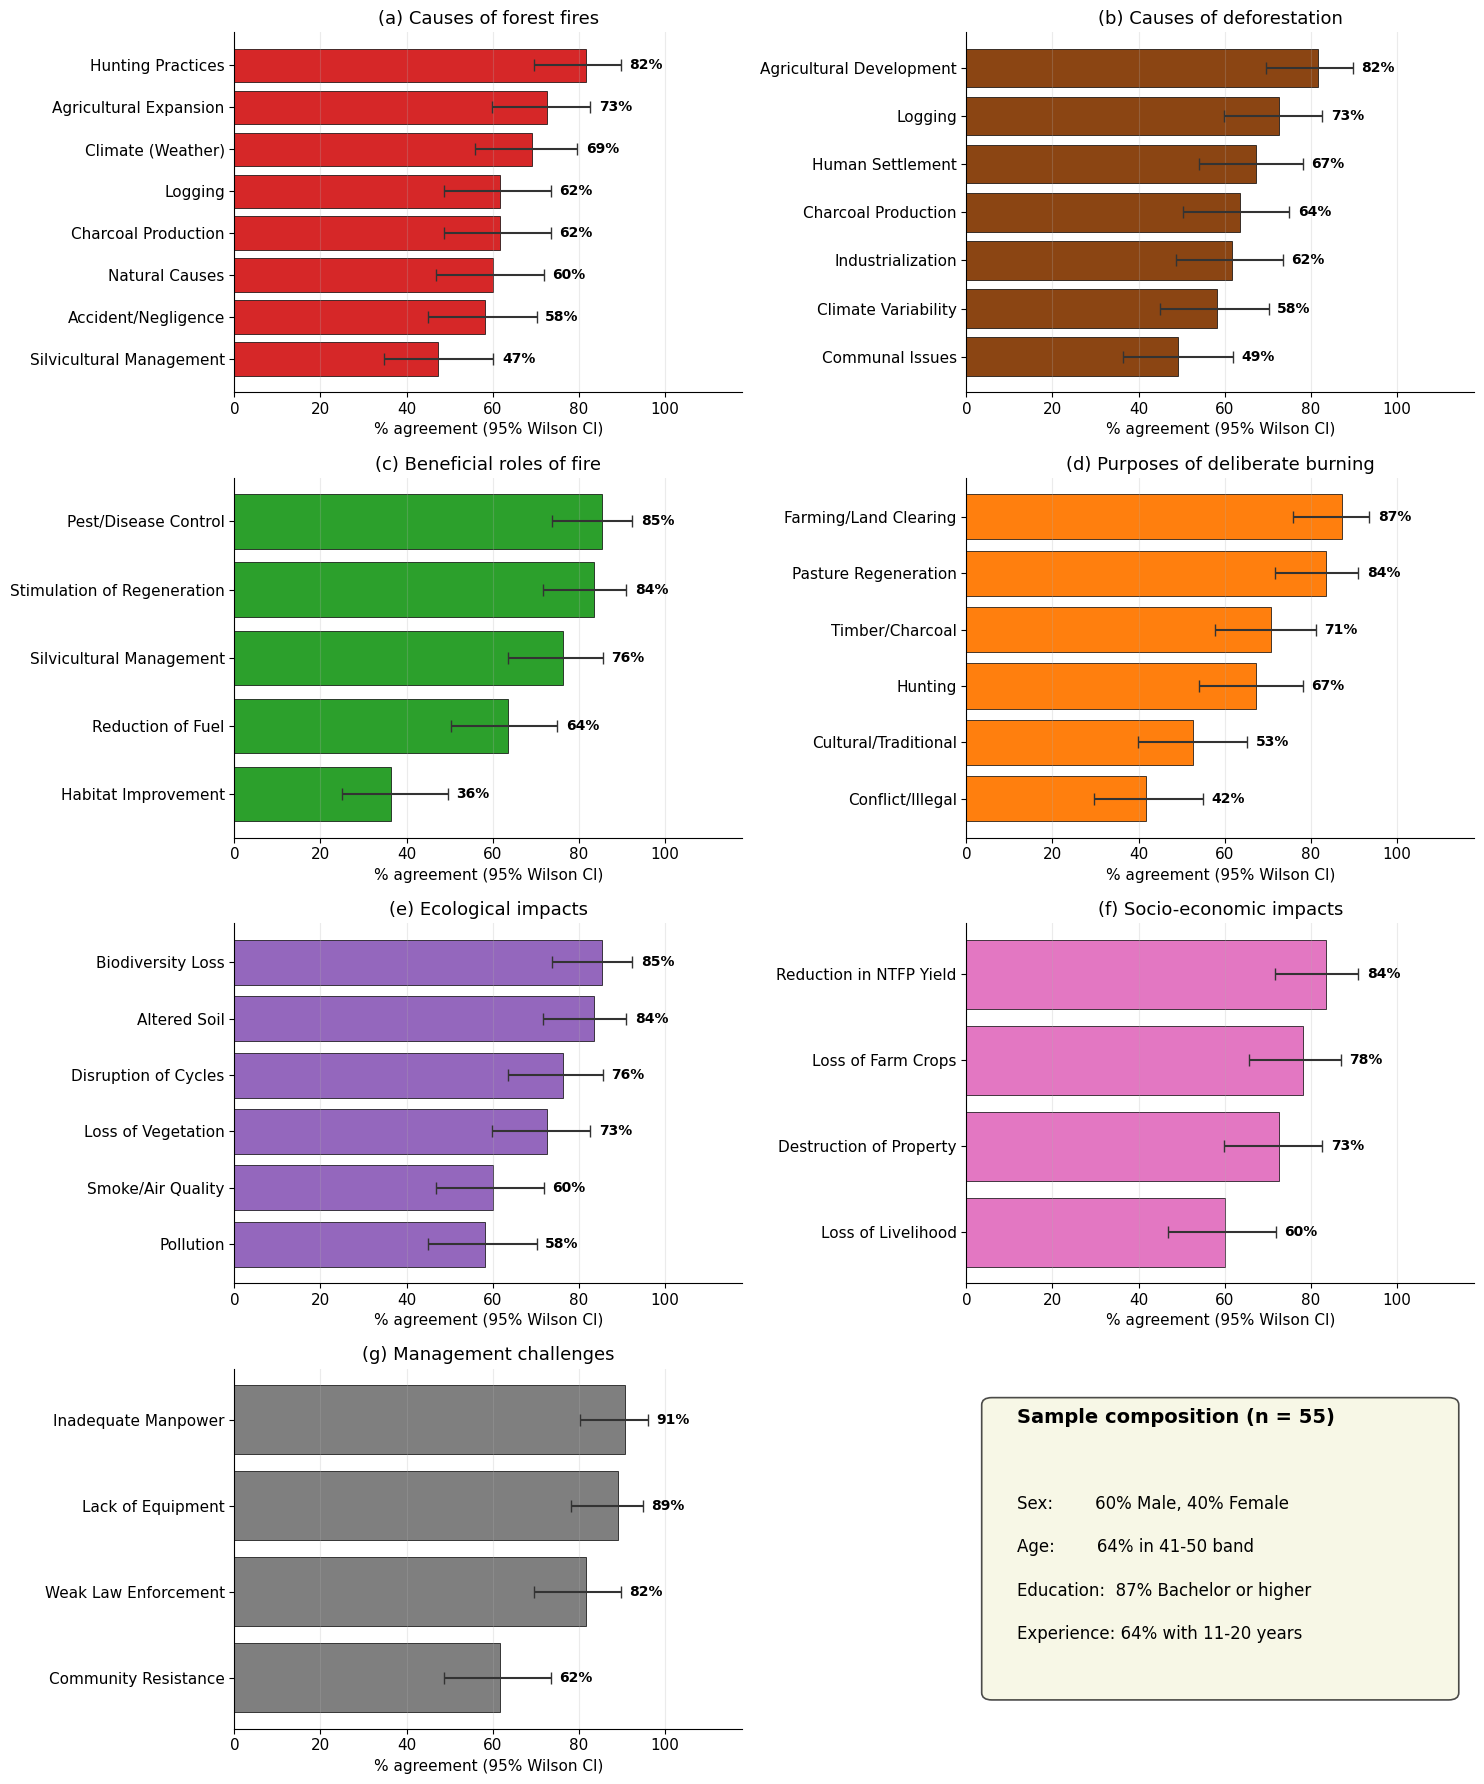

In [63]:
def stack_counts(df, cols, labels):
    out = []
    for c, lbl in zip(cols, labels):
        vals = df[c].astype(str).str.strip().str.lower()
        positive = vals.isin(['yes', 'true', '1', 'tick', 'agree', 'strongly agree', 'a'])
        if positive.sum() == 0:
            positive = vals.str.contains('agree', na=False) | vals.isin(['yes', 'y'])
        n_pos = int(positive.sum())
        n_tot = int((~vals.isin(['', 'nan', 'none'])).sum())
        if n_tot == 0: n_tot = len(df)
        p = n_pos / n_tot if n_tot > 0 else 0
        lo, hi = wilson_ci(p, n_tot)
        out.append((lbl, p * 100, lo * 100, hi * 100))
    return out

def panel(ax, items, title, color='#1f77b4'):
    items = sorted(items, key=lambda r: r[1], reverse=True)
    labels = [r[0] for r in items]
    vals   = np.array([r[1] for r in items])
    los    = np.array([r[2] for r in items])
    his    = np.array([r[3] for r in items])
    y_pos = np.arange(len(labels))
    ax.barh(y_pos, vals, color=color, edgecolor='black', linewidth=0.5,
             xerr=[vals - los, his - vals], capsize=4, ecolor='#333')
    ax.set_yticks(y_pos); ax.set_yticklabels(labels, fontsize=11)
    ax.invert_yaxis()
    ax.set_xlim(0, 118)
    ax.set_xlabel('% agreement (95% Wilson CI)', fontsize=11)
    ax.set_title(title, fontsize=13)
    for i, (v, h) in enumerate(zip(vals, his)):
        ax.text(h + 2, i, f'{v:.0f}%', va='center', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.25, axis='x')

fig, axes = plt.subplots(4, 2, figsize=(15, 18))

cause_cols = [c for c in q.columns if 'Tick as appropriate the causes of forest fires' in c]
panel(axes[0, 0], stack_counts(q, cause_cols,
        ['Agricultural Expansion', 'Hunting Practices', 'Silvicultural Management',
         'Logging', 'Charcoal Production', 'Climate (Weather)',
         'Accident/Negligence', 'Natural Causes']),
       '(a) Causes of forest fires', color='#d62728')

defor_cols = [c for c in q.columns if 'causes of deforestation' in c]
panel(axes[0, 1], stack_counts(q, defor_cols,
        ['Agricultural Development', 'Logging', 'Charcoal Production',
         'Industrialization', 'Climate Variability', 'Communal Issues', 'Human Settlement']),
       '(b) Causes of deforestation', color='#8b4513')

benef_cols = [c for c in q.columns if 'benefits of forest fire' in c]
panel(axes[1, 0], stack_counts(q, benef_cols,
        ['Stimulation of Regeneration', 'Pest/Disease Control',
         'Silvicultural Management', 'Reduction of Fuel', 'Habitat Improvement']),
       '(c) Beneficial roles of fire', color='#2ca02c')

purp_cols = [c for c in q.columns if 'purpose of deliberately using fires' in c]
panel(axes[1, 1], stack_counts(q, purp_cols,
        ['Farming/Land Clearing', 'Hunting', 'Pasture Regeneration',
         'Timber/Charcoal', 'Cultural/Traditional', 'Conflict/Illegal']),
       '(d) Purposes of deliberate burning', color='#ff7f0e')

eco_cols = [c for c in q.columns if 'ecological impacts of forest fires' in c]
panel(axes[2, 0], stack_counts(q, eco_cols,
        ['Biodiversity Loss', 'Pollution', 'Loss of Vegetation',
         'Altered Soil', 'Disruption of Cycles', 'Smoke/Air Quality']),
       '(e) Ecological impacts', color='#9467bd')

socio_cols = [c for c in q.columns if 'Socio-economic Impacts' in c]
panel(axes[2, 1], stack_counts(q, socio_cols,
        ['Loss of Livelihood', 'Destruction of Property',
         'Reduction in NTFP Yield', 'Loss of Farm Crops']),
       '(f) Socio-economic impacts', color='#e377c2')

mgmt_cols = [c for c in q.columns if 'challenges of forest fire Management' in c]
panel(axes[3, 0], stack_counts(q, mgmt_cols,
        ['Inadequate Manpower', 'Lack of Equipment',
         'Weak Law Enforcement', 'Community Resistance']),
       '(g) Management challenges', color='#7f7f7f')

# (h) Sample composition card
ax_dem = axes[3, 1]
ax_dem.axis('off')
demo_lines = [
    f'Sample composition (n = {len(q)})',
    '',
    'Sex:        60% Male, 40% Female',
    'Age:        64% in 41-50 band',
    'Education:  87% Bachelor or higher',
    'Experience: 64% with 11-20 years',
]
for i, line in enumerate(demo_lines):
    weight = 'bold' if i == 0 else 'normal'
    size = 14 if i == 0 else 12
    ax_dem.text(0.1, 0.85 - i * 0.12, line, fontsize=size, fontweight=weight,
                  transform=ax_dem.transAxes)
ax_dem.add_patch(FancyBboxPatch((0.05, 0.10), 0.90, 0.80,
                                   boxstyle='round,pad=0.02', transform=ax_dem.transAxes,
                                   facecolor='#f5f5dc', edgecolor='black',
                                   linewidth=1.2, alpha=0.7))

fig.tight_layout()
fig.savefig(f'{OUT_DIR}/figures/fig9_questionnaire.png', dpi=300, bbox_inches='tight')
fig.savefig(f'{OUT_DIR}/figures/fig9_questionnaire.pdf', bbox_inches='tight')
plt.show()

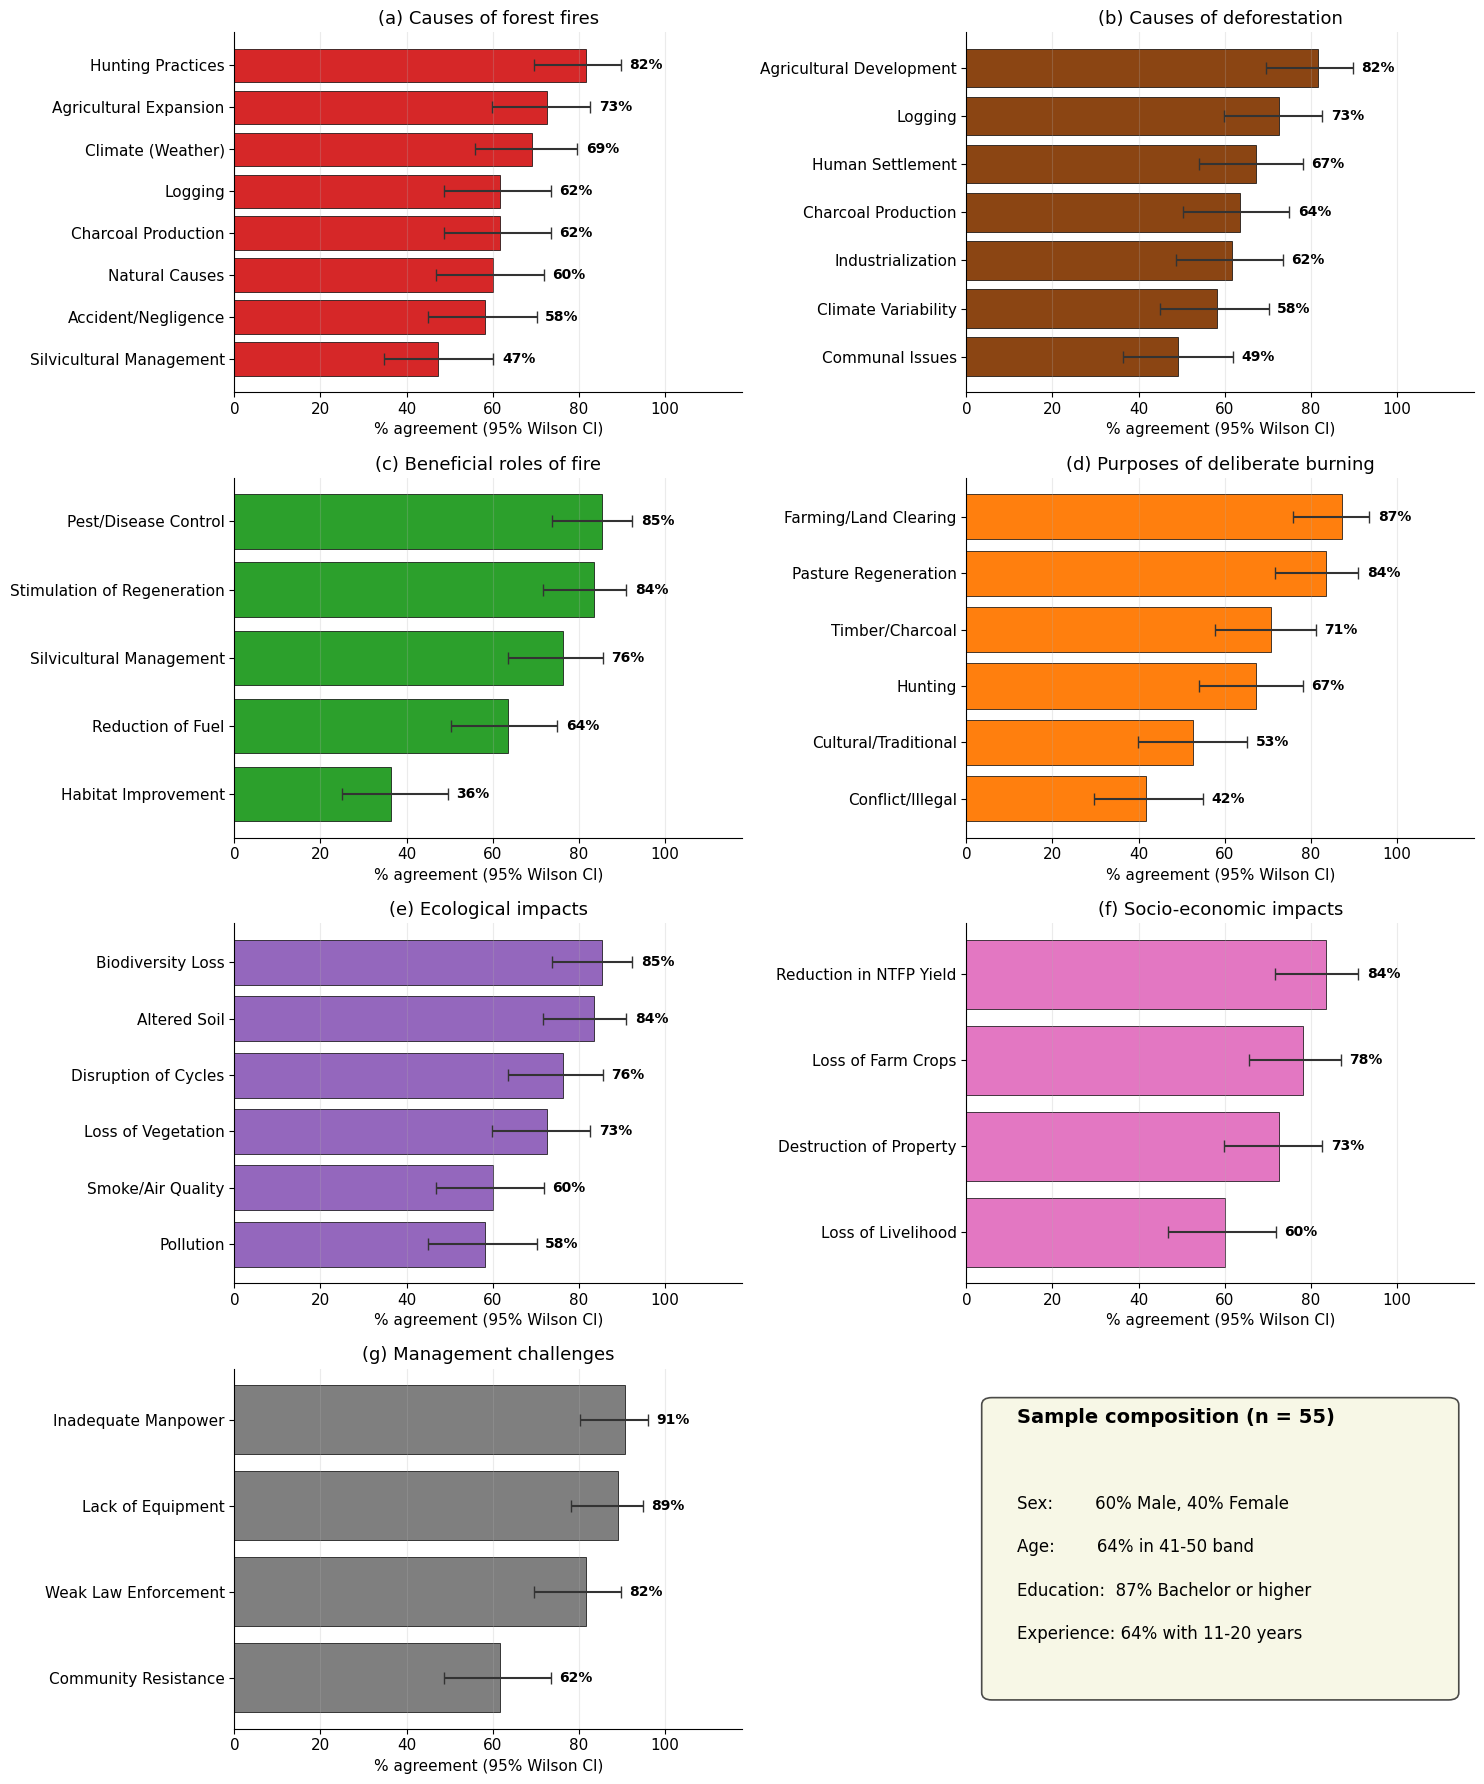

In [82]:
def stack_counts(df, cols, labels):
    out = []
    for c, lbl in zip(cols, labels):
        vals = df[c].astype(str).str.strip().str.lower()
        positive = vals.isin(['yes', 'true', '1', 'tick', 'agree', 'strongly agree', 'a'])
        if positive.sum() == 0:
            positive = vals.str.contains('agree', na=False) | vals.isin(['yes', 'y'])
        n_pos = int(positive.sum())
        n_tot = int((~vals.isin(['', 'nan', 'none'])).sum())
        if n_tot == 0: n_tot = len(df)
        p = n_pos / n_tot if n_tot > 0 else 0
        lo, hi = wilson_ci(p, n_tot)
        out.append((lbl, p * 100, lo * 100, hi * 100))
    return out

def panel(ax, items, title, color='#1f77b4'):
    items = sorted(items, key=lambda r: r[1], reverse=True)
    labels = [r[0] for r in items]
    vals   = np.array([r[1] for r in items])
    los    = np.array([r[2] for r in items])
    his    = np.array([r[3] for r in items])
    y_pos = np.arange(len(labels))
    ax.barh(y_pos, vals, color=color, edgecolor='black', linewidth=0.5,
             xerr=[vals - los, his - vals], capsize=4, ecolor='#333')
    ax.set_yticks(y_pos); ax.set_yticklabels(labels, fontsize=11)
    ax.invert_yaxis()
    ax.set_xlim(0, 118)
    ax.set_xlabel('% agreement (95% Wilson CI)', fontsize=11)
    ax.set_title(title, fontsize=13)
    for i, (v, h) in enumerate(zip(vals, his)):
        ax.text(h + 2, i, f'{v:.0f}%', va='center', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.25, axis='x')

fig, axes = plt.subplots(4, 2, figsize=(15, 18))

cause_cols = [c for c in q.columns if 'Tick as appropriate the causes of forest fires' in c]
panel(axes[0, 0], stack_counts(q, cause_cols,
        ['Agricultural Expansion', 'Hunting Practices', 'Silvicultural Management',
         'Logging', 'Charcoal Production', 'Climate (Weather)',
         'Accident/Negligence', 'Natural Causes']),
       '(a) Causes of forest fires', color='#d62728')

defor_cols = [c for c in q.columns if 'causes of deforestation' in c]
panel(axes[0, 1], stack_counts(q, defor_cols,
        ['Agricultural Development', 'Logging', 'Charcoal Production',
         'Industrialization', 'Climate Variability', 'Communal Issues', 'Human Settlement']),
       '(b) Causes of deforestation', color='#8b4513')

benef_cols = [c for c in q.columns if 'benefits of forest fire' in c]
panel(axes[1, 0], stack_counts(q, benef_cols,
        ['Stimulation of Regeneration', 'Pest/Disease Control',
         'Silvicultural Management', 'Reduction of Fuel', 'Habitat Improvement']),
       '(c) Beneficial roles of fire', color='#2ca02c')

purp_cols = [c for c in q.columns if 'purpose of deliberately using fires' in c]
panel(axes[1, 1], stack_counts(q, purp_cols,
        ['Farming/Land Clearing', 'Hunting', 'Pasture Regeneration',
         'Timber/Charcoal', 'Cultural/Traditional', 'Conflict/Illegal']),
       '(d) Purposes of deliberate burning', color='#ff7f0e')

eco_cols = [c for c in q.columns if 'ecological impacts of forest fires' in c]
panel(axes[2, 0], stack_counts(q, eco_cols,
        ['Biodiversity Loss', 'Pollution', 'Loss of Vegetation',
         'Altered Soil', 'Disruption of Cycles', 'Smoke/Air Quality']),
       '(e) Ecological impacts', color='#9467bd')

socio_cols = [c for c in q.columns if 'Socio-economic Impacts' in c]
panel(axes[2, 1], stack_counts(q, socio_cols,
        ['Loss of Livelihood', 'Destruction of Property',
         'Reduction in NTFP Yield', 'Loss of Farm Crops']),
       '(f) Socio-economic impacts', color='#e377c2')

mgmt_cols = [c for c in q.columns if 'challenges of forest fire Management' in c]
panel(axes[3, 0], stack_counts(q, mgmt_cols,
        ['Inadequate Manpower', 'Lack of Equipment',
         'Weak Law Enforcement', 'Community Resistance']),
       '(g) Management challenges', color='#7f7f7f')

# (h) Sample composition card
ax_dem = axes[3, 1]
ax_dem.axis('off')
demo_lines = [
    f'Sample composition (n = {len(q)})',
    '',
    'Sex:        60% Male, 40% Female',
    'Age:        64% in 41-50 band',
    'Education:  87% Bachelor or higher',
    'Experience: 64% with 11-20 years',
]
for i, line in enumerate(demo_lines):
    weight = 'bold' if i == 0 else 'normal'
    size = 14 if i == 0 else 12
    ax_dem.text(0.1, 0.85 - i * 0.12, line, fontsize=size, fontweight=weight,
                  transform=ax_dem.transAxes)
ax_dem.add_patch(FancyBboxPatch((0.05, 0.10), 0.90, 0.80,
                                   boxstyle='round,pad=0.02', transform=ax_dem.transAxes,
                                   facecolor='#f5f5dc', edgecolor='black',
                                   linewidth=1.2, alpha=0.7))

fig.tight_layout()
fig.savefig(f'{OUT_DIR}/figures/fig8_questionnaire.png', dpi=300, bbox_inches='tight')
fig.savefig(f'{OUT_DIR}/figures/fig8_questionnaire.pdf', bbox_inches='tight')
plt.show()


## Part E. Supplementary tables

### Table S1. Pseudo-absence sensitivity grid (5:1 ratio)
Random 5-fold × 3-seed CV AUC for all four models at exclusion radii 0/250/500/1000 m. **LULC class 4 dropped.**

In [64]:
# Run the model x exclusion grid at 5:1 ratio
def sample_absences_at(excl_m, ratio_k):
    target = ratio_k * len(fire_df)
    tree_f_ = cKDTree(fire_df[['x_utm', 'y_utm']].values) if excl_m > 0 else None
    out_pts_ = []; rng_a = np.random.default_rng(SEED)
    for _ in range(200):
        if len(out_pts_) >= target: break
        nx = rng_a.uniform(xmin, xmax, target * 5)
        ny = rng_a.uniform(ymin, ymax, target * 5)
        inside = points_in_polygon(nx, ny, np.array(reserve_outer))
        cx, cy = nx[inside], ny[inside]
        lu = sample_raster(lulc, lulc_w, cx, cy)
        good = ~np.isnan(lu) & (lu != 15) & (lu != 4)
        cx, cy = cx[good], cy[good]
        if excl_m > 0:
            dnn, _ = tree_f_.query(np.column_stack([cx, cy]), k=1)
            far = dnn >= excl_m; cx, cy = cx[far], cy[far]
        out_pts_.extend(zip(cx, cy))
    return np.array(out_pts_[:target])

def grid_auc(excl, ratio):
    abs_e = sample_absences_at(excl, ratio)
    if len(abs_e) < 100: return {m: ('n/a', 'n/a') for m in factories7}
    xy_e = np.vstack([fire_df[['x_utm', 'y_utm']].values, abs_e])
    y_e = np.concatenate([np.ones(len(fire_df)), np.zeros(len(abs_e))])
    de = {k: sample_raster(arr, w, xy_e[:, 0], xy_e[:, 1]) for k, (arr, w) in layers.items()}
    de['LULC'] = sample_raster(lulc, lulc_w, xy_e[:, 0], xy_e[:, 1])
    de['fire'] = y_e
    dfe = pd.DataFrame(de).dropna(subset=list(layers.keys()))
    dfe = dfe[(dfe['LULC'].notna()) & (dfe['LULC'] != 15) & (dfe['LULC'] != 4)]
    dfe = dfe[(dfe['D2Place'] > 0) & (dfe['D2Road'] > 0) & (dfe['D2Water'] > 0)]
    if dfe['fire'].sum() < 20: return {m: ('n/a', 'n/a') for m in factories7}
    Xe = dfe[cols_cont].values.copy()
    for j, c in enumerate(cols_cont):
        if c.startswith('D2'): Xe[:, j] = np.log(np.clip(Xe[:, j], 1, None))
    Xez = (Xe - Xe.mean(axis=0)) / Xe.std(axis=0)
    yec = dfe['fire'].values.astype(int)
    res = {}
    for name, (factory, _) in factories7.items():
        try:
            cv_m, cv_s = cv_auc_simple(factory, Xez, yec, seeds=(42, 43, 44))
            res[name] = (cv_m, cv_s)
        except Exception:
            res[name] = ('n/a', 'n/a')
    return res

print('Computing pseudo-absence sensitivity grid...')
grid_rows = []
for excl in [0, 250, 500, 1000]:
    res = grid_auc(excl, 5)
    row = [f'{excl} m']
    for name in factories7:
        m_, s_ = res[name]
        if isinstance(m_, str): row.append(m_)
        else: row.append(f'{m_:.3f} +/- {s_:.3f}')
    grid_rows.append(row)
tableS1 = pd.DataFrame(grid_rows, columns=['Exclusion radius'] + list(factories7.keys()))
print('\nTable S1. Pseudo-absence sensitivity grid (5:1 ratio).\n')
print(tableS1.to_string(index=False))
tableS1.to_csv(f'{OUT_DIR}/tables/tableS1_pseudoabs_sensitivity.csv', index=False)

Computing pseudo-absence sensitivity grid...

Table S1. Pseudo-absence sensitivity grid (5:1 ratio).

Exclusion radius Logistic regression   Random Forest Gradient Boosting MaxEnt (Maxnet-style, L1)
             0 m     0.586 +/- 0.026 0.585 +/- 0.030   0.582 +/- 0.028           0.588 +/- 0.027
           250 m     0.665 +/- 0.023 0.704 +/- 0.032   0.709 +/- 0.029           0.667 +/- 0.024
           500 m     0.795 +/- 0.017 0.859 +/- 0.021   0.865 +/- 0.019           0.795 +/- 0.017
          1000 m     0.982 +/- 0.006 0.998 +/- 0.002   0.998 +/- 0.002           0.982 +/- 0.006


### Table S2. Ripley's L function
Centred L(r) − r on the fire point pattern across 100–3000 m.

In [65]:
# Clark-Evans nearest-neighbour test (single-scale companion to Ripley's L)
from scipy.spatial import cKDTree as _cKDTree
_ce_xy = fire_df[['x_utm', 'y_utm']].values
_ce_n = len(_ce_xy)
_ce_d, _ = _cKDTree(_ce_xy).query(_ce_xy, k=2)
_ce_nn = _ce_d[:, 1]
_ce_density = _ce_n / reserve_area_m2
_ce_rexp = 1.0 / (2.0 * np.sqrt(_ce_density))
ce_R = float(_ce_nn.mean() / _ce_rexp)
_ce_se = 0.26136 / np.sqrt(_ce_n * _ce_density)
ce_z = float((_ce_nn.mean() - _ce_rexp) / _ce_se)
ce_p = float(2 * stats.norm.sf(abs(ce_z)))
print(f"Clark-Evans nearest-neighbour test: R = {ce_R:.3f}, z = {ce_z:.3f}, "
      f"p = {ce_p:.4f}  (R<1 clustered, R>1 dispersed; n = {_ce_n}, "
      f"reference area = reserve polygon)")

r_values = np.array([100, 200, 300, 500, 750, 1000, 1500, 2000, 3000])
xy_f = fire_df[['x_utm', 'y_utm']].values
tree = cKDTree(xy_f)
ring_np = np.array(reserve_outer)

def pt_to_segment(px, py, ax_, ay, bx, by):
    dx, dy = bx - ax_, by - ay
    if dx == 0 and dy == 0: return np.hypot(px - ax_, py - ay)
    t = max(0, min(1, ((px - ax_) * dx + (py - ay) * dy) / (dx*dx + dy*dy)))
    return np.hypot(px - (ax_ + t*dx), py - (ay + t*dy))

boundary_dist = np.zeros(len(xy_f))
for i in range(len(xy_f)):
    md_ = float('inf')
    for j in range(len(ring_np)):
        x1, y1 = ring_np[j]; x2, y2 = ring_np[(j+1) % len(ring_np)]
        d = pt_to_segment(xy_f[i, 0], xy_f[i, 1], x1, y1, x2, y2)
        if d < md_: md_ = d
    boundary_dist[i] = md_
intensity = len(xy_f) / reserve_area_m2

L_obs_arr = []
for r in r_values:
    interior = boundary_dist >= r
    if interior.sum() < 20:
        L_obs_arr.append(np.nan); continue
    pairs = tree.query_ball_point(xy_f[interior], r=r)
    counts = np.array([len(pp) - 1 for pp in pairs])
    K = counts.mean() / intensity
    L_obs_arr.append(np.sqrt(K / math.pi) - r)
L_obs_arr = np.array(L_obs_arr)

tableS2 = pd.DataFrame({
    'r (m)': r_values,
    'L(r) - r (m)': [f'{v:+.2f}' for v in L_obs_arr],
})
print(f'Ripley\'s L peak: L(r) - r = {L_obs_arr[np.nanargmax(L_obs_arr)]:.1f} m '
      f'at r = {r_values[np.nanargmax(L_obs_arr)]} m\n')
print('Table S2. Ripley\'s L function on the fire point pattern.\n')
print(tableS2.to_string(index=False))
tableS2.to_csv(f'{OUT_DIR}/tables/tableS2_ripley.csv', index=False)

Clark-Evans nearest-neighbour test: R = 1.021, z = 0.959, p = 0.3376  (R<1 clustered, R>1 dispersed; n = 568, reference area = reserve polygon)
Ripley's L peak: L(r) - r = 411.6 m at r = 3000 m

Table S2. Ripley's L function on the fire point pattern.

 r (m) L(r) - r (m)
   100        +0.71
   200       +15.74
   300       +23.88
   500       +51.37
   750       +97.19
  1000      +119.74
  1500      +172.03
  2000      +236.46
  3000      +411.55


### Table S3. Variance inflation factors
VIF for the 12 continuous predictors.

In [66]:
vif_rows = []
for j, c in enumerate(cols_cont):
    other = np.delete(X_z, j, axis=1)
    target = X_z[:, j]
    lr_v = LinearRegression().fit(other, target)
    r2 = lr_v.score(other, target)
    vif = 1 / max(1 - r2, 1e-10)
    vif_rows.append([c, f'{vif:.2f}'])
tableS3 = pd.DataFrame(vif_rows, columns=['Predictor', 'VIF'])
print('Table S3. Variance Inflation Factors for 12 continuous predictors.\n')
print(tableS3.to_string(index=False))
tableS3.to_csv(f'{OUT_DIR}/tables/tableS3_vif.csv', index=False)
max_vif = max(float(r[1]) for r in vif_rows)
print(f'\nMaximum VIF: {max_vif:.2f}')

Table S3. Variance Inflation Factors for 12 continuous predictors.

Predictor  VIF
NDVI_2025 2.92
NDVI_2015 3.63
NDVI_2005 3.31
 LST_2025 3.30
 LST_2015 2.69
 LST_2005 2.76
    Slope 1.14
   Aspect 1.10
Elevation 1.49
  D2Place 1.33
   D2Road 1.24
  D2Water 1.19

Maximum VIF: 3.63


### Table S4. Stratified interior-vs-edge logistic regression
Refit on the two strata split at the median distance to roads.

In [67]:
median_d2road = float(df_d['D2Road'].median())
edge = df_d[df_d['D2Road'] <  median_d2road].copy()
intr = df_d[df_d['D2Road'] >= median_d2road].copy()

def fit_subset(sub):
    Xs = sub[cols_cont].values.copy()
    for j, c in enumerate(cols_cont):
        if c.startswith('D2'):
            Xs[:, j] = np.log(np.clip(Xs[:, j], 1, None))
    Xsz = (Xs - Xs.mean(axis=0)) / Xs.std(axis=0)
    ys = sub['fire'].values.astype(int)
    m = LogisticRegression(max_iter=5000, C=1e6).fit(Xsz, ys)
    se = logistic_se(Xsz, ys, m.coef_[0], m.intercept_[0])
    return m, se

me, see = fit_subset(edge)
mi, sei = fit_subset(intr)

rows_strat = []
for j, c in enumerate(cols_cont):
    be = me.coef_[0][j]; ssee = see[j + 1]
    bi = mi.coef_[0][j]; ssii = sei[j + 1]
    pe = 2 * (1 - stats.norm.cdf(abs(be / ssee)))
    pi = 2 * (1 - stats.norm.cdf(abs(bi / ssii)))
    rows_strat.append([c,
        f'{np.exp(be):.2f} ({np.exp(be - 1.96*ssee):.2f}, {np.exp(be + 1.96*ssee):.2f}), p = {pe:.3f}',
        f'{np.exp(bi):.2f} ({np.exp(bi - 1.96*ssii):.2f}, {np.exp(bi + 1.96*ssii):.2f}), p = {pi:.3f}'])
tableS4 = pd.DataFrame(rows_strat, columns=['Predictor', 'Edge OR (95% CI), p', 'Interior OR (95% CI), p'])
print(f'Stratification at median D2Road = {median_d2road:.0f} m')
print(f'Edge n = {len(edge)} ({int(edge.fire.sum())} fires); '
      f'Interior n = {len(intr)} ({int(intr.fire.sum())} fires)\n')
print('Table S4. Stratified logistic regression coefficients.\n')
print(tableS4.to_string(index=False))
tableS4.to_csv(f'{OUT_DIR}/tables/tableS4_stratified.csv', index=False)

Stratification at median D2Road = 1125 m
Edge n = 1559 (217 fires); Interior n = 1559 (314 fires)

Table S4. Stratified logistic regression coefficients.

Predictor          Edge OR (95% CI), p      Interior OR (95% CI), p
NDVI_2025 1.06 (0.83, 1.35), p = 0.663 1.00 (0.81, 1.25), p = 0.968
NDVI_2015 1.07 (0.81, 1.41), p = 0.647 1.28 (1.02, 1.62), p = 0.036
NDVI_2005 0.94 (0.75, 1.19), p = 0.619 1.13 (0.87, 1.47), p = 0.361
 LST_2025 1.09 (0.84, 1.42), p = 0.526 1.04 (0.83, 1.31), p = 0.708
 LST_2015 1.25 (0.97, 1.61), p = 0.085 1.20 (1.00, 1.44), p = 0.047
 LST_2005 0.88 (0.70, 1.09), p = 0.235 1.38 (1.10, 1.73), p = 0.006
    Slope 1.18 (1.01, 1.37), p = 0.032 1.00 (0.88, 1.15), p = 0.944
   Aspect 1.03 (0.88, 1.20), p = 0.723 0.97 (0.85, 1.10), p = 0.617
Elevation 1.01 (0.85, 1.19), p = 0.953 0.99 (0.85, 1.16), p = 0.922
  D2Place 1.25 (1.06, 1.47), p = 0.008 1.22 (1.02, 1.45), p = 0.028
   D2Road 1.25 (1.07, 1.46), p = 0.005 0.96 (0.84, 1.11), p = 0.624
  D2Water 1.11 (0.95, 1.30), 

### Table S5. AHP weight-scheme sensitivity
Per-class lift and AUC for four weighting schemes built from the criterion rasters, with a chi-square goodness-of-fit p-value and the High-class Pearson residual (z).

In [68]:
# Each of the ten criterion rasters is reclassified into 1-5 Jenks classes under
# the literature directionality (LIT_SIGN), combined by a weighted linear sum, and
# cut into three management classes by equal-interval breaks. For each scheme:
# per-class lift, AUC vs the fire/absence sample, a chi-square goodness-of-fit
# against the per-area null, its p-value, and the High-class Pearson residual (z).
# Reuses jenks_breaks / assign_classes (defined in the Figure 8 cell).

crit_src = {
    'Humidity': (hum, hum_w),        'LST': layers['LST_2025'],
    'NDVI': layers['NDVI_2025'],     'D2Road': layers['D2Road'],
    'Slope': layers['Slope'],        'Precip': (prec, prec_w),
    'D2Place': layers['D2Place'],    'Aspect': layers['Aspect'],
    'Elevation': layers['Elevation'],'D2Water': layers['D2Water'],
}
# Literature directionality (+1: higher value -> higher risk; -1: inverted).
LIT_SIGN = {'Humidity': -1, 'LST': +1, 'NDVI': -1, 'D2Road': -1, 'Slope': +1,
            'Precip': -1, 'D2Place': -1, 'Aspect': +1, 'Elevation': -1, 'D2Water': +1}
LIT_W = {'Humidity': 30.86, 'LST': 18.74, 'NDVI': 11.83, 'D2Road': 8.99,
         'Slope': 7.33, 'Precip': 6.04, 'D2Place': 5.50, 'Aspect': 4.34,
         'Elevation': 3.42, 'D2Water': 2.95}
CLIMATE = ['Humidity', 'LST', 'Precip']   # the three criteria carrying 55.6%

gx, gy = xs_2d.ravel(), ys_2d.ravel()
inres = in_res.ravel()
fx_, fy_ = fire_df['x_utm'].values, fire_df['y_utm'].values
ax_, ay_ = abs_pts[:, 0], abs_pts[:, 1]

cls_grid, cls_fire, cls_abs = {}, {}, {}
for name, (arr, w) in crit_src.items():
    gv = sample_raster(arr, w, gx, gy)
    v_in = gv[inres & ~np.isnan(gv)]
    br = jenks_breaks(v_in, 5)
    s = LIT_SIGN[name]
    def _disc(v, br=br, s=s):
        out = np.full(len(v), np.nan); ok = ~np.isnan(v)
        out[ok] = assign_classes(v[ok], br, s); return out
    cls_grid[name] = _disc(gv)
    cls_fire[name] = _disc(sample_raster(arr, w, fx_, fy_))
    cls_abs[name]  = _disc(sample_raster(arr, w, ax_, ay_))

def weighted_surface(weights, cls_dict):
    n = len(next(iter(cls_dict.values())))
    score = np.zeros(n); valid = np.ones(n, dtype=bool)
    wsum = sum(weights.values())
    for k in weights:
        c = cls_dict[k]; valid &= ~np.isnan(c)
        score = score + np.nan_to_num(c) * (weights[k] / wsum)
    score[~valid] = np.nan
    return score

def scheme_weights(kind):
    w = dict(LIT_W)
    if kind == 'halved':
        saved = sum(w[c] for c in CLIMATE) / 2.0
        for c in CLIMATE: w[c] /= 2.0
        nc = [k for k in w if k not in CLIMATE]; tot = sum(w[k] for k in nc)
        for k in nc: w[k] += saved * w[k] / tot
    elif kind == 'zeroed':
        for c in CLIMATE: w[c] = 0.0
    elif kind == 'equal':
        w = {k: 10.0 for k in w}
    return w

def three_class(score_grid, score_pts):
    s_in = score_grid[inres & ~np.isnan(score_grid)]
    b1, b2 = np.percentile(s_in, [100/3, 200/3])
    def to3(s):
        c = np.full(len(s), np.nan); ok = ~np.isnan(s)
        c[ok] = np.where(s[ok] <= b1, 1, np.where(s[ok] <= b2, 2, 3)); return c
    return to3(score_grid), to3(score_pts)

schemes = [('Literature', 'lit'), ('Climate weights halved', 'halved'),
           ('Climate weights zeroed', 'zeroed'), ('Equal weighting (10% each)', 'equal')]
rowsS5 = []
for label, kind in schemes:
    w = LIT_W if kind == 'lit' else scheme_weights(kind)
    g3, f3 = three_class(weighted_surface(w, cls_grid), weighted_surface(w, cls_fire))
    _,  a3 = three_class(weighted_surface(w, cls_grid), weighted_surface(w, cls_abs))
    g_in = g3[inres & ~np.isnan(g3)]
    nf = int(np.sum(~np.isnan(f3)))
    area = {c: float(np.mean(g_in == c)) for c in (1, 2, 3)}
    obs = np.array([np.sum(f3 == c) for c in (1, 2, 3)], float)
    exp = np.array([area[c] * nf for c in (1, 2, 3)], float)
    lift = {c: (obs[c-1]/nf) / area[c] if area[c] > 0 else np.nan for c in (1, 2, 3)}
    chi2 = float(np.sum((obs - exp) ** 2 / np.where(exp > 0, exp, np.nan)))
    pval = float(stats.chi2.sf(chi2, df=2))
    z_high = float((obs[2] - exp[2]) / np.sqrt(exp[2])) if exp[2] > 0 else np.nan
    yv = np.concatenate([np.ones(nf), np.zeros(int(np.sum(~np.isnan(a3))))])
    sv = np.concatenate([f3[~np.isnan(f3)], a3[~np.isnan(a3)]])
    auc = float(roc_auc_score(yv, sv))
    rowsS5.append([label, f'{lift[1]:.2f}', f'{lift[2]:.2f}', f'{lift[3]:.2f}',
                   f'{auc:.3f}', f'{chi2:.2f}', f'{pval:.4f}', f'{z_high:+.2f}'])

tableS5 = pd.DataFrame(rowsS5, columns=['Scheme', 'Low lift', 'Moderate lift',
            'High lift', 'AUC', 'chi-square', 'p', 'High-class z'])
print(tableS5.to_string(index=False))
tableS5.to_csv(f'{OUT_DIR}/tables/tableS5_weight_sensitivity.csv', index=False)


Table S5. AHP weight-scheme sensitivity (recomputed).

                    Scheme Low lift Moderate lift High lift   AUC chi-square      p High-class z
                Literature     1.15          1.04      0.81 0.460      11.06 0.0040        -2.58
    Climate weights halved     1.14          1.04      0.83 0.464       9.33 0.0094        -2.36
    Climate weights zeroed     1.14          1.05      0.81 0.471      11.29 0.0035        -2.65
Equal weighting (10% each)     1.15          1.01      0.83 0.461       9.97 0.0068        -2.36

Sanity check -- pre-built AHP raster: High-class lift = 0.65, AUC = 0.463
If the 'Literature' row differs materially from this, adjust LIT_SIGN to match the original ArcGIS AHP directionalities.


### Table S6. Ordinal-discretised empirical-weight AHP comparator
Literature vs empirical weights and directionalities for the ten criteria (uses the comparator fitted in Figure 8).

In [69]:
# Empirical weights from the discretised-class logistic regression (lr_disc)
lit_w = {'NDVI_2025': 11.83, 'LST_2025': 18.74, 'Slope': 7.33, 'Aspect': 4.34,
         'Elevation': 3.42, 'D2Place': 5.50, 'D2Road': 8.99, 'D2Water': 2.95,
         'Humidity_2015': 30.86, 'Precipitation_2015': 6.04}
emp_pct = 100 * abs_w / abs_w.sum()
rows_emp = []
label_map = {'NDVI_2025': 'Vegetation cover (NDVI)', 'LST_2025': 'Surface temperature (LST)',
             'Slope': 'Slope', 'Aspect': 'Aspect', 'Elevation': 'Elevation',
             'D2Place': 'Distance to settlements', 'D2Road': 'Distance to roads',
             'D2Water': 'Distance to water bodies',
             'Humidity_2015': 'Humidity', 'Precipitation_2015': 'Precipitation'}
for j, k in enumerate(crits10):
    rows_emp.append([
        label_map[k], f'{lit_w[k]:.2f}%', f'{emp_pct[j]:.2f}%', f'{sign_map[k]:+d}'])
tableS6 = pd.DataFrame(rows_emp, columns=['Criterion', 'Literature %', 'Empirical %', 'Sign'])
print(f'Empirical AHP CV AUC = {emp_cv_mean:.3f} +/- {emp_cv_sd:.3f}\n')
print('Table S6. Ordinal-discretised empirical-weight AHP comparator.\n')
print(tableS6.to_string(index=False))
tableS6.to_csv(f'{OUT_DIR}/tables/tableS6_empirical_ahp.csv', index=False)

Empirical AHP CV AUC = 0.574 +/- 0.036

Table S6. Ordinal-discretised empirical-weight AHP comparator.

                Criterion Literature % Empirical % Sign
  Vegetation cover (NDVI)       11.83%      12.44%   +1
Surface temperature (LST)       18.74%      21.15%   +1
                    Slope        7.33%       7.06%   +1
                   Aspect        4.34%       0.44%   -1
                Elevation        3.42%       4.90%   -1
  Distance to settlements        5.50%      19.55%   +1
        Distance to roads        8.99%      12.24%   +1
 Distance to water bodies        2.95%       5.82%   +1
                 Humidity       30.86%       8.19%   +1
            Precipitation        6.04%       8.19%   +1


### Table S7. AHP pairwise eigenvector weights
Repeats main Table 2 for a self-contained supplement.

In [70]:
tableS7 = table2_ahp.copy()
print('Table S7. AHP criterion weights from the pairwise comparison matrix.\n')
print(tableS7.to_string(index=False))
tableS7.to_csv(f'{OUT_DIR}/tables/tableS7_ahp_weights_detail.csv', index=False)

Table S7. AHP criterion weights from the pairwise comparison matrix.

 Rank                 Criterion Eigenvector weight
    1                  Humidity             30.86%
    2 Surface temperature (LST)             18.74%
    3   Vegetation cover (NDVI)             11.83%
    4         Distance to roads              8.99%
    5                     Slope              7.33%
    6             Precipitation              6.04%
    7   Distance to settlements              5.50%
    8                    Aspect              4.34%
    9                 Elevation              3.42%
   10  Distance to water bodies              2.95%


### Table S8. Questionnaire respondent demographics
Sex, age, qualification, and experience for the 55 respondents.

In [71]:
# Demographic summary of questionnaire respondents (Table S8).
def category_counts(series):
    s = series.dropna().astype(str).str.strip()
    return s[~s.isin(['', 'nan', 'None'])].value_counts()

def first_categorical(keywords):
    for col in q.columns:
        name = str(col).lower()
        if any(k in name for k in keywords):
            values = set(category_counts(q[col]).index.str.lower())
            if not values <= {'yes', 'no', 'y', 'n'}:
                return col
    return None

demographics = [('Sex', ['sex', 'gender']),
                ('Age band', ['age']),
                ('Qualification', ['qualif', 'educat', 'degree']),
                ('Years of experience', ['professional experience', 'experience'])]

rows = []
for label, keywords in demographics:
    col = first_categorical(keywords)
    if col is None:
        continue
    counts = category_counts(q[col]); total = counts.sum()
    for category, n in counts.items():
        rows.append([label, category, int(n), f'{100 * n / total:.1f}%'])

tableS8 = pd.DataFrame(rows, columns=['Variable', 'Category', 'n', '%'])
print(f'Table S8. Demographic characteristics of questionnaire respondents (n = {len(q)}).\n')
print(tableS8.to_string(index=False))
tableS8.to_csv(f'{OUT_DIR}/tables/tableS8_demographics.csv', index=False)

Questionnaire columns (inspect to confirm/clean Table S8):

 index                                                                                                                  column  n_unique  yes_no                                                                                                 top_values
     0                                                                                                               Timestamp        55   False 2026-01-17 08:10:11.847=1; 2026-01-17 08:41:11.714=1; 2026-01-18 14:51:53.344=1; 2026-01-18 15:29:45.172=1
     1                                                                                                                     Sex         2   False                                                                                         Male=33; Female=22
     2                                                                                                                     Age         4   False                                        

### Table S9. Full quasi-Poisson regression coefficients
Univariate, multivariate, and lag-1 specifications with dispersion φ.

In [72]:
# Formats the quasi-Poisson fit computed in Part B (B5) into Table S9.
def fmt_irr(b, s):
    irr = float(np.exp(b))
    lo = float(np.exp(b - 1.96 * s)); hi = float(np.exp(b + 1.96 * s))
    p = 2 * (1 - stats.norm.cdf(abs(b / s)))
    return f'{irr:.2f} ({lo:.2f}, {hi:.2f}), p = {p:.3f}'

tableS9_rows = [
    ['Model 1: precip alone',         'Precipitation', fmt_irr(b1[1], s1[1])],
    ['', 'Dispersion phi',                             f'{phi1:.2f}'],
    ['Model 2: precip + hum + temp',  'Precipitation', fmt_irr(b2[1], s2[1])],
    ['', 'Humidity',                                   fmt_irr(b2[2], s2[2])],
    ['', 'Temperature',                                fmt_irr(b2[3], s2[3])],
    ['', 'Dispersion phi',                             f'{phi2:.2f}'],
    ['Model 3: precip + lag1 + temp', 'Precipitation', fmt_irr(b3[1], s3[1])],
    ['', 'Lag-1 precipitation',                        fmt_irr(b3[2], s3[2])],
    ['', 'Temperature',                                fmt_irr(b3[3], s3[3])],
    ['', 'Dispersion phi',                             f'{phi3:.2f}'],
]
tableS9 = pd.DataFrame(tableS9_rows, columns=['Specification', 'Predictor', 'IRR (95% CI), p'])
print('Table S9. Quasi-Poisson regression of annual fire counts on climate variables.\n')
print(tableS9.to_string(index=False))
tableS9.to_csv(f'{OUT_DIR}/tables/tableS9_quasipoisson.csv', index=False)

Table S9. Quasi-Poisson regression of annual fire counts on climate variables.

                Specification           Predictor              IRR (95% CI), p
        Model 1: precip alone       Precipitation 1.30 (1.06, 1.59), p = 0.010
                                   Dispersion phi                         5.80
 Model 2: precip + hum + temp       Precipitation 1.30 (1.01, 1.68), p = 0.043
                                         Humidity 1.01 (0.77, 1.34), p = 0.928
                                      Temperature 0.89 (0.73, 1.08), p = 0.246
                                   Dispersion phi                         5.93
Model 3: precip + lag1 + temp       Precipitation 1.19 (0.99, 1.43), p = 0.067
                              Lag-1 precipitation 1.26 (1.05, 1.51), p = 0.012
                                      Temperature 0.94 (0.80, 1.10), p = 0.437
                                   Dispersion phi                         4.09


### Table S10. Full logistic regression coefficients
Baseline-configuration coefficients with Wald CIs. With class 4 dropped, LULC dummies are {1, 2, 3} (reference class 0).

In [73]:
# Add LULC dummies for the reported model
lulc_dum = pd.get_dummies(df_d['LULC'].astype(int), prefix='LULC', drop_first=True).astype(float)
X_full   = np.hstack([X_z, lulc_dum.values])
lr_full  = LogisticRegression(max_iter=5000, C=1e6).fit(X_full, y_d)
se_full  = logistic_se(X_full, y_d, lr_full.coef_[0], lr_full.intercept_[0])

# Assemble the table: Predictor, beta, SE, z, p, OR, 95% CI
def _row(name, b, s):
    z_stat = b / s
    p_val  = 2 * (1 - stats.norm.cdf(abs(z_stat)))
    or_    = np.exp(b)
    ci_lo  = np.exp(b - 1.96 * s)
    ci_hi  = np.exp(b + 1.96 * s)
    return [
        name,
        f'{b:+.3f}',
        f'{s:.3f}',
        f'{z_stat:+.2f}',
        '<0.0001' if p_val < 1e-4 else f'{p_val:.4f}',
        f'{or_:.2f}',
        f'{ci_lo:.2f} to {ci_hi:.2f}',
    ]

rows = []
rows.append(_row('Intercept', lr_full.intercept_[0], se_full[0]))
for j, c in enumerate(cols_cont):
    rows.append(_row(c, lr_full.coef_[0][j], se_full[j + 1]))
for j, c in enumerate(lulc_dum.columns):
    idx = j + len(cols_cont)
    rows.append(_row(c, lr_full.coef_[0][idx], se_full[idx + 1]))

tableS10 = pd.DataFrame(rows, columns=['Predictor', 'beta', 'SE', 'z', 'p', 'OR', '95% CI'])

# Print with the n breakdown and the LULC_4 footnote
n_total  = len(df_d)
n_fires  = int(df_d.fire.sum())
print(f'Table S10. Logistic regression coefficients '
      f'(n = {n_total:,}; {n_fires} fires, {n_total - n_fires:,} absences).\n')
print(tableS10.to_string(index=False))
print('\nNote: LULC class 4 is dropped from the analysis. The reference '
      'category for the remaining LULC dummies is class 0. Distance variables '
      'were log-transformed before z-scoring; OR is per one standard deviation.')

tableS10.to_csv(f'{OUT_DIR}/tables/tableS10_logistic.csv', index=False)

Table S10. Logistic regression coefficients (n = 3,118; 531 fires, 2,587 absences).

Predictor   beta    SE      z       p   OR       95% CI
Intercept -1.616 0.058 -28.10 <0.0001 0.20 0.18 to 0.22
NDVI_2025 +0.077 0.104  +0.74  0.4601 1.08 0.88 to 1.33
NDVI_2015 +0.178 0.092  +1.92  0.0545 1.19 1.00 to 1.43
NDVI_2005 +0.006 0.088  +0.07  0.9423 1.01 0.85 to 1.20
 LST_2025 +0.062 0.089  +0.69  0.4876 1.06 0.89 to 1.27
 LST_2015 +0.224 0.078  +2.89  0.0039 1.25 1.07 to 1.46
 LST_2005 +0.077 0.079  +0.97  0.3344 1.08 0.92 to 1.26
    Slope +0.064 0.049  +1.31  0.1907 1.07 0.97 to 1.17
   Aspect +0.002 0.051  +0.04  0.9650 1.00 0.91 to 1.11
Elevation -0.005 0.060  -0.09  0.9308 0.99 0.88 to 1.12
  D2Place +0.188 0.062  +3.05  0.0023 1.21 1.07 to 1.36
   D2Road +0.204 0.058  +3.53  0.0004 1.23 1.10 to 1.37
  D2Water +0.055 0.053  +1.05  0.2958 1.06 0.95 to 1.17
   LULC_1 -0.528 0.288  -1.83  0.0668 0.59 0.34 to 1.04
   LULC_2 -0.013 0.561  -0.02  0.9812 0.99 0.33 to 2.97
   LULC_3 +0.036 0.

## Part F. Supplementary figures

### Figure S1. Pseudo-absence sensitivity heatmap
In-sample, random-CV, and spatial-block-CV AUC across the ratio × exclusion grid. **LULC class 4 dropped.**

Computing the 3-ratio x 4-exclusion x 3-CV grid (this takes ~2 minutes)...
  ratio 1:1, excl    0 m -> in=0.619, rand=0.585, sblk=0.570
  ratio 1:1, excl  250 m -> in=0.697, rand=0.677, sblk=0.599
  ratio 1:1, excl  500 m -> in=0.801, rand=0.789, sblk=0.644
  ratio 1:1, excl 1000 m -> in=0.982, rand=0.980, sblk=0.901
  ratio 5:1, excl    0 m -> in=0.608, rand=0.586, sblk=0.560
  ratio 5:1, excl  250 m -> in=0.679, rand=0.665, sblk=0.594
  ratio 5:1, excl  500 m -> in=0.801, rand=0.795, sblk=0.645
  ratio 5:1, excl 1000 m -> in=0.983, rand=0.982, sblk=0.905
  ratio 10:1, excl    0 m -> in=0.610, rand=0.591, sblk=0.571
  ratio 10:1, excl  250 m -> in=0.673, rand=0.662, sblk=0.601
  ratio 10:1, excl  500 m -> in=0.802, rand=0.798, sblk=0.651
  ratio 10:1, excl 1000 m -> in=0.982, rand=0.981, sblk=0.903


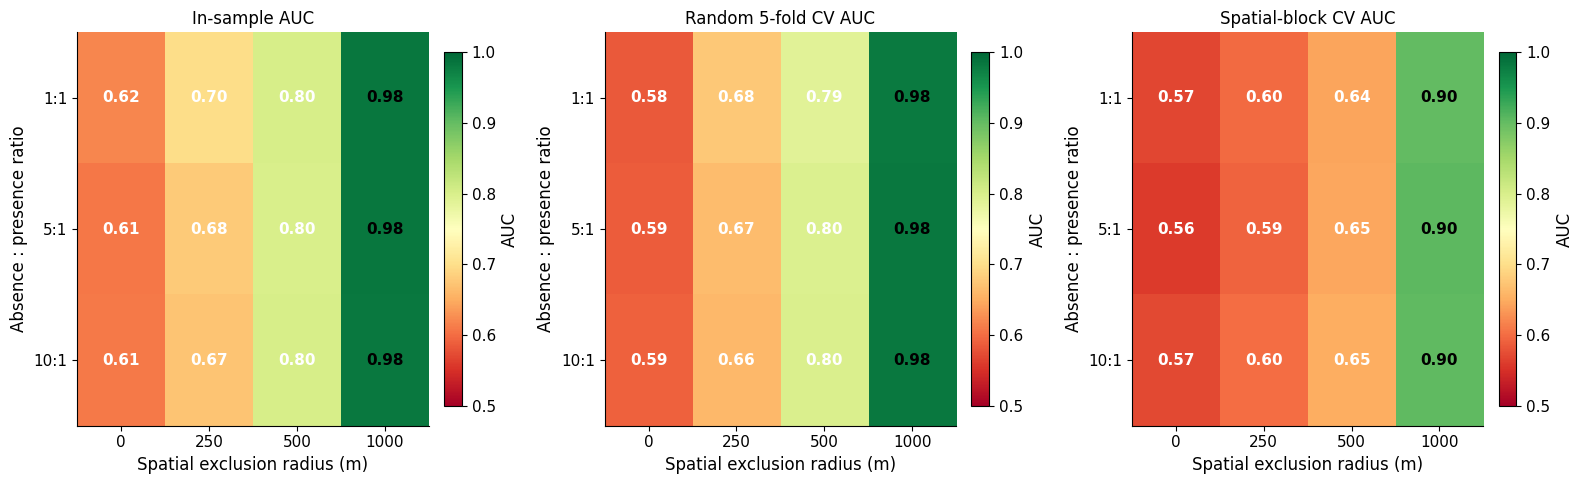

In [74]:
# Figure S1 - Pseudo-absence sensitivity heatmap (3 panels for logistic regression)
# 3 absence:presence ratios x 4 spatial exclusion radii x 3 CV schemes

ratios_S1 = [1, 5, 10]
excls_S1  = [0, 250, 500, 1000]

def _build_design_grid(excl_m, ratio_k):
    rng = np.random.default_rng(SEED)
    target = ratio_k * len(fire_df)
    tree_f = cKDTree(fire_df[['x_utm', 'y_utm']].values) if excl_m > 0 else None
    out_pts = []
    for _ in range(300):
        if len(out_pts) >= target:
            break
        nx = rng.uniform(xmin, xmax, target * 5)
        ny = rng.uniform(ymin, ymax, target * 5)
        inside = points_in_polygon(nx, ny, np.array(reserve_outer))
        cx, cy = nx[inside], ny[inside]
        lu = sample_raster(lulc, lulc_w, cx, cy)
        good = ~np.isnan(lu) & (lu != 15) & (lu != 4)
        cx, cy = cx[good], cy[good]
        if excl_m > 0:
            dnn, _ = tree_f.query(np.column_stack([cx, cy]), k=1)
            far = dnn >= excl_m
            cx, cy = cx[far], cy[far]
        out_pts.extend(zip(cx, cy))
    if len(out_pts) < target * 0.5:
        return None
    abs_p = np.array(out_pts[:target])
    xy = np.vstack([fire_df[['x_utm', 'y_utm']].values, abs_p])
    yy = np.concatenate([np.ones(len(fire_df)), np.zeros(len(abs_p))])
    d = {k: sample_raster(arr, w, xy[:, 0], xy[:, 1]) for k, (arr, w) in layers.items()}
    d['LULC'] = sample_raster(lulc, lulc_w, xy[:, 0], xy[:, 1])
    d['fire'] = yy
    d['x_utm'] = xy[:, 0]
    d['y_utm'] = xy[:, 1]
    df_ = pd.DataFrame(d).dropna(subset=cols_cont)
    df_ = df_[(df_['LULC'].notna()) & (df_['LULC'] != 15) & (df_['LULC'] != 4)]
    df_ = df_[(df_['D2Place'] > 0) & (df_['D2Road'] > 0) & (df_['D2Water'] > 0)]
    return df_

def _fit_logistic_three_cv(df_):
    if df_ is None or df_['fire'].sum() < 50:
        return (np.nan, np.nan, np.nan)
    Xg = df_[cols_cont].values.copy()
    for j, c in enumerate(cols_cont):
        if c.startswith('D2'):
            Xg[:, j] = np.log(np.clip(Xg[:, j], 1, None))
    Xz_ = (Xg - Xg.mean(axis=0)) / Xg.std(axis=0)
    yz_ = df_['fire'].values.astype(int)
    m_in = LogisticRegression(max_iter=5000, C=1e6).fit(Xz_, yz_)
    in_auc = roc_auc_score(yz_, m_in.predict_proba(Xz_)[:, 1])
    rcv = []
    for s in (42, 43, 44):
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=s)
        for tr, te in skf.split(Xz_, yz_):
            mm = LogisticRegression(max_iter=5000, C=1e6).fit(Xz_[tr], yz_[tr])
            rcv.append(roc_auc_score(yz_[te], mm.predict_proba(Xz_[te])[:, 1]))
    rand_cv = float(np.mean(rcv))
    xy_ = df_[['x_utm', 'y_utm']].values
    n_blocks = 4
    x_e = np.linspace(xy_[:, 0].min(), xy_[:, 0].max(), n_blocks + 1)
    y_e = np.linspace(xy_[:, 1].min(), xy_[:, 1].max(), n_blocks + 1)
    bx = np.clip(np.searchsorted(x_e[1:-1], xy_[:, 0]), 0, n_blocks - 1)
    by = np.clip(np.searchsorted(y_e[1:-1], xy_[:, 1]), 0, n_blocks - 1)
    block = bx * n_blocks + by
    sb = []
    for b in np.unique(block):
        te = block == b
        tr = ~te
        if yz_[te].sum() < 10 or (1 - yz_[te]).sum() < 10:
            continue
        if yz_[tr].sum() == 0:
            continue
        try:
            mm = LogisticRegression(max_iter=5000, C=1e6).fit(Xz_[tr], yz_[tr])
            sb.append(roc_auc_score(yz_[te], mm.predict_proba(Xz_[te])[:, 1]))
        except Exception:
            continue
    sb_cv = float(np.mean(sb)) if sb else np.nan
    return (in_auc, rand_cv, sb_cv)

print('Computing the 3-ratio x 4-exclusion x 3-CV grid (this takes ~2 minutes)...')
data_in    = np.full((len(ratios_S1), len(excls_S1)), np.nan)
data_rcv   = np.full((len(ratios_S1), len(excls_S1)), np.nan)
data_sblk  = np.full((len(ratios_S1), len(excls_S1)), np.nan)
for i, r in enumerate(ratios_S1):
    for j, e in enumerate(excls_S1):
        df_ = _build_design_grid(e, r)
        ia, rc, sc = _fit_logistic_three_cv(df_)
        data_in[i, j]   = ia
        data_rcv[i, j]  = rc
        data_sblk[i, j] = sc
        print(f'  ratio {r}:1, excl {e:>4} m -> in={ia:.3f}, rand={rc:.3f}, sblk={sc:.3f}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
panels = [
    ('In-sample AUC',          data_in),
    ('Random 5-fold CV AUC',   data_rcv),
    ('Spatial-block CV AUC',   data_sblk),
]
for ax_, (title, data) in zip(axes, panels):
    cmap = plt.cm.RdYlGn
    norm = mpl.colors.Normalize(vmin=0.5, vmax=1.0)
    im = ax_.imshow(data, cmap=cmap, norm=norm, aspect='auto')
    ax_.set_xticks(range(len(excls_S1)))
    ax_.set_xticklabels(excls_S1)
    ax_.set_yticks(range(len(ratios_S1)))
    ax_.set_yticklabels([f'{r}:1' for r in ratios_S1])
    ax_.set_xlabel('Spatial exclusion radius (m)')
    ax_.set_ylabel('Absence : presence ratio')
    ax_.set_title(title, fontsize=12)
    for i in range(len(ratios_S1)):
        for j in range(len(excls_S1)):
            v = data[i, j]
            txt = 'n/a' if np.isnan(v) else f'{v:.2f}'
            color = 'white' if (not np.isnan(v) and v < 0.85) else 'black'
            ax_.text(j, i, txt, ha='center', va='center',
                       fontsize=11, fontweight='bold', color=color)
    plt.colorbar(im, ax=ax_, fraction=0.046, pad=0.04, label='AUC')

fig.tight_layout()
fig.savefig(f'{OUT_DIR}/figures/figS1_pseudoabs_heatmap.png', dpi=300, bbox_inches='tight')
fig.savefig(f'{OUT_DIR}/figures/figS1_pseudoabs_heatmap.pdf', bbox_inches='tight')
plt.show()

### Figure S2. Ripley's L plot
Observed L(r) − r against a 199-simulation CSR envelope.

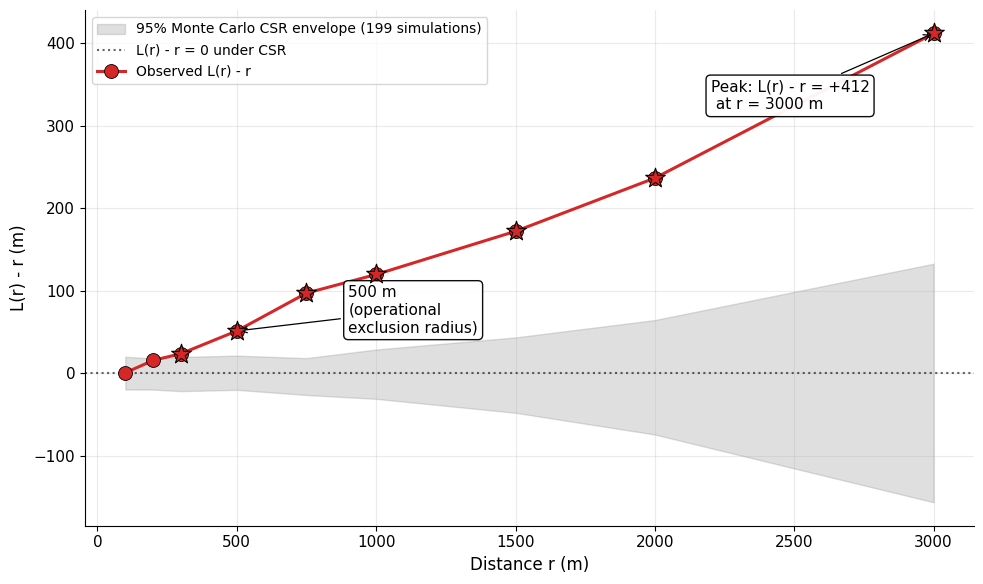

In [75]:
# Monte Carlo CSR envelope (199 simulations)
n_sim = 199
L_sims = np.zeros((n_sim, len(r_values)))
rng_r = np.random.default_rng(SEED)
for s in range(n_sim):
    sim_x = rng_r.uniform(xmin, xmax, len(xy_f) * 5)
    sim_y = rng_r.uniform(ymin, ymax, len(xy_f) * 5)
    inside = points_in_polygon(sim_x, sim_y, np.array(reserve_outer))
    sim_x, sim_y = sim_x[inside], sim_y[inside]
    if len(sim_x) < len(xy_f): continue
    sim_x, sim_y = sim_x[:len(xy_f)], sim_y[:len(xy_f)]
    sim_xy = np.column_stack([sim_x, sim_y])
    tree_s = cKDTree(sim_xy)
    bd_s = np.zeros(len(sim_xy))
    for i in range(len(sim_xy)):
        md_ = float('inf')
        for j in range(len(ring_np)):
            x1, y1 = ring_np[j]; x2, y2 = ring_np[(j+1) % len(ring_np)]
            d = pt_to_segment(sim_x[i], sim_y[i], x1, y1, x2, y2)
            if d < md_: md_ = d
        bd_s[i] = md_
    int_s = len(sim_xy) / reserve_area_m2
    for ri, r in enumerate(r_values):
        intr_m = bd_s >= r
        if intr_m.sum() < 5:
            L_sims[s, ri] = np.nan; continue
        pairs = tree_s.query_ball_point(sim_xy[intr_m], r=r)
        counts_s = np.array([len(pp) - 1 for pp in pairs])
        K_s = counts_s.mean() / int_s
        L_sims[s, ri] = np.sqrt(K_s / math.pi) - r
L_lo = np.nanpercentile(L_sims, 2.5, axis=0)
L_hi = np.nanpercentile(L_sims, 97.5, axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
ax.fill_between(r_values, L_lo, L_hi, color='grey', alpha=0.25,
                  label='95% Monte Carlo CSR envelope (199 simulations)')
ax.axhline(0, color='black', linestyle=':', alpha=0.6, label='L(r) - r = 0 under CSR')
ax.plot(r_values, L_obs_arr, 'o-', color='#d62728', linewidth=2.2, markersize=10,
         label='Observed L(r) - r', markeredgecolor='black', markeredgewidth=0.6)
sig = L_obs_arr > L_hi
ax.scatter(r_values[sig], L_obs_arr[sig], marker='*', s=220,
            color='#d62728', edgecolor='black', linewidth=0.8, zorder=5)
idx_500 = int(np.argmin(np.abs(r_values - 500)))
ax.annotate('500 m\n(operational\nexclusion radius)',
             xy=(500, L_obs_arr[idx_500]), xytext=(900, 50),
             fontsize=11,
             arrowprops=dict(arrowstyle='->', color='black', lw=0.9),
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.95))
idx_peak = int(np.nanargmax(L_obs_arr))
ax.annotate(f'Peak: L(r) - r = +{L_obs_arr[idx_peak]:.0f}\n at r = {r_values[idx_peak]} m',
             xy=(r_values[idx_peak], L_obs_arr[idx_peak]),
             xytext=(2200, 320), fontsize=11,
             arrowprops=dict(arrowstyle='->', color='black', lw=0.9),
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.95))
ax.set_xlabel('Distance r (m)')
ax.set_ylabel('L(r) - r (m)')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(f'{OUT_DIR}/figures/figS2_ripley.png', dpi=300, bbox_inches='tight')
fig.savefig(f'{OUT_DIR}/figures/figS2_ripley.pdf', bbox_inches='tight')
plt.show()

### Figure S3. Predictor correlation matrix
Pearson correlations among the 12 continuous predictors.

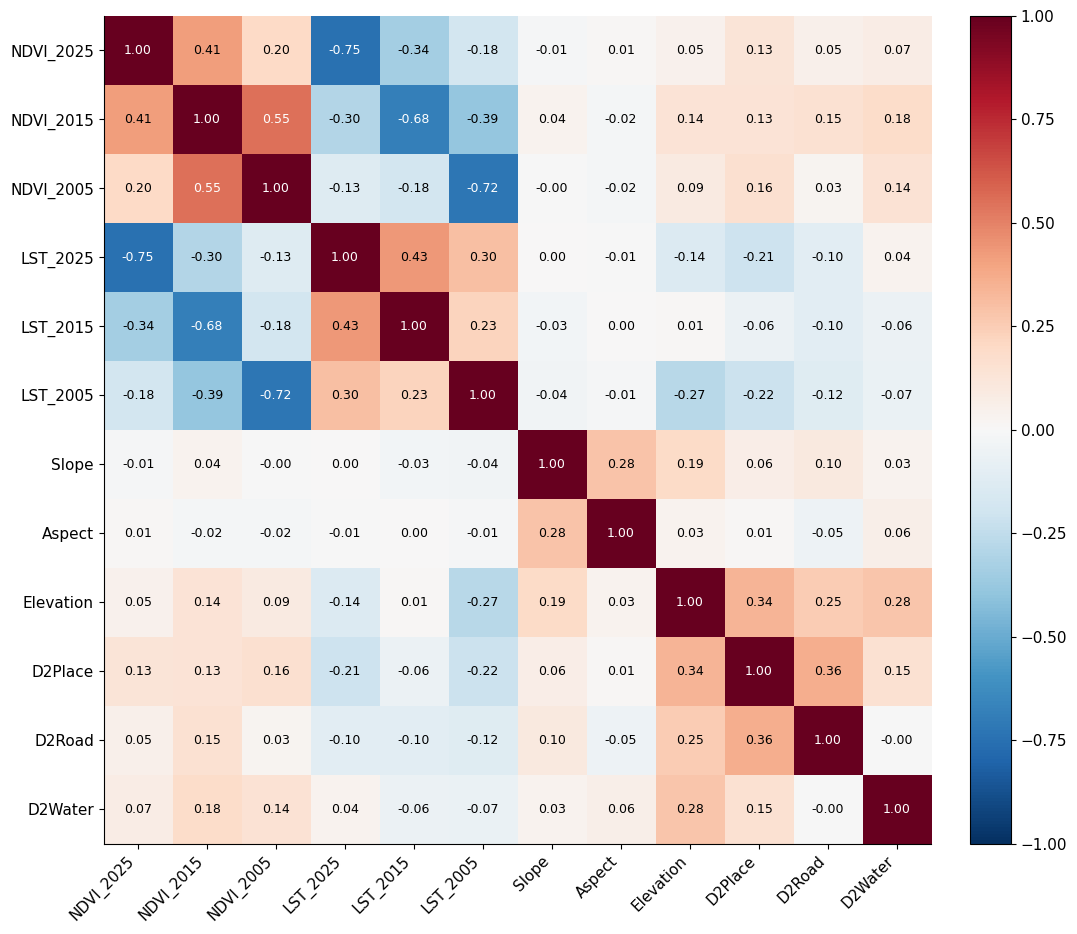

In [76]:
corr = pd.DataFrame(X_z, columns=cols_cont).corr().values
fig, ax = plt.subplots(figsize=(11, 9.5))
cmap = plt.cm.RdBu_r
im = ax.imshow(corr, cmap=cmap, vmin=-1, vmax=1)
ax.set_xticks(range(len(cols_cont))); ax.set_xticklabels(cols_cont, rotation=45, ha='right')
ax.set_yticks(range(len(cols_cont))); ax.set_yticklabels(cols_cont)
for i in range(len(cols_cont)):
    for j in range(len(cols_cont)):
        v = corr[i, j]
        color = 'white' if abs(v) > 0.5 else 'black'
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9, color=color)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(f'{OUT_DIR}/figures/figS3_corr_matrix.png', dpi=300, bbox_inches='tight')
fig.savefig(f'{OUT_DIR}/figures/figS3_corr_matrix.pdf', bbox_inches='tight')
plt.show()

### Figure S4. Stratified forest plot
Edge vs interior odds ratios with 95% CIs.

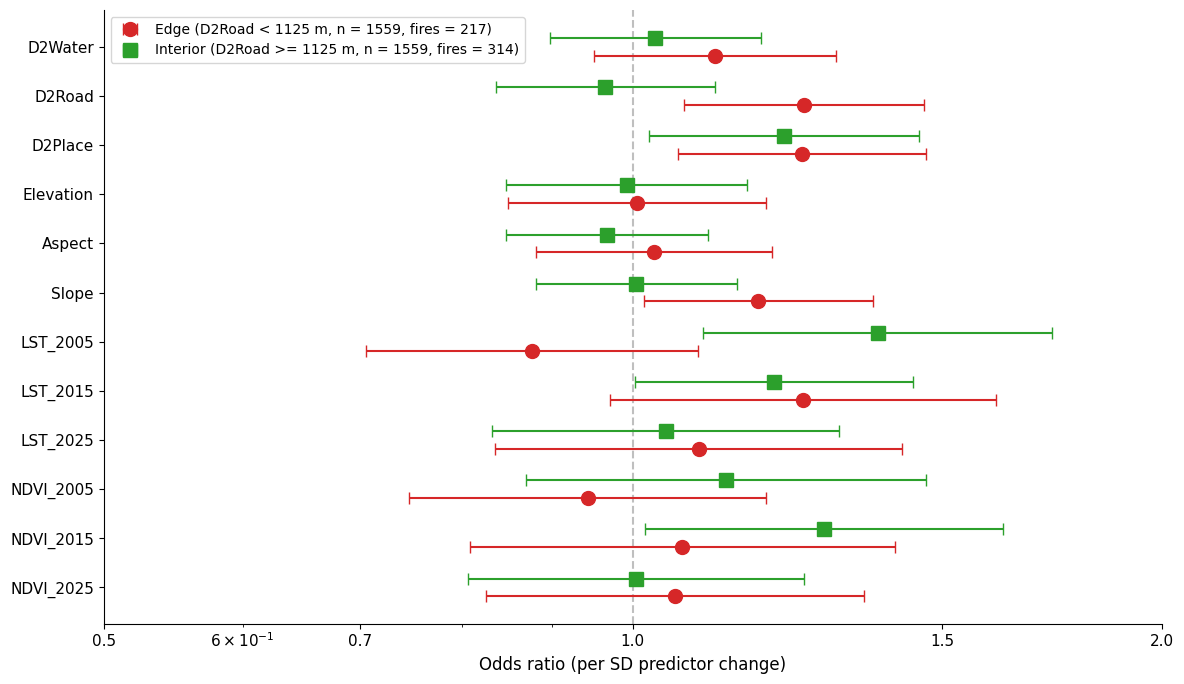

In [77]:
fig, ax = plt.subplots(figsize=(12, 7))
y_pos = np.arange(len(cols_cont))
e_or = [np.exp(me.coef_[0][j]) for j in range(len(cols_cont))]
e_lo = [np.exp(me.coef_[0][j] - 1.96 * see[j + 1]) for j in range(len(cols_cont))]
e_hi = [np.exp(me.coef_[0][j] + 1.96 * see[j + 1]) for j in range(len(cols_cont))]
i_or = [np.exp(mi.coef_[0][j]) for j in range(len(cols_cont))]
i_lo = [np.exp(mi.coef_[0][j] - 1.96 * sei[j + 1]) for j in range(len(cols_cont))]
i_hi = [np.exp(mi.coef_[0][j] + 1.96 * sei[j + 1]) for j in range(len(cols_cont))]
ax.axvline(1.0, color='grey', linestyle='--', alpha=0.5)
ax.errorbar(e_or, y_pos - 0.18,
             xerr=[np.array(e_or) - np.array(e_lo), np.array(e_hi) - np.array(e_or)],
             fmt='o', color='#d62728', markersize=10, capsize=4,
             label=f'Edge (D2Road < {median_d2road:.0f} m, n = {len(edge)}, fires = {int(edge.fire.sum())})')
ax.errorbar(i_or, y_pos + 0.18,
             xerr=[np.array(i_or) - np.array(i_lo), np.array(i_hi) - np.array(i_or)],
             fmt='s', color='#2ca02c', markersize=10, capsize=4,
             label=f'Interior (D2Road >= {median_d2road:.0f} m, n = {len(intr)}, fires = {int(intr.fire.sum())})')
ax.set_yticks(y_pos); ax.set_yticklabels(cols_cont)
ax.set_xlabel('Odds ratio (per SD predictor change)')
ax.set_xscale('log')
ax.set_xticks([0.5, 0.7, 1.0, 1.5, 2.0])
ax.set_xticklabels(['0.5', '0.7', '1.0', '1.5', '2.0'])
ax.legend(loc='upper left', fontsize=10)
fig.tight_layout()
fig.savefig(f'{OUT_DIR}/figures/figS4_stratified.png', dpi=300, bbox_inches='tight')
fig.savefig(f'{OUT_DIR}/figures/figS4_stratified.pdf', bbox_inches='tight')
plt.show()

### Figure S5. High-confidence detection subset
AHP class allocation and lift for confidence ≥ 80 detections.

Figure S5 high-confidence lift (Low/Mod/High): 1.818 / 1.215 / 0.130


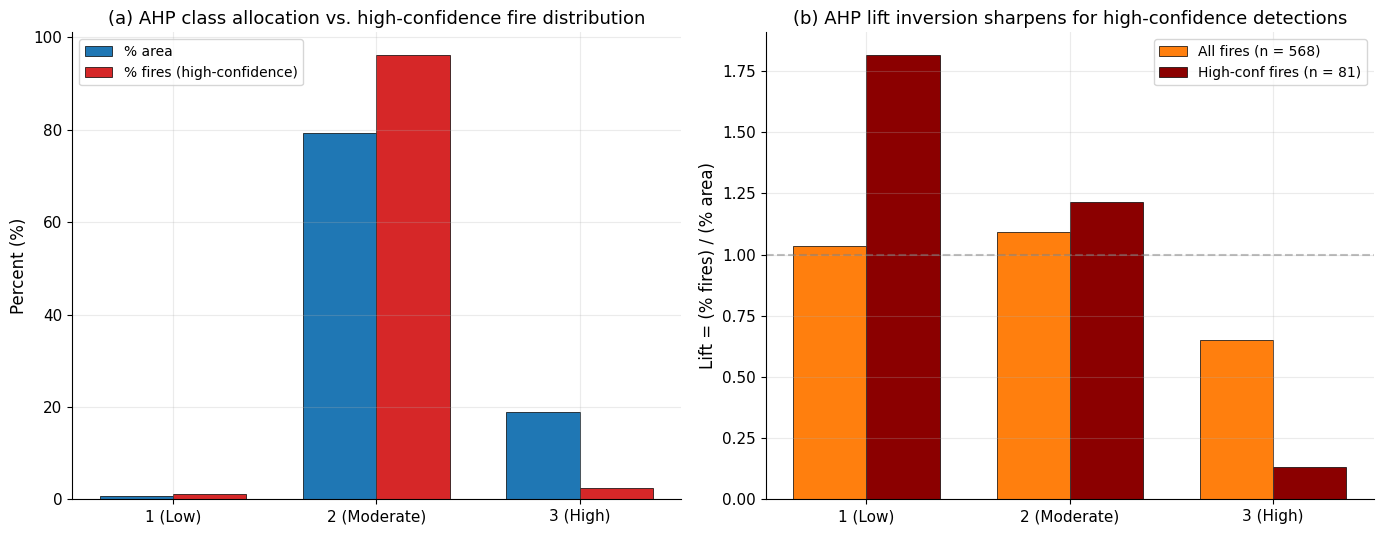

In [78]:
hc = fire_df[fire_df['CONFIDENCE'] >= 80]
n_hc = len(hc)
ahp_at_hc = sample_raster(ahp, ahp_w, hc['x_utm'].values, hc['y_utm'].values)
pct_fires_hc = {c: 100 * (ahp_at_hc == c).sum() / n_hc for c in (1, 2, 3)}
lifts_hc = {c: pct_fires_hc[c] / area_pct[c] if area_pct[c] > 0 else np.nan for c in (1, 2, 3)}
print(f'Figure S5 high-confidence lift (Low/Mod/High): {lifts_hc[1]:.3f} / {lifts_hc[2]:.3f} / {lifts_hc[3]:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
classes_l = ['1 (Low)', '2 (Moderate)', '3 (High)']
x = np.arange(3); w_bar = 0.36
pa = [area_pct[c] for c in (1, 2, 3)]
pf_hc = [pct_fires_hc[c] for c in (1, 2, 3)]
ax.bar(x - w_bar/2, pa, w_bar, label='% area', color='#1f77b4',
        edgecolor='black', linewidth=0.5)
ax.bar(x + w_bar/2, pf_hc, w_bar, label='% fires (high-confidence)',
        color='#d62728', edgecolor='black', linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels(classes_l)
ax.set_ylabel('Percent (%)')
ax.set_title('(a) AHP class allocation vs. high-confidence fire distribution')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.25)

ax = axes[1]
all_lifts = [lifts[c] for c in (1, 2, 3)]
hc_lifts = [lifts_hc[c] for c in (1, 2, 3)]
ax.axhline(1.0, color='grey', linestyle='--', alpha=0.5)
ax.bar(x - w_bar/2, all_lifts, w_bar, label=f'All fires (n = {len(fire_df)})',
        color='#ff7f0e', edgecolor='black', linewidth=0.5)
ax.bar(x + w_bar/2, hc_lifts, w_bar, label=f'High-conf fires (n = {n_hc})',
        color='#8b0000', edgecolor='black', linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels(classes_l)
ax.set_ylabel('Lift = (% fires) / (% area)')
ax.set_title('(b) AHP lift inversion sharpens for high-confidence detections')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(f'{OUT_DIR}/figures/figS5_highconf.png', dpi=300, bbox_inches='tight')
fig.savefig(f'{OUT_DIR}/figures/figS5_highconf.pdf', bbox_inches='tight')
plt.show()

### Figure S6. AHP weight-scheme sensitivity
Per-class lift for the four weighting schemes, read from Table S5.

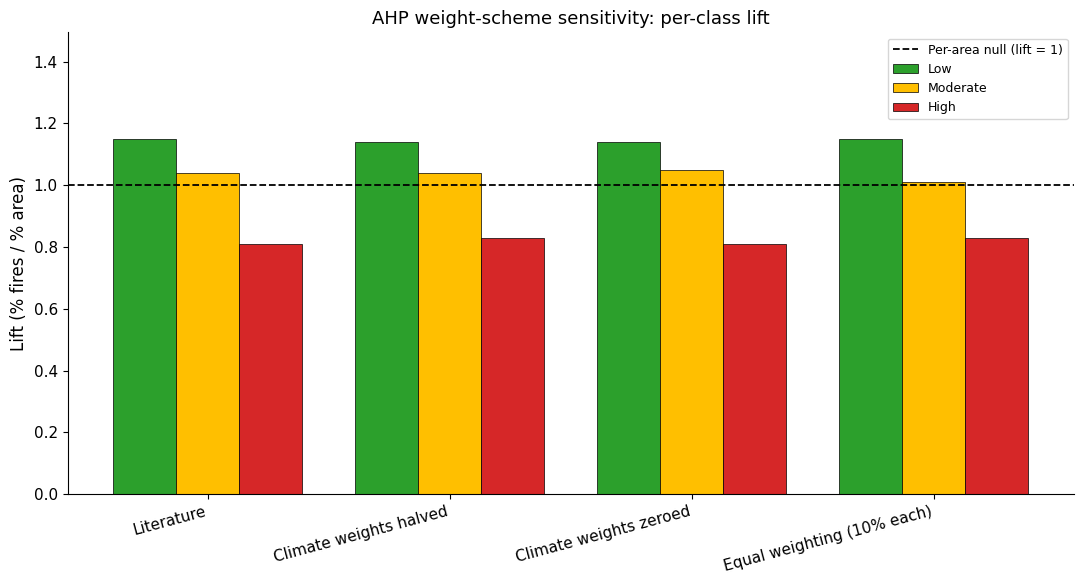

In [79]:
# Figure S6: per-class lift across weighting schemes, from Table S5.
labels_s6 = tableS5['Scheme'].tolist()
low  = tableS5['Low lift'].astype(float).values
mod  = tableS5['Moderate lift'].astype(float).values
high = tableS5['High lift'].astype(float).values

x = np.arange(len(labels_s6)); wbar = 0.26
fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - wbar, low,  wbar, label='Low',      color='#2ca02c', edgecolor='black', linewidth=0.5)
ax.bar(x,        mod,  wbar, label='Moderate', color='#ffbf00', edgecolor='black', linewidth=0.5)
ax.bar(x + wbar, high, wbar, label='High',     color='#d62728', edgecolor='black', linewidth=0.5)
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.3, label='Per-area null (lift = 1)')
ax.set_xticks(x); ax.set_xticklabels(labels_s6, rotation=15, ha='right')
ax.set_ylabel('Lift (% fires / % area)')
ax.set_title('AHP weight-scheme sensitivity: per-class lift')
max_val = max(low.max(), mod.max(), high.max())
ax.set_ylim(0, max_val * 1.3)

ax.legend(fontsize=9, loc='upper right')
fig.tight_layout()
fig.savefig(f'{OUT_DIR}/figures/figS6_weight_sens.png', dpi=300, bbox_inches='tight')
fig.savefig(f'{OUT_DIR}/figures/figS6_weight_sens.pdf', bbox_inches='tight')
plt.show()

### Figure S7. Ordinal empirical-weight AHP comparator
Empirical vs literature weights and the resulting lift.

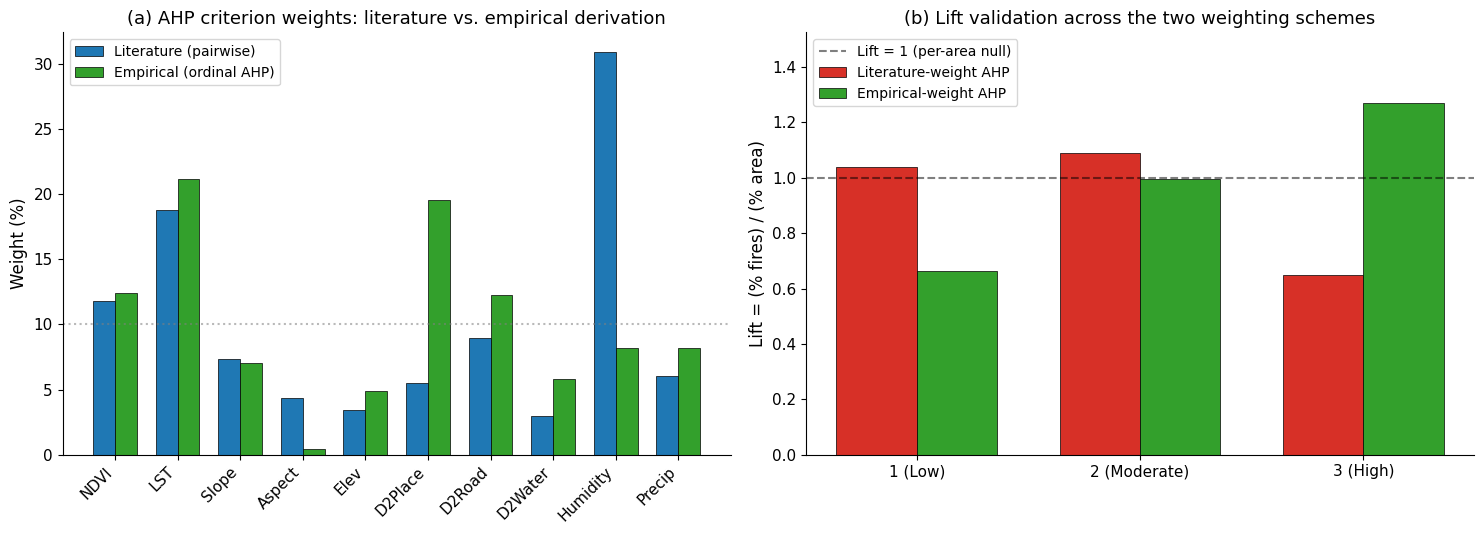

Empirical AHP lift (Low/Mod/High): 0.664 / 0.995 / 1.271


In [80]:
# (a) weights; (b) lift
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
criteria = ['NDVI', 'LST', 'Slope', 'Aspect', 'Elev',
            'D2Place', 'D2Road', 'D2Water', 'Humidity', 'Precip']
lit_pct = [11.83, 18.74, 7.33, 4.34, 3.42, 5.50, 8.99, 2.95, 30.86, 6.04]
emp_pct_arr = [emp_pct[crits10.index(k)] for k in
               ['NDVI_2025','LST_2025','Slope','Aspect','Elevation',
                'D2Place','D2Road','D2Water','Humidity_2015','Precipitation_2015']]
x = np.arange(len(criteria)); w_bar = 0.35
ax = axes[0]
ax.bar(x - w_bar/2, lit_pct, w_bar, label='Literature (pairwise)',
        color='#1f78b4', edgecolor='black', linewidth=0.5)
ax.bar(x + w_bar/2, emp_pct_arr, w_bar, label='Empirical (ordinal AHP)',
        color='#33a02c', edgecolor='black', linewidth=0.5)
ax.axhline(10.0, color='grey', linestyle=':', alpha=0.55)
ax.set_xticks(x); ax.set_xticklabels(criteria, rotation=45, ha='right')
ax.set_ylabel('Weight (%)')
ax.set_title('(a) AHP criterion weights: literature vs. empirical derivation')
ax.legend(loc='upper left', fontsize=10)

# Compute lift for empirical scheme
emp_score_min, emp_score_max = score_emp.min(), score_emp.max()
breaks_e = [emp_score_min + (emp_score_max - emp_score_min) / 3,
            emp_score_min + 2 * (emp_score_max - emp_score_min) / 3]
risk_emp = np.where(score_emp <= breaks_e[0], 1,
                       np.where(score_emp <= breaks_e[1], 2, 3))
lift_emp = {}
y_emp = df_d_full['fire'].values.astype(int)
for c in (1, 2, 3):
    pa = 100 * (risk_emp == c).mean()
    pf = 100 * ((risk_emp == c) & (y_emp == 1)).sum() / max(1, y_emp.sum())
    lift_emp[c] = pf / pa if pa > 0 else np.nan

ax = axes[1]
class_lbls = ['1 (Low)', '2 (Moderate)', '3 (High)']
xc = np.arange(3); wc = 0.36
lit_lift = [1.04, 1.09, 0.65]
emp_lift_arr = [lift_emp[c] for c in (1, 2, 3)]
ax.axhline(1.0, color='black', linestyle='--', alpha=0.5, label='Lift = 1 (per-area null)')
ax.bar(xc - wc/2, lit_lift, wc, label='Literature-weight AHP',
        color='#d73027', edgecolor='black', linewidth=0.5)
ax.bar(xc + wc/2, emp_lift_arr, wc, label='Empirical-weight AHP',
        color='#33a02c', edgecolor='black', linewidth=0.5)
ax.set_xticks(xc); ax.set_xticklabels(class_lbls)
ax.set_ylabel('Lift = (% fires) / (% area)')
ax.set_title('(b) Lift validation across the two weighting schemes')
ax.legend(loc='upper left', fontsize=10)
ax.set_ylim(0, max(max(lit_lift), max(emp_lift_arr)) * 1.20)

fig.tight_layout()
fig.savefig(f'{OUT_DIR}/figures/figS7_ordinal_ahp.png', dpi=300, bbox_inches='tight')
fig.savefig(f'{OUT_DIR}/figures/figS7_ordinal_ahp.pdf', bbox_inches='tight')
plt.show()
print(f'Empirical AHP lift (Low/Mod/High): {emp_lift_arr[0]:.3f} / '
      f'{emp_lift_arr[1]:.3f} / {emp_lift_arr[2]:.3f}')

## Part G. Output index

Lists all tables and figures written to `OUT_DIR`.

In [81]:
print('=' * 60)
print(f'OUTPUTS in {OUT_DIR}')
print('=' * 60)

print('\nTABLES:')
for f in sorted(os.listdir(f'{OUT_DIR}/tables')):
    size = os.path.getsize(f'{OUT_DIR}/tables/{f}')
    print(f'  {f:42s} {size:>8,} bytes')

print('\nFIGURES:')
for f in sorted(os.listdir(f'{OUT_DIR}/figures')):
    size = os.path.getsize(f'{OUT_DIR}/figures/{f}')
    print(f'  {f:42s} {size:>8,} bytes')

# Write the headline scalars used in the text to a single CSV.
def _g(name):
    v = globals().get(name, None)
    return '' if v is None else v
_scalar_specs = [
    ('analytical_n', 'n_total'), ('analytical_fires', 'n_fires_clean'),
    ('baseline_insample_auc', 'auc_in_sample'),
    ('morans_I', 'moran_I'), ('morans_p', 'moran_p'),
    ('clark_evans_R', 'ce_R'), ('clark_evans_z', 'ce_z'), ('clark_evans_p', 'ce_p'),
    ('ripley_peak_L', None), ('ripley_peak_r', None),
    ('max_vif', None), ('strat_median_d2road', None),
    ('empirical_ahp_cv_auc', 'emp_cv_mean'), ('empirical_ahp_cv_sd', 'emp_cv_sd'),
    ('reserve_area_ha', 'reserve_area_ha'), ('n_questionnaire', None),
]
_rows = []
for label, var in _scalar_specs:
    if var is not None:
        _rows.append([label, _g(var)])
try: _rows.append(['ripley_peak_L', round(float(L_obs_arr[int(np.nanargmax(L_obs_arr))]), 2)])
except Exception: pass
try: _rows.append(['ripley_peak_r', int(r_values[int(np.nanargmax(L_obs_arr))])])
except Exception: pass
try: _rows.append(['max_vif', round(float(tableS3['VIF'].max()), 2)])
except Exception: pass
try: _rows.append(['strat_median_d2road', round(float(median_d2road), 1)])
except Exception: pass
try: _rows.append(['n_questionnaire', int(len(q))])
except Exception: pass
_rows = [r for r in _rows if r[1] != '']
pd.DataFrame(_rows, columns=['scalar', 'value']).to_csv(
    f'{OUT_DIR}/tables/key_scalars.csv', index=False)
print('\nkey_scalars.csv written with', len(_rows), 'values.')

print('\nrun_log.txt + all table CSVs saved under', OUT_DIR)
sys.stdout.flush()

OUTPUTS in /content/drive/MyDrive/Gambari/Gambari_new_update_outputs

TABLES:
  climate_diagnostic.csv                          197 bytes
  questionnaire_columns.csv                     5,521 bytes
  table1_descriptives.csv                         499 bytes
  table2_ahp_weights.csv                          288 bytes
  table3_model_auc.csv                            322 bytes
  tableS10_logistic.csv                           872 bytes
  tableS1_pseudoabs_sensitivity.csv               376 bytes
  tableS2_ripley.csv                              125 bytes
  tableS3_vif.csv                                 177 bytes
  tableS4_stratified.csv                          905 bytes
  tableS5_weight_sensitivity.csv                  312 bytes
  tableS6_empirical_ahp.csv                       360 bytes
  tableS7_ahp_weights_detail.csv                  288 bytes
  tableS8_demographics.csv                        566 bytes
  tableS9_quasipoisson.csv                        502 bytes

FIGURES:
  fig1_exper